In [1]:
import pandas as pd
df = pd.read_csv('../data/tima_cleaned_data_v1.csv')
df

,STT,application_date,TS_CREDIT_SCORE_V2,Số điện thoại khách hàng,FromDate,ID,LoanID,Số tiền đăng ký vay ban đầu,Tiền giải ngân,Tiền gốc còn lại,...,AgeGroup,LoanTermMonths,ProcessingDays,LoanToIncomeRatio,Cần Giải Ngân,Đã trả/khoản vay đã giải ngân,LowCreditScore,CreditScoreGroup,IncomeBracket,LoanStatus
0,2,NaN,403,977966899,2016-06-24,40,16104,10000000.0,10000000.0,10000000.0,...,Unknown,1,NaN,1.30,0.0,1.00,1,Low (High Risk),5-10m,Đang vay
1,3,2016-07-28,403,977966899,2016-07-28,226,20871,10000000.0,10000000.0,0.0,...,26-35,8,0.0,1.30,0.0,0.00,1,Low (High Risk),5-10m,Hoàn thành
2,4,2016-06-29,531,397511119,2016-06-29,45,17049,5000000.0,5000000.0,5000000.0,...,Unknown,6,0.0,0.19,0.0,1.00,1,Low (High Risk),>=25m,Hoàn thành
3,5,2016-06-29,588,abc1234567,2016-06-29,48,17067,10000000.0,10000000.0,10000000.0,...,26-35,4,0.0,1.25,0.0,1.00,1,Low (High Risk),5-10m,Hoàn thành
4,6,2016-08-05,675,966710180,2016-08-05,293,22390,10000000.0,10000000.0,0.0,...,26-35,4,0.0,0.83,0.0,0.00,0,Medium,10-15m,Hoàn thành
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2378,3181,2018-12-24,577,353833091,2018-12-24,327685,56967,5000000.0,5000000.0,1814424.0,...,18-25,3,0.0,0.67,0.0,0.36,1,Low (High Risk),5-10m,Đang vay
2379,3182,2018-12-22,638,967295514,2018-12-22,329444,56835,3000000.0,3000000.0,3000000.0,...,Unknown,2,0.0,0.38,0.0,1.00,0,Medium,5-10m,Hoàn thành
2380,3184,2018-12-27,605,385669091,2018-12-27,333862,57212,6000000.0,6000000.0,6000000.0,...,26-35,3,0.0,0.75,0.0,1.00,0,Medium,5-10m,Hoàn thành
2381,3187,2019-01-10,597,869625266,2019-01-10,348341,57938,7000000.0,6000000.0,6000000.0,...,26-35,3,0.0,0.58,1000000.0,1.00,1,Low (High Risk),10-15m,Hoàn thành


#**MONO-VARIABLE ANALYSIS**

#**GROUP 1 — Loan Core Fields**

##**Tiền giải ngân (Loan amounts)**

1. What are the mean and median loan amounts?

2. What does the distribution of loan amounts look like? (Are there many small loans?)

3. Are there any outliers? If so, how severe are they?

4. What are the majority of loan amounts taken out by customers?

In [2]:
# What are the mean and median loan amounts?
df['Tiền giải ngân'].describe().to_frame().style.format("{:,.0f}")

,Tiền giải ngân
count,"2,383"
mean,"11,739,059"
std,"46,961,329"
min,"1,000,000"
25%,"5,000,000"
50%,"8,000,000"
75%,"10,000,000"
max,"1,599,735,000"


**Insight 1 — Median Lower Than Mean -> Strong Right-Slanted Distribution**

The mean is 11.7 million, but the median is only 8 million.

This suggests that some very large loans have driven the mean up significantly.

Most customers borrow around 5–10 million, but there are a few unusual loans up to 1.6 billion.

--> In short: the median accurately reflects the highest loan amounts, not the mean.

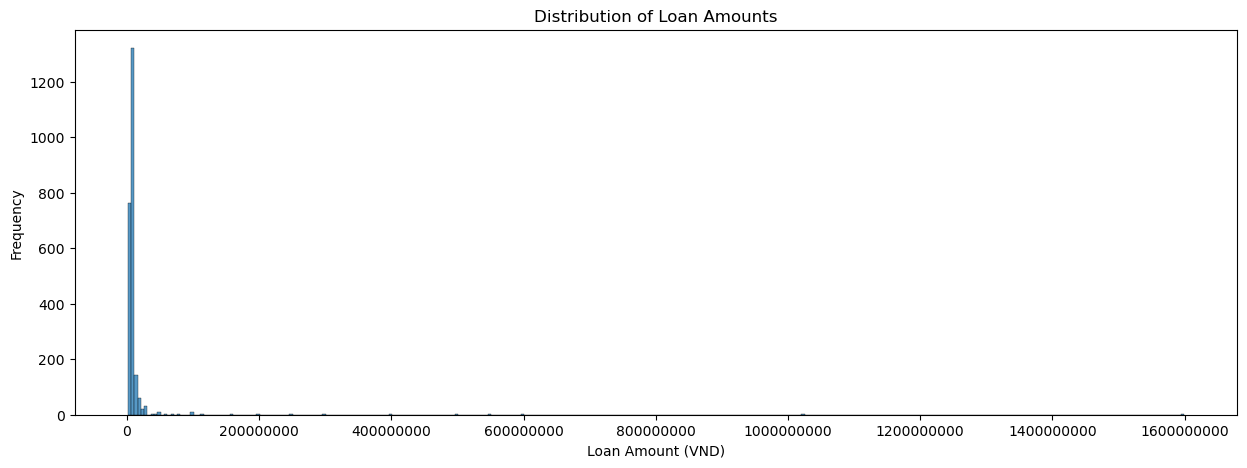

In [3]:
#What does the distribution of the loan amounts look like? (Are there many small loans?)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,5))
sns.histplot(df['Tiền giải ngân'], binwidth=5000000) #Divide into columns of value ranges, each column representing 5 million.
plt.title("Distribution of Loan Amounts")
plt.xlabel("Loan Amount (VND)")
plt.ylabel("Frequency")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

**Insight 2 — The majority of loans are concentrated under 20 million**

Almost all columns are clustered in the 1–20 million range.

This is a sign of a small consumer loan market:

→ quick loans, shopping loans, personal consumer loans.

**Insight 3 — Extremely right-skewed distribution**

On the right side, loans from 200 million to 1.6 billion appear.

Although the number is very small, they form a long tail -> a true long-tail distribution pattern.

--> This is characteristic of credit data: the majority have small loans, with a few very large borrowers.

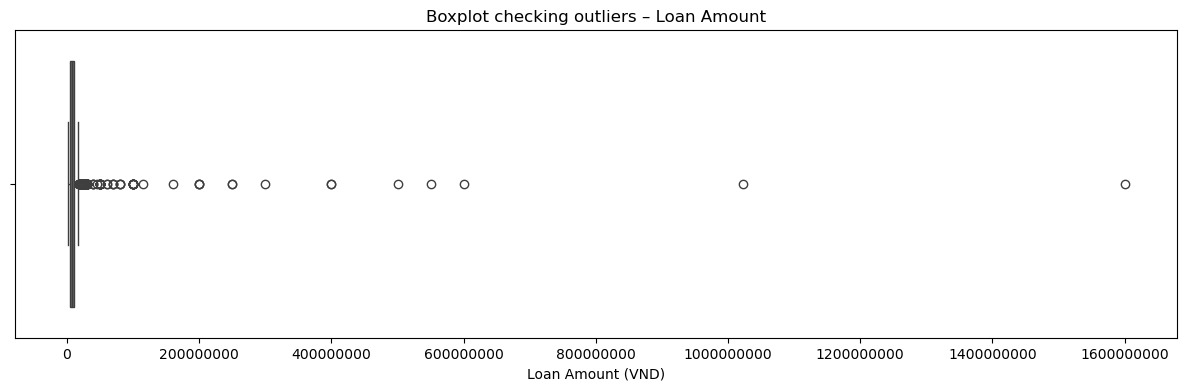

In [4]:
#Check outlier
plt.figure(figsize=(15,4))
sns.boxplot(x=df['Tiền giải ngân'])
plt.title("Boxplot checking outliers – Loan Amount")
plt.xlabel("Loan Amount (VND)")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

**Insight 4 — There are many outliers, and most are extremely large.**

Outliers range from 30–50 million or more.

Discrete dots extend to 200–500 million, and some points reach 1.6 billion.

**Insight 5 — The distribution of disbursed funds shows extremely high variability.**

Std = 47 million, four times the mean --> very high dispersion.

This indicates that the loan amounts vary greatly among different customers.

**Insight 6 — Extremely large outliers need to be considered separately.**

--> Large outliers strongly impact the ML model and must be addressed (winsorize, log-transform).

In [5]:
#Most common loan amounts
df['Tiền giải ngân'].mode()

0    10000000.0
Name: Tiền giải ngân, dtype: float64

**Insight: 7-10 million VND is the most common loan amount.**

This is the loan amount most frequently chosen by customers in the dataset.

Along with a median of 8 million VND, this confirms that TIMA customers largely belong to the small consumer loan segment (<15 million VND).

**Overall Insight**

TIMA's actual customer disbursement amounts are heavily concentrated in small loans, typically in the 5–10 million VND range, with a median of 8 million VND and the most common loan amount being 10 million VND. The distribution is strongly skewed to the right: the majority of borrowers take out low-value loans, but there are some extremely large loans (up to 1.6 billion VND), causing the average value to be inflated and not accurately reflect typical borrowing behavior. The histogram and boxplot show a significant number of large outliers, mainly in the very high-value loan group, indicating a clear stratification of the customer base between small consumer loans and a few large-value loans. For most customers, loan disbursements are relatively stable and consistent, consistent with TIMA's unsecured consumer loan model; however, large loans require separate consideration in risk management and modeling.

##**Initial Loan Application Amount**

1. How much do customers typically request to borrow?

2. What are the average, median, minimum, and maximum amounts?

3. What does the distribution of requested loan amounts look like?

4. How does this differ from the disbursed amount (the total amount disbursed)?

5. Are there any outliers – are they large or small?

In [6]:
#How much do customers typically request to borrow?
df['Số tiền đăng ký vay ban đầu'].mode()

0    10000000.0
Name: Số tiền đăng ký vay ban đầu, dtype: float64

In [7]:
df['Số tiền đăng ký vay ban đầu'].value_counts().head(5).to_frame()

,count
Số tiền đăng ký vay ban đầu,
10000000.0,1130
3000000.0,193
5000000.0,189
2500000.0,142
8000000.0,103


**Insight 1 — The most common loan amount requested by customers is 10 million VND**

This is the data mode.

It also has a significantly higher absolute number of applications (1,130).

This confirms that the majority of TIMA customers belong to the small-ticket loan segment.

**Insight 2 — Strong concentration in the 3–10 million VND group**

→ Borrowing habits are very clear: small loans – for short-term consumption.

In [8]:
#What are the mean, median, minimum, and maximum values?
df['Số tiền đăng ký vay ban đầu'].describe().to_frame().style.format("{:,.0f}")

,Số tiền đăng ký vay ban đầu
count,"2,383"
mean,"12,814,071"
std,"46,768,176"
min,"100,000"
25%,"6,000,000"
50%,"10,000,000"
75%,"10,000,000"
max,"1,553,290,000"


**Insight 3 — Median = 10 million, mean higher (nearly 12.8 million)**

Mean > Median → right-skewed distribution.

Several very large loans are pushing the average up.

**Insight 4 — 50% of customers request loans from 6–10 million**

--> Extremely concentrated in the small range.

**Insight 5 — There are extremely large loan requests up to 1.55 billion**

--> These are definitely not normal consumer loans.

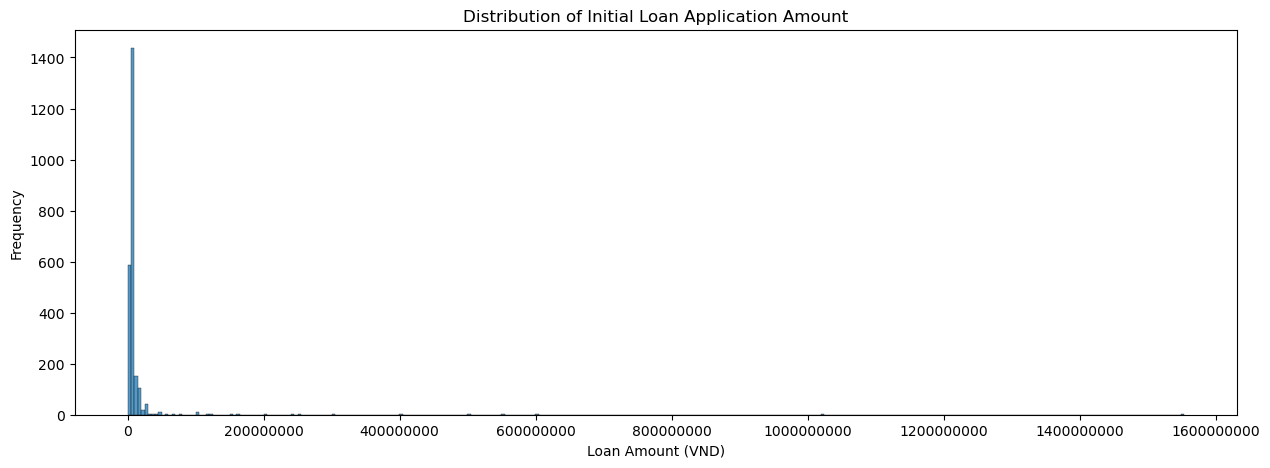

In [9]:
#Distribution of initial loan application amount
plt.figure(figsize=(15,5))
sns.histplot(df['Số tiền đăng ký vay ban đầu'], binwidth=5000000)
plt.title("Distribution of Initial Loan Application Amount")
plt.xlabel("Loan Amount (VND)")
plt.ylabel("Frequency")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

**Insight 6 — Extremely Right-Slanted Distribution**

Most borrowers have loans ranging from 1 to 20 million.

The histogram columns are all concentrated on the left.

The tail extends very far to the right — from 200 million to 1.5 billion.

**Insight 7 — Small Loans Dominate**

The chart shows:

Loans < 10 million make up the majority of the sample.

--> A key characteristic of the TIMA dataset and loan products.

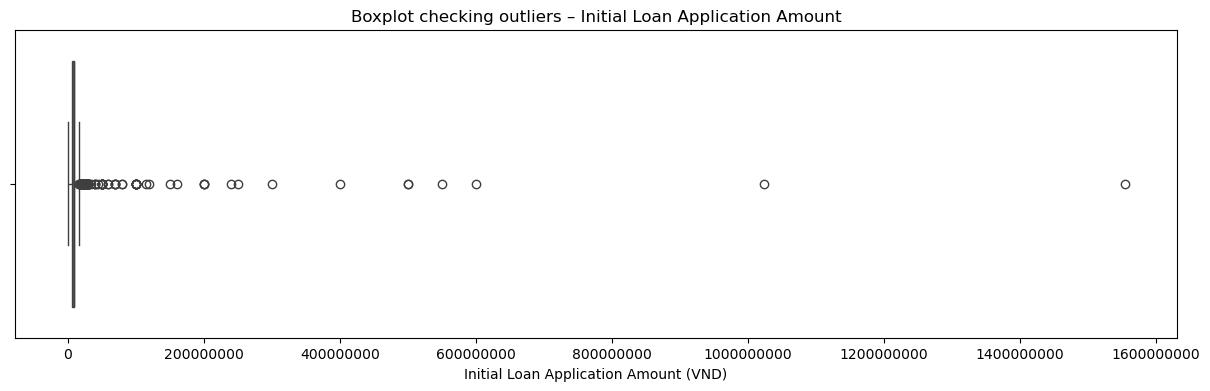

In [10]:
# Check outlier
plt.figure(figsize=(15,4))
sns.boxplot(x=df['Số tiền đăng ký vay ban đầu'])
plt.title("Boxplot checking outliers – Initial Loan Application Amount")
plt.xlabel("Initial Loan Application Amount (VND)")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

**Insight 11 — There are many outliers, mostly large ones.**

Outliers range from 30 million to 100–200 million.

A few unique outliers reached 1.55 billion.

**Insight 12 — The level of outliers is very serious and cannot be ignored.**

The standard deviation (46 million) is nearly four times larger than the median (10 million).

This makes the mean less representative → the median must be used.

**Insight 13 — The distribution of initial loan applications has longer tails than disbursements.**

--> This shows that many customers requested high loan amounts, but not everyone received full approval.

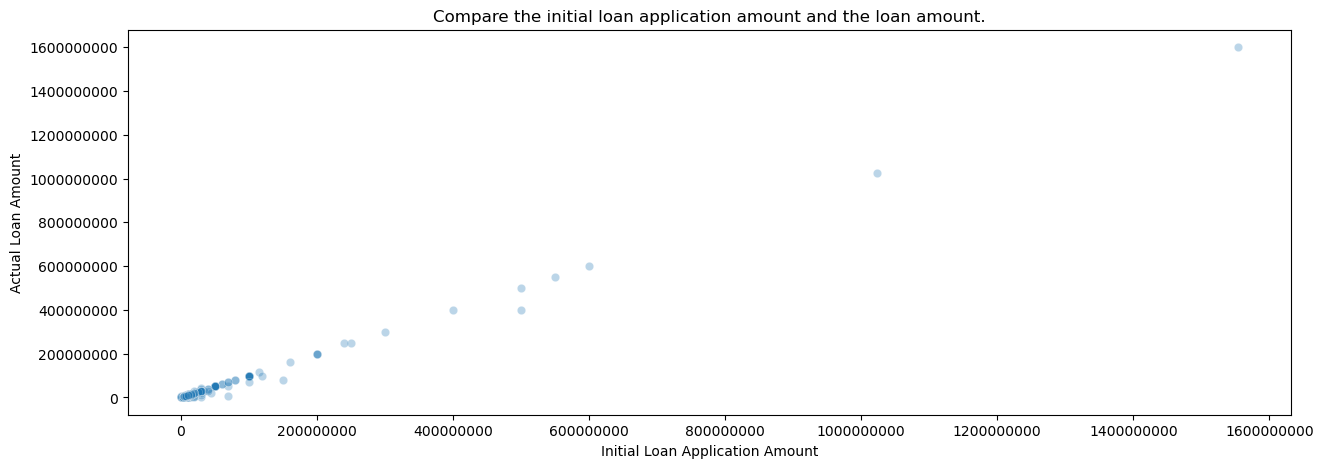

In [11]:
# Is there any difference compared to the loan amount?
plt.figure(figsize=(15,5))
sns.scatterplot(
    x=df['Số tiền đăng ký vay ban đầu'],
    y=df['Tiền giải ngân'],
    alpha = 0.3
)
plt.title("Compare the initial loan application amount and the loan amount.")
plt.xlabel("Initial Loan Application Amount")
plt.ylabel("Actual Loan Amount")
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')
plt.show()


**Insight 8 — Two variables have a fairly clear (positive) linear correlation.**

When customers apply for many loans, the disbursed amount is usually also high.

However, the disbursed amount doesn't always equal the applied amount.

**Insight 9 — For large loans (100 million+), there is a significant gap.**

--> This could be:

A loan application of 1 billion VND might only be approved for 300-500 million VND.

A policy of tightening credit limits for high-risk customers.

Or the loan product might not lend the full requested amount.

**Insight 10 — For small loans (2-20 million VND), the applied amount equals the loan amount.**

→ Small loan applicants are usually approved for almost the entire amount.

**Overall Insight**

TIMA customers' initial loan applications are almost entirely concentrated in the small loan group, primarily in the 6-10 million VND range, with 10 million VND being the most common. The data distribution is strongly skewed to the right: the majority of customers request low loan amounts, but there are some applications requesting very large loans (up to over 1.5 billion VND), significantly increasing the average despite the median being only 10 million VND. Histograms and boxplots show a large outlier in the large loan group, reflecting a significant difference in loan demand among customers. Furthermore, a comparison with actual disbursed amounts shows that in the small loan group, customers almost always receive the amount they requested, while for larger loans, the approved amount is often significantly lower than the requested amount. This confirms TIMA's market characteristic of small consumer loans, with large loan applications being the exception and requiring separate risk management.

**Type of Credit Product**

1. Which credit product is most frequently used?

2. What is the Gross Merchandise Value (GMV) for each product?

3. Are there any products that stand out unusually?

In [12]:
#Which credit product is most frequently used?
df['ProductCreditName'].value_counts()

ProductCreditName
Cầm cố Điện thoại         1110
Cầm cố xe máy              507
Vay theo sim               298
Cầm cố Điện thoại HK       250
Cầm cố xe máy KCC          160
Đăng ký xe ô tô             40
Ô tô ngân hàng               8
Vay trực tuyến qua Sim       5
Cầm Sim Số Đẹp               3
Unknown                      1
Cầm ô tô                     1
Name: count, dtype: int64

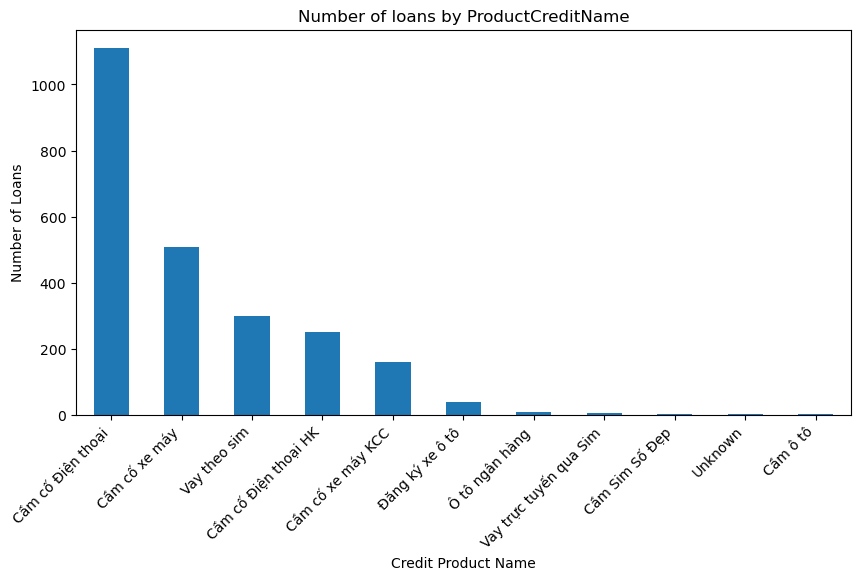

In [13]:
plt.figure(figsize=(10,5))
df['ProductCreditName'].value_counts().plot(kind='bar')
plt.title("Number of loans by ProductCreditName")
plt.xlabel("Credit Product Name")
plt.ylabel("Number of Loans")
plt.xticks(rotation=45, ha='right')
plt.show()

**1. Which loan product is most frequently used?**

- Mobile phone pawning is the most popular with 1,110 loans, accounting for nearly 50% of the entire dataset.

- Following are:

- Motorcycle pawning (Cầm cố xe máy) - 507 loans

- SIM card loans (Vay theo sim) - 298

- HK mobile phone pawning (Cầm cố điện thoại HK) - 250

- KCC motorcycle pawning (Cầm cố xe máy KCC ) - 160

→ The top 5 products account for nearly 90% of the total loans, the remaining products are mostly "long tail" loans.

In [14]:
#Total disbursement value by ProductCreditName

gmv_by_product = df.groupby('ProductCreditName')['Tiền giải ngân'].sum().sort_values(ascending=False)

gmv_by_product_formatted = gmv_by_product.apply(lambda x: f"{x:,.0f}")
gmv_by_product_formatted


ProductCreditName
Cầm cố Điện thoại         9,307,620,000
Cầm cố xe máy             5,249,322,000
Đăng ký xe ô tô           4,605,000,000
Cầm Sim Số Đẹp            2,652,735,000
Cầm cố Điện thoại HK      2,029,000,000
Cầm cố xe máy KCC         1,502,500,000
Ô tô ngân hàng            1,295,000,000
Vay theo sim                815,000,000
Cầm ô tô                    500,000,000
Vay trực tuyến qua Sim       13,000,000
Unknown                       5,000,000
Name: Tiền giải ngân, dtype: object

**2. What is the total disbursement value for each product?**

- Mobile phone pawning continues to lead with nearly 9.3 billion VND, despite being a low-value product, it has extremely high frequency.

- Motorcycle pawning ranks second with nearly 5.2 billion VND.

- Car registration ranks third with nearly 4.6 billion VND, despite only 40 applications, the average loan value is very high.

- Pawning premium phone numbers (only a few dozen applications) generated nearly 2.65 billion VND in total loan value, indicating a high-value product.

- Total loan value does not perfectly correspond to the number of applications; some products have few applications but very large loan amounts.

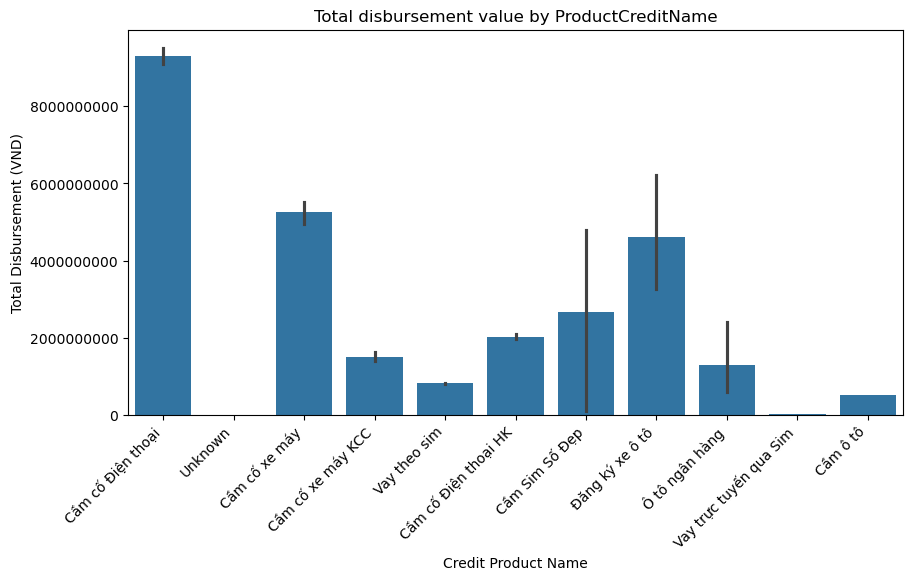

In [15]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x='ProductCreditName',
    y='Tiền giải ngân',
    estimator='sum'
)
plt.title("Total disbursement value by ProductCreditName")
plt.xlabel("Credit Product Name")
plt.ylabel("Total Disbursement (VND)")
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')


plt.show()


In [16]:
#Average disbursement value by credit product
gmv_avg = df.groupby('ProductCreditName')['Tiền giải ngân'].mean().sort_values(ascending=False)
gmv_avg_formatted = gmv_avg.apply(lambda x: f"{x:,.0f}")
gmv_avg_formatted

ProductCreditName
Cầm Sim Số Đẹp            884,245,000
Cầm ô tô                  500,000,000
Ô tô ngân hàng            161,875,000
Đăng ký xe ô tô           115,125,000
Cầm cố xe máy              10,353,692
Cầm cố xe máy KCC           9,390,625
Cầm cố Điện thoại           8,385,243
Cầm cố Điện thoại HK        8,116,000
Unknown                     5,000,000
Vay theo sim                2,734,899
Vay trực tuyến qua Sim      2,600,000
Name: Tiền giải ngân, dtype: object

**3. Average disbursement value per loan by product?**

- Pawning of premium phone numbers has the highest average value: nearly 884 million VND/loan (very large).

- Pawning of cars: nearly 500 million VND/loan.

- Cars secured by banks: nearly 161 million VND/loan.

- Popular product group (Pawning of phones, motorbikes, SIM cards) has an average value of only about 8-10 million VND/loan.

--> Clearly shows a stratification between mass-market and high-value products.

**OVERALL INSIGHT**

TIMA's credit product portfolio shows a clear differentiation between mass-market and high-value products. "Pawning Mobile Phones" and "Pawning Motorcycles" are the two products with the most loan amounts, with "Pawning Mobile Phones" accounting for nearly half of all applications, indicating a dominant demand for quick, small loans among TIMA's customer base. Meanwhile, products like "Pawning Premium Phone Numbers," "Pawning Cars," or "Bank-backed Cars" have a smaller number of applications but a very high average loan value, contributing significantly to the total disbursed funds. This suggests that TIMA's lending operations consist of two distinct parts: one part comprises small, fast-turnover, and common loans; the other part consists of a small number of large, high-value loans requiring more careful risk management. This product structure helps TIMA maintain a stable transaction volume while generating additional revenue from high-value products, albeit with low frequency.

**Loan Status**

1. What is the distribution of each status category?

2. What is the overall non-performing loan (NPL) ratio?

3. Which group constitutes the majority in the dataset?

4. Is the status distribution balanced or skewed (imbalanced dataset)?

In [17]:
df['LoanStatus'].value_counts()

LoanStatus
Hoàn thành    1586
Muộn           525
Nợ xấu         206
Đang vay        66
Name: count, dtype: int64

**Insight 1**

“Completed (Hoàn thành)” is the overwhelmingly dominant status with 1,586 loans, equivalent to approximately 66.6% of the total number of loans.

“Delayed (Muộn)” ranks second with 525 loans (~22.0%), about eight times higher than the “On Loan (Đang vay)” group (66 loans, ~2.8%).

Meanwhile, “Non-performing Loans” account for 206 loans (~8.6%), reflecting an existing risk ratio but not representing the majority of the data.

In [18]:
df['LoanStatus'].value_counts(normalize=True).round(4) * 100

LoanStatus
Hoàn thành    66.55
Muộn          22.03
Nợ xấu         8.64
Đang vay       2.77
Name: proportion, dtype: float64

In [19]:
npl = (df['LoanStatus'] == 'Nợ xấu').mean() * 100
print(f"NPL ratio: {npl:.2f}%")

NPL ratio: 8.64%


**Insight 2**

--> This is a low rate, much lower than the average for consumer credit.

--> However, this does not accurately reflect the risk, as the "Late" group still accounts for a significant proportion.

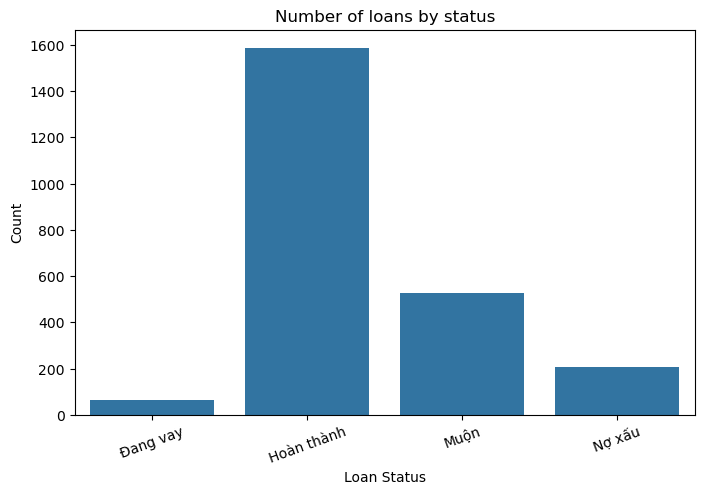

In [20]:
#Number of loans by status
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='LoanStatus')
plt.title("Number of loans by status")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()


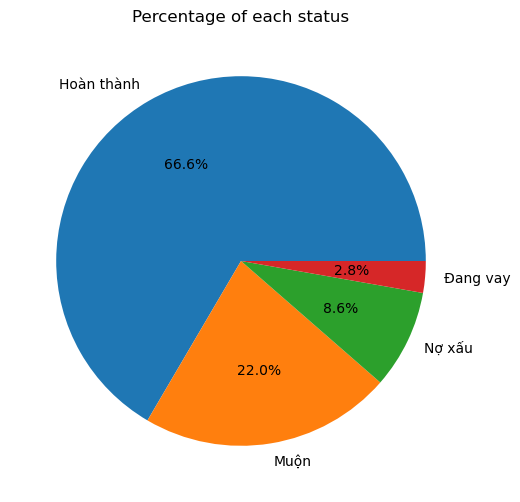

In [21]:
#Percentage of each status
df['LoanStatus'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6),
    ylabel='',
    title='Percentage of each status'
)
plt.show()

**Overall Insight**

The loan status distribution shows that the majority of records in the dataset are in the "Completed (Hoàn thành)" state, accounting for approximately 66.6% of the total loans. This indicates that the current data heavily favors completed loans, while the number of "Ongoing (Đang vay)" loans is very small (only about 2.8%).

However, the "Overdue (Muộn)" group accounts for a significant proportion (approximately 22.0%), much higher than the "Ongoing (Đang vay)" group. This suggests that although the "Non-Performing Loan" ratio is only 8.64%, the actual risk may not be fully reflected if only looking at NPLs, as a large portion of loans are overdue and have the potential to become non-performing in the future.

**GROUP 2 — Demographics**

**Gender**

1. What is the gender distribution (Male/Female) in the dataset?

2. Which group has a higher proportion?

3. Does gender influence loan level or status? (Multivariate analysis)

In [22]:
#Number of loans by gender (1-Male, 0-Female)
df['Gender'].value_counts()

Gender
0.0        1519
1.0         860
Unknown       4
Name: count, dtype: int64

In [23]:
#Percentage of each gender
df['Gender'].value_counts(normalize=True).round(4) * 100

Gender
0.0        63.74
1.0        36.09
Unknown     0.17
Name: proportion, dtype: float64

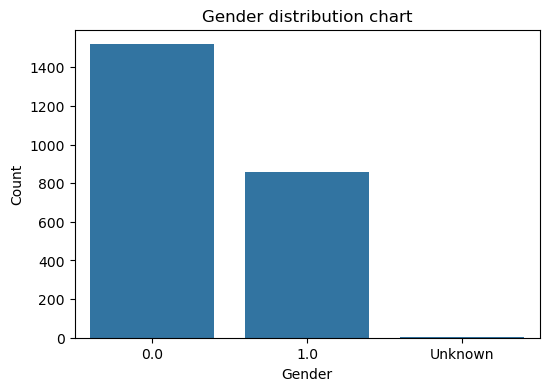

In [24]:
#Gender distribution chart
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender')
plt.title("Gender distribution chart")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

**Overall Insight:**

The gender distribution in the dataset shows that the proportion of female customers is almost double that of male customers (approximately 64% female and 36% male). This reflects that TIMA's loan portfolio tends to focus on female customers, who are often more prevalent in small consumer loan products.

**Age**

1. How is the age distribution of customers?

2. What is the most common age range?

3. Are there any unusually young or old customers (outliers)?

4. Is the age distribution skewed?

5. Who is the primary age group of TIMA customers?

In [25]:
df['Age'].describe().to_frame()

,Age
count,2377.000000
mean,30.949937
std,6.737223
min,0.000000
25%,26.000000
50%,29.000000
75%,35.000000
max,59.000000


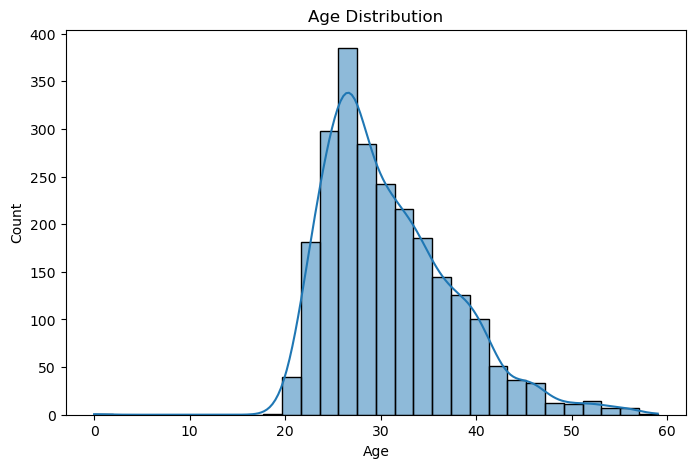

In [26]:
#Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

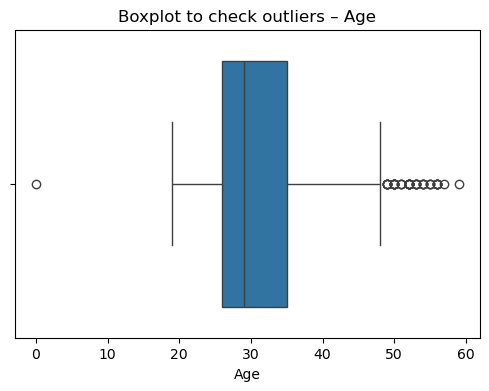

In [27]:
#Outlier age check
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Age'])
plt.title("Boxplot to check outliers – Age")
plt.xlabel("Age")
plt.show()

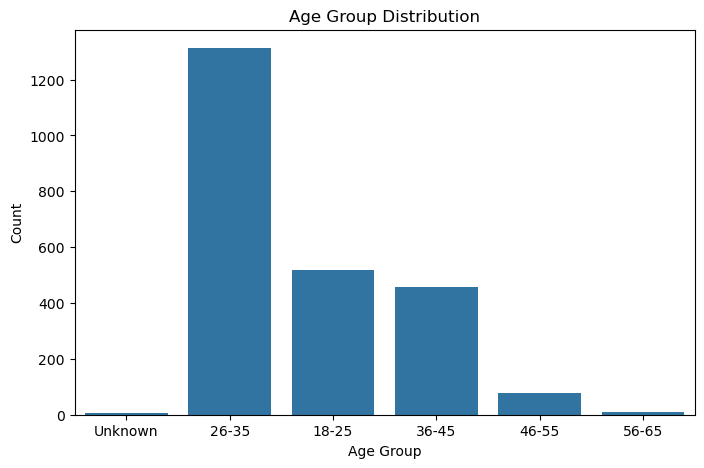

In [28]:
#Age Group Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='AgeGroup')
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

**Insight:**

TIMA's customer base is primarily concentrated in the 26-35 age group, with a median of approximately 29 years, indicating that the majority of customers are young working-age individuals – a group with high consumer loan needs and good access to technology. The age distribution tends to be slightly skewed to the right, meaning the number of older customers decreases, and the group over 55 is almost negligible. The histogram and boxplot reveal some outliers in older age groups, and the value of 0 years is a data error that needs to be addressed. Overall, this age structure accurately reflects the characteristics of quick consumer loan services, where the main customers are young and middle-aged individuals whose spending needs and finances are not yet fully stable.

**CityName**

1. Which city has the most customers?

2. Are there any areas with anomalies (too many or too few)?

3. What percentage of the customer base is represented by major cities (Hanoi/Ho Chi Minh City)?

4. Is the customer distribution concentrated or dispersed?

In [29]:
#Number of customers by CityName
df['CityName'].value_counts()

CityName
Hà Nội         2060
Hồ Chí Minh     292
Phú Thọ          10
Hòa Bình          6
Vĩnh Phúc         4
Thanh Hóa         4
Hải Dương         1
Bắc Ninh          1
Lào Cai           1
Hải Phòng         1
Thái Nguyên       1
Đồng Nai          1
Yên Bái           1
Name: count, dtype: int64

In [30]:
#Percentage per city
df['CityName'].value_counts(normalize=True).round(4) * 100

CityName
Hà Nội         86.45
Hồ Chí Minh    12.25
Phú Thọ         0.42
Hòa Bình        0.25
Vĩnh Phúc       0.17
Thanh Hóa       0.17
Hải Dương       0.04
Bắc Ninh        0.04
Lào Cai         0.04
Hải Phòng       0.04
Thái Nguyên     0.04
Đồng Nai        0.04
Yên Bái         0.04
Name: proportion, dtype: float64

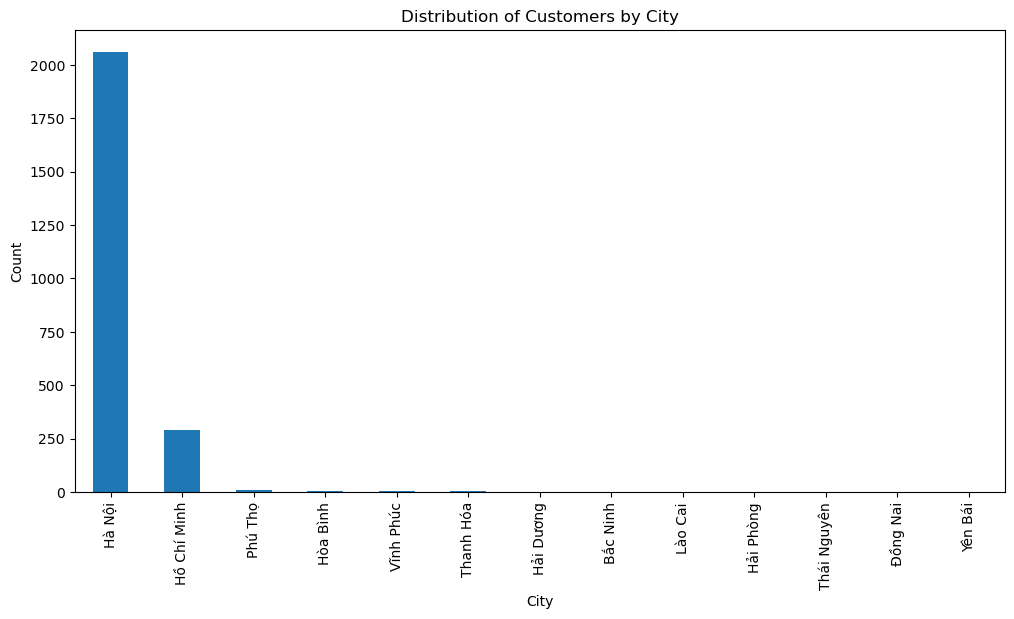

In [31]:
#The city with the most customers
plt.figure(figsize=(12,6))
df['CityName'].value_counts().plot(kind='bar')
plt.title("Distribution of Customers by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [32]:
#Check what percentage Hanoi & HCM city represent
big_cities = ['Hà Nội', 'Hồ Chí Minh']
df['CityName'].isin(big_cities).mean() * 100

np.float64(98.69911875786823)

**Insight:**

TIMA has a very high concentration of customers in Hanoi, accounting for over 86% and, along with Ho Chi Minh City, making up almost the entire dataset. The remaining provinces only account for a small percentage, indicating that TIMA's business activities during this period were mainly concentrated in these two major cities. This leads to a geographical data imbalance, affecting analysis and predictive modeling if not addressed beforehand.

**Residence Type**

1. What is the most common type of residence among customers?

2. What is the proportion of each residence group in the dataset?

3. Is there a dominant group?

4. Are there any residence groups with very few customers (making modeling difficult)?

5. Is this a factor affecting bad debt (multivariate)?

In [33]:
#Số lượng từng nhóm cư trú
df['Hình thức cư trú'].value_counts()

Hình thức cư trú
Đồng sở hữu                 712
Thuê                        569
Sở hữu cá nhân              532
Thuộc sở hữu của họ hàng    358
Khác                        142
Nhà sở hữu                   62
Sở hữu nhà nước               8
Name: count, dtype: int64

In [34]:
#Tỷ lệ phần trăm cho mỗi nhóm
df['Hình thức cư trú'].value_counts(normalize=True).round(4) * 100

Hình thức cư trú
Đồng sở hữu                 29.88
Thuê                        23.88
Sở hữu cá nhân              22.32
Thuộc sở hữu của họ hàng    15.02
Khác                         5.96
Nhà sở hữu                   2.60
Sở hữu nhà nước              0.34
Name: proportion, dtype: float64

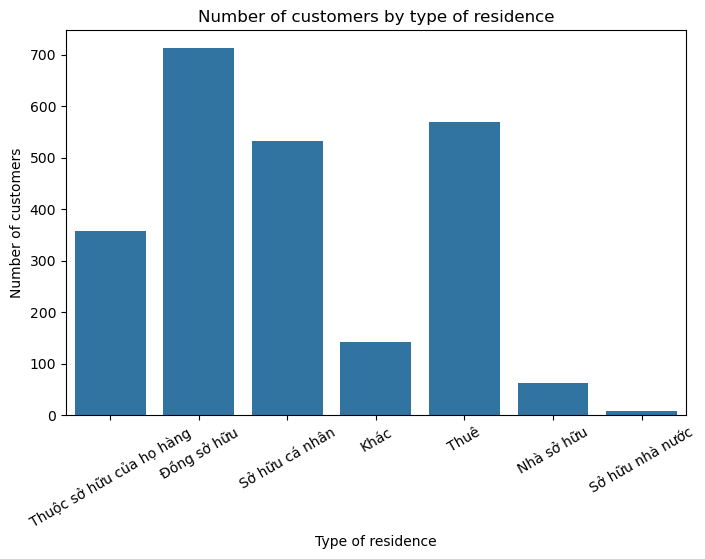

In [35]:
#Number of customers by type of residence
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Hình thức cư trú')
plt.title("Number of customers by type of residence")
plt.xlabel("Type of residence")
plt.ylabel("Number of customers")
plt.xticks(rotation=30)
plt.show()

**Insight:**
TIMA clients have a fairly diverse range of residency types, with the most prominent being the "Co-ownership" (Đồng sở hữu) group, followed by the "Renting" (Thuê) and "Individual Ownership" (Sở hữu cá nhân) groups, which together account for over 75% of the dataset. This reflects the client base's characteristics, primarily consisting of young or middle-aged individuals living with family or renting in major cities. Some residency types have very little data (such as "State-Owned" (Sở hữu nhà nước)) and need to be grouped when building the model. The relatively balanced distribution facilitates analysis and modeling, especially when considering the relationship between residency type and bad debt risk in the subsequent multivariate analysis.

**GROUP 3 — JobName / Salary**

**JobName**

1. What are the most common occupations?

2. What does the income distribution of customers look like?

3. Does average income differ across occupations?

4. Which occupations have the highest/lowest non-performing loan rates?

5. Can occupation impact loan amounts or risk? (Multivariate analysis)

In [36]:
df['JobName'].value_counts()

JobName
Nhân viên chính thức                                1087
Khác                                                 311
Các hình thức tự kinh doanh khác                     135
Tự doanh tại nhà                                      81
Nhân viên tổ chức nhà nước                            77
Nhân viên không có HĐLĐ                               75
Kinh doanh                                            69
Kinh doanh tại nhà (không có đăng ký kinh doanh)      53
Tài xế                                                52
Công nhân                                             49
Bảo vệ                                                31
Nhân sự                                               31
Giáo viên                                             29
Hành chính                                            28
Lái xe                                                26
Kế toán                                               26
Bán hàng                                              25
Tự doanh không ĐKKD    

In [37]:
#Percentage of customers by job type
df['JobName'].value_counts(normalize=True).round(4) * 100

JobName
Nhân viên chính thức                                45.61
Khác                                                13.05
Các hình thức tự kinh doanh khác                     5.67
Tự doanh tại nhà                                     3.40
Nhân viên tổ chức nhà nước                           3.23
Nhân viên không có HĐLĐ                              3.15
Kinh doanh                                           2.90
Kinh doanh tại nhà (không có đăng ký kinh doanh)     2.22
Tài xế                                               2.18
Công nhân                                            2.06
Bảo vệ                                               1.30
Nhân sự                                              1.30
Giáo viên                                            1.22
Hành chính                                           1.17
Lái xe                                               1.09
Kế toán                                              1.09
Bán hàng                                             1.05
Tự doa

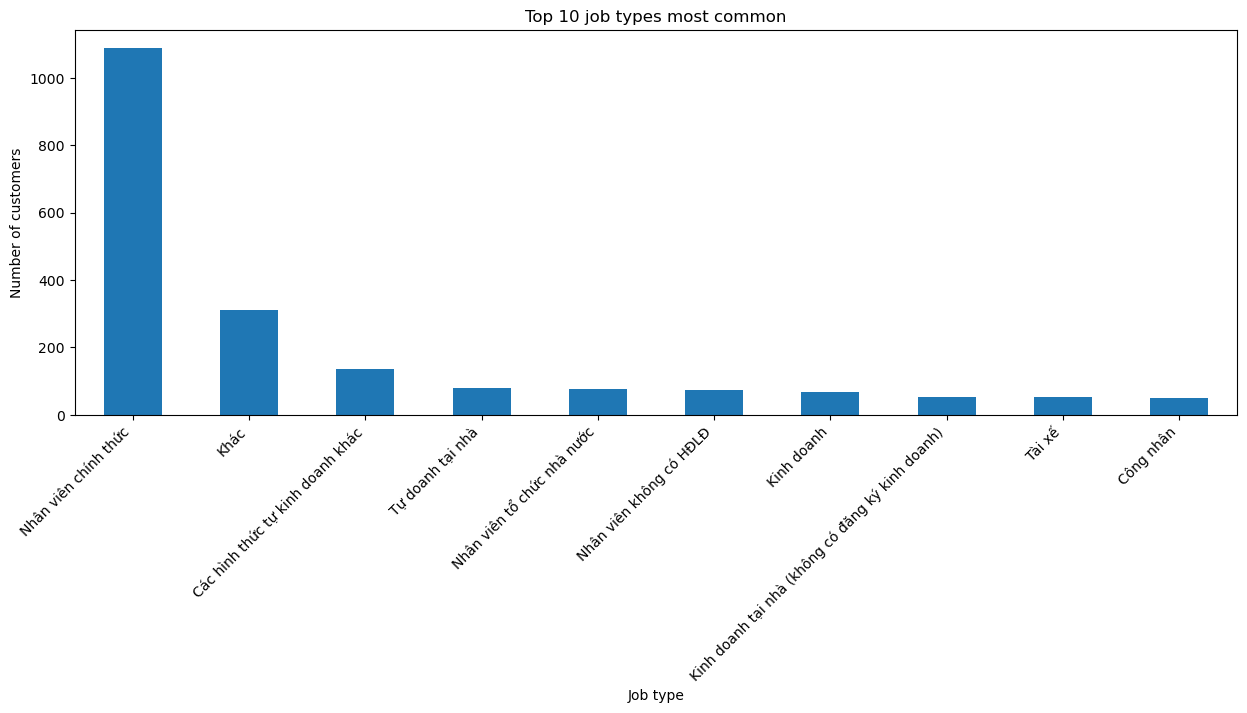

In [38]:
#Top 10 job types most common
plt.figure(figsize=(15,5))
df['JobName'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 job types most common")
plt.xlabel("Job type")
plt.ylabel("Number of customers")
plt.xticks(rotation=45, ha='right')
plt.show()

**Insight**

TIMA's clients are primarily full-time employees (Nhân viên chính thức) with stable jobs, accounting for over 45% of the dataset. In addition, a significant group comes from self-employed (Tự kinh doanh) and freelance (Lao động tự do) workers (nearly 15%), a group with volatile incomes and higher potential risks. The remainder consists of a small percentage of scattered occupations, resulting in data fragmentation.

**Salary**

1. What is the average and median income of the customers?

2. Is there a skewed income distribution?

3. Are there any outliers, where income is too low or too high?

4. Is the income appropriate for the loan amount?

In [39]:
df['Salary'].describe().to_frame().style.format("{:,.0f}")

,Salary
count,"2,383"
mean,"10,007,186"
std,"5,903,240"
min,"1,500,000"
25%,"7,000,000"
50%,"8,000,000"
75%,"11,000,000"
max,"100,000,000"


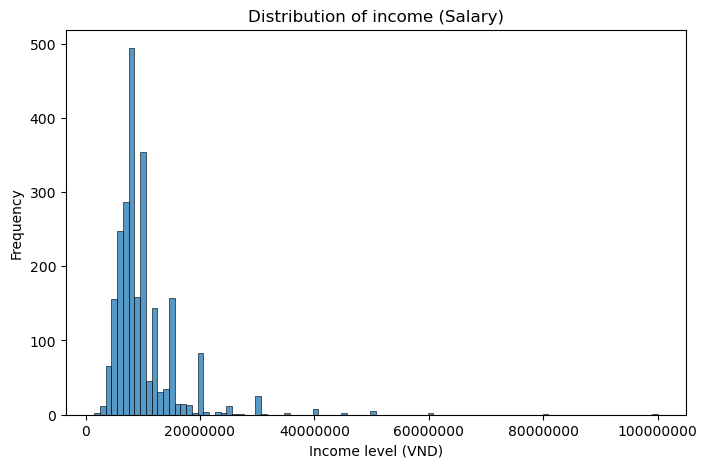

In [40]:
#Distribution of income
plt.figure(figsize=(8,5))
sns.histplot(df['Salary'], binwidth=1000000)
plt.title("Distribution of income (Salary)")
plt.xlabel("Income level (VND)")
plt.ylabel("Frequency")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

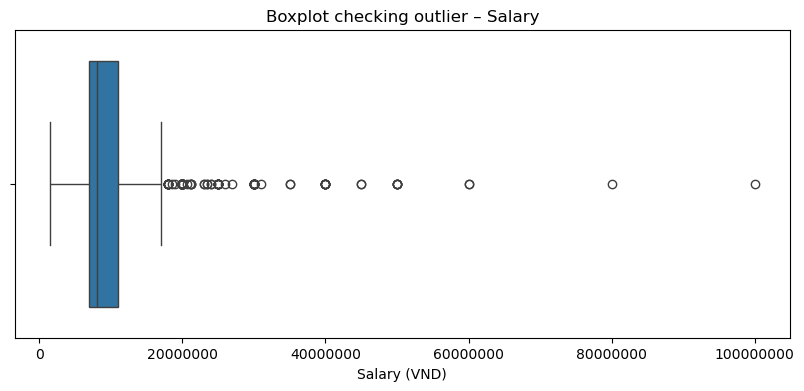

In [41]:
#Find outlier
plt.figure(figsize=(10,4))
sns.boxplot(x=df['Salary'])
plt.title("Boxplot checking outlier – Salary")
plt.xlabel("Salary (VND)")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

In [42]:
df['Salary'].value_counts()

Salary
8000000.0     443
10000000.0    342
7000000.0     234
6000000.0     173
15000000.0    154
             ... 
1500000.0       1
8300000.0       1
18600000.0      1
26000000.0      1
19000000.0      1
Name: count, Length: 107, dtype: int64

**Insight**

TIMA's customers primarily earn between 7 and 11 million VND per month, with a median of 8 million VND, reflecting the basic workforce of manual laborers and office workers. The income distribution is strongly skewed to the right due to some unusually high-income cases, creating several outliers that need to be addressed when incorporating them into the model. Overall, customer income levels are quite suitable for common loan amounts (5–10 million VND), indicating that the current loan structure is relatively reasonable compared to the customers' financial capacity.

#**GROUP 4 - RISK VARIABLES**

**TS_CREDIT_SCORE_V2**

1. What does the credit score distribution look like? (normal/skewed)

2. What are the mean, median, minimum, and maximum scores?

3. Are there any outliers or anomalies?

4. Are there any customer groups with very low scoring (high risk)?

5. Do the credit scores match the risk behaviors in the dataset?

In [43]:
df['TS_CREDIT_SCORE_V2'].describe().to_frame().style.format("{:,.0f}")

,TS_CREDIT_SCORE_V2
count,"2,383"
mean,590
std,97
min,300
25%,535
50%,599
75%,660
max,826


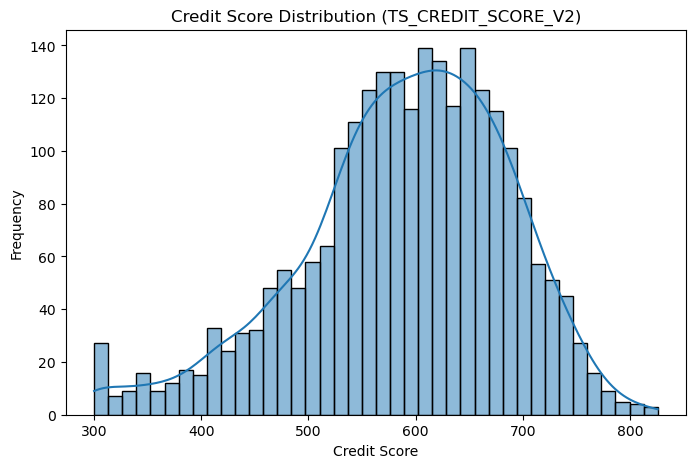

In [44]:
#Credit score distribution
plt.figure(figsize=(8,5))
sns.histplot(df['TS_CREDIT_SCORE_V2'], bins=40, kde=True)
plt.title("Credit Score Distribution (TS_CREDIT_SCORE_V2)")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

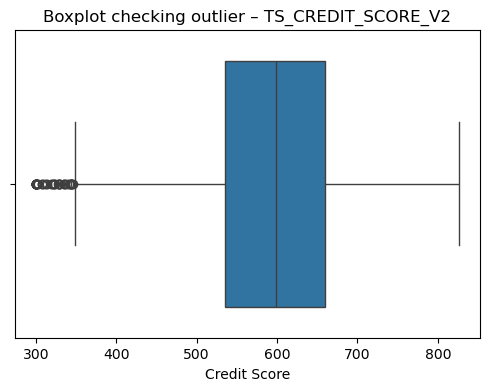

In [45]:
#Check outlier
plt.figure(figsize=(6,4))
sns.boxplot(x=df['TS_CREDIT_SCORE_V2'])
plt.title("Boxplot checking outlier – TS_CREDIT_SCORE_V2")
plt.xlabel("Credit Score")
plt.show()

In [46]:
#Credit score minimum, maximum
df['TS_CREDIT_SCORE_V2'].min(), df['TS_CREDIT_SCORE_V2'].max()

(300, 826)

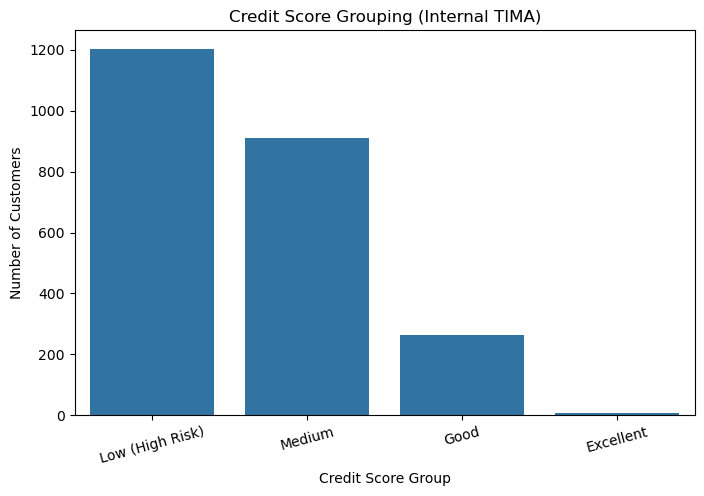

In [47]:
#Credit score grouping
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='CreditScoreGroup')
plt.title("Credit Score Grouping (Internal TIMA)")
plt.xlabel("Credit Score Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

**Insight**

TIMA's customers' internal credit scores are relatively well-distributed, with a mean of 590 and a median of 599, indicating that the majority of customers are in the average to lower-average range. Half of the customers fall into the Low (high risk) category, accurately reflecting TIMA's target customer group of limited income and financial resources. Outliers exist but are few and reasonable from a business perspective. This variable promises to be one of the strongest factors for predicting debt repayment risk in the subsequent multivariate analysis.

**HasBadDebt**

1. What percentage of customers have bad credit history (CIC)?

2. Is this percentage high? (Typically 1–5% in good data)

3. Is this the highest risk group? (Multivariate)

In [48]:
df['HasBadDebt'].value_counts()

HasBadDebt
0    2121
1     262
Name: count, dtype: int64

In [49]:
df['HasBadDebt'].value_counts(normalize=True) * 100

HasBadDebt
0    89.005455
1    10.994545
Name: proportion, dtype: float64

**Insight**

Approximately 11% of customers in the dataset had previously experienced CIC (Credit Information Center) bad debt – a relatively high percentage compared to market standards, indicating that TIMA serves a higher-than-average risk client group. This group is more likely to exhibit poor repayment behavior, becoming one of the most important variables in multivariate analysis and subsequent risk forecasting models.

**HasLatePayment**

In [50]:
df['HasLatePayment'].value_counts()

HasLatePayment
0    2047
1     336
Name: count, dtype: int64

In [51]:
df['HasLatePayment'].value_counts(normalize=True) * 100

HasLatePayment
0    85.900126
1    14.099874
Name: proportion, dtype: float64

**Insight**

The majority of customers (86%) have no history of late payments; however, nearly 14% have been late in the past—a clear risk group. This variable is crucial in the risk forecasting model because a history of late payments is a strong predictor of bad debt. The level of imbalance is not excessively large, remaining suitable for analysis and modeling.

**MULTIVARIABLE ANALYSIS**

**LoanStatus (TARGET VARIABLE)**

**LoanStatus vs ProductCreditName**

--> Risk Analysis by Credit Product

1. Which product has the highest number of bad debt records?

2. Which product has the highest non-performing loan (NPL) ratio?

3. Is there a significant difference in the status structure between products?

4. Are the most popular products of good quality or high risk?

5. Are there any products that are very risky but have a low risk concentration?

In [52]:
# Create a crosstab
pd.crosstab(df['ProductCreditName'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
ProductCreditName,,,,
Cầm Sim Số Đẹp,0,3,0,0
Cầm cố xe máy,338,133,1,35
Cầm cố xe máy KCC,105,46,7,2
Cầm cố Điện thoại,725,273,85,27
Cầm cố Điện thoại HK,202,34,13,1
Cầm ô tô,1,0,0,0
Unknown,1,0,0,0
Vay theo sim,172,26,100,0
Vay trực tuyến qua Sim,4,1,0,0


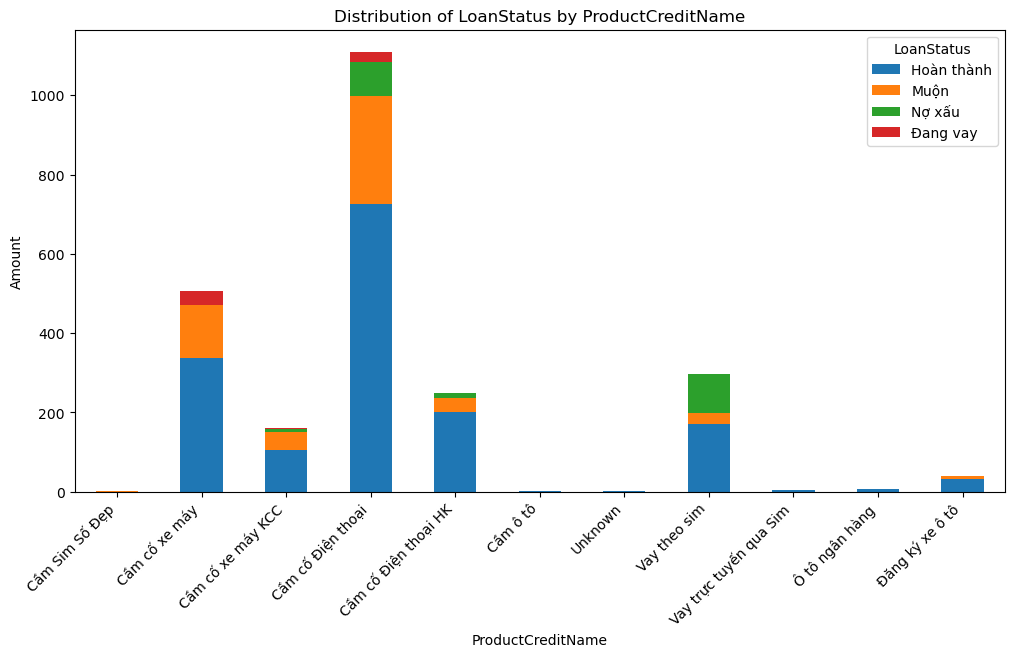

In [53]:
#Stacked bar chart – product status distribution
df_crosstab = pd.crosstab(df['ProductCreditName'], df['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Distribution of LoanStatus by ProductCreditName")
plt.xlabel("ProductCreditName")
plt.ylabel("Amount")
plt.xticks(rotation=45, ha='right')
plt.show()

In [54]:
#Calculate the Non-Performing Loan (NPL) ratio for each product
npl_by_product = (
    pd.crosstab(df['ProductCreditName'], df['LoanStatus'], normalize='index') * 100
)

npl_by_product.sort_values('Nợ xấu', ascending=False)

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
ProductCreditName,,,,
Vay theo sim,57.718121,8.724832,33.557047,0.000000
Cầm cố Điện thoại,65.315315,24.594595,7.657658,2.432432
Cầm cố Điện thoại HK,80.800000,13.600000,5.200000,0.400000
Cầm cố xe máy KCC,65.625000,28.750000,4.375000,1.250000
Cầm cố xe máy,66.666667,26.232742,0.197239,6.903353
Cầm Sim Số Đẹp,0.000000,100.000000,0.000000,0.000000
Cầm ô tô,100.000000,0.000000,0.000000,0.000000
Unknown,100.000000,0.000000,0.000000,0.000000
Vay trực tuyến qua Sim,80.000000,20.000000,0.000000,0.000000


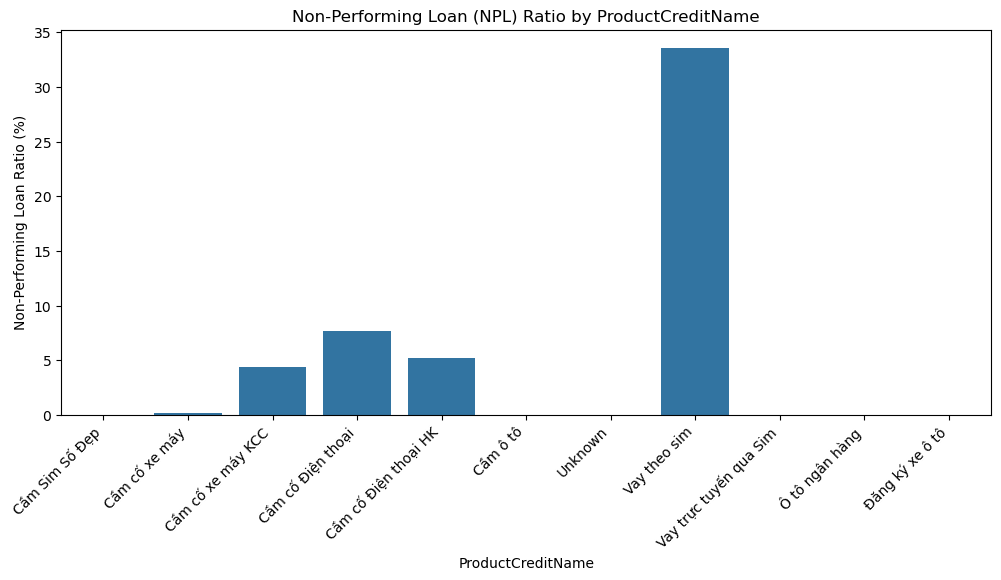

In [55]:
#Bar chart – Non-performing loan ratio by product
plt.figure(figsize=(12,5))
sns.barplot(
    data=npl_by_product.reset_index(),
    x='ProductCreditName',
    y='Nợ xấu'
)
plt.title("Non-Performing Loan (NPL) Ratio by ProductCreditName")
plt.xlabel("ProductCreditName")
plt.ylabel("Non-Performing Loan Ratio (%)")
plt.xticks(rotation=45, ha='right')
plt.show()

<Figure size 1200x600 with 0 Axes>

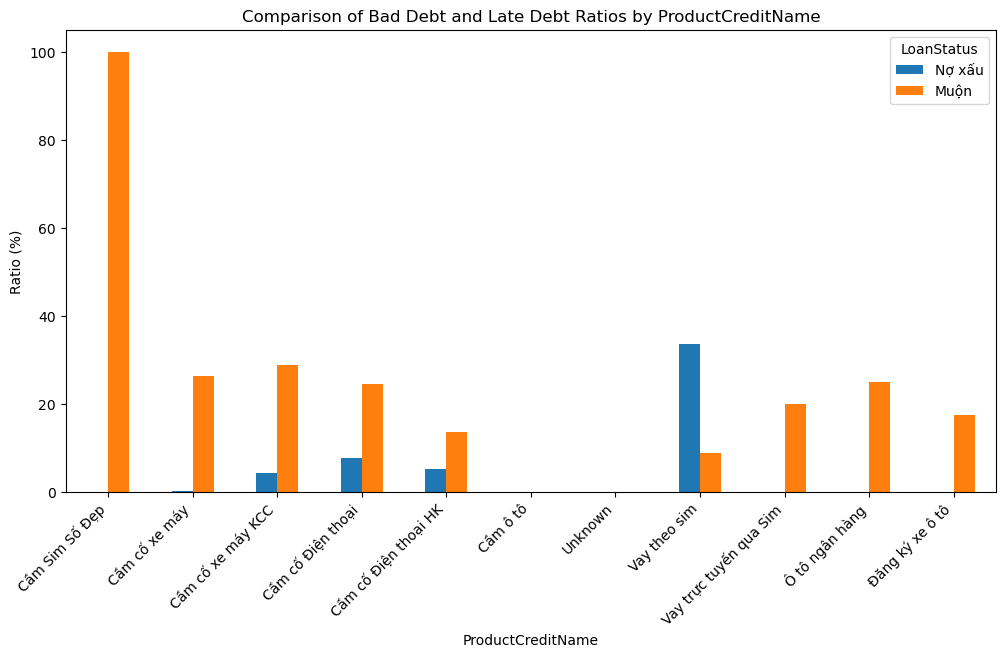

In [56]:
#Ratio of “Nợ xấu” (Bad Debt) and “Muộn” (Late Debt) by ProductCreditName
plt.figure(figsize=(12,6))
npl_by_product[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(12,6))
plt.title("Comparison of Bad Debt and Late Debt Ratios by ProductCreditName")
plt.xlabel("ProductCreditName")
plt.ylabel("Ratio (%)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="LoanStatus")
plt.show()

**Insight**

The differences in risk levels among credit products are quite evident. Phone pawning has the largest number of applications and also the highest absolute number of non-performing loans (85). However, in terms of percentage, its NPL (Non-Performing Loan) is approximately 7.66%, not the highest in the category, indicating that the risk mainly stems from the large scale rather than the extremely poor quality of the loans.

Conversely, SIM card loans have the highest non-performing loan ratio, reaching approximately 33.6%, even though the total number of applications is not as large as the pawning products. This shows that the risk is highly concentrated in this product and needs close monitoring, as even a relatively small number of applications can create a very high non-performing loan ratio.

Some other products, such as KCC motorbike pawning and HK phone pawning, have average non-performing loan (NPL) rates (around 4-5%), while motorbike pawning generally shows almost no significant NPLs in current data. However, for products with very low transaction volumes, such as premium phone number pawning, car loans, or car pawning, the absence of NPLs is not sufficient to conclude low risk, due to the small sample size.

Furthermore, the "Late" rate appears in many products, especially phone pawning, KCC motorbike pawning, and SIM card loans, indicating that short-term repayment pressure still exists even in products without high NPL rates. This is an early warning sign, indicating that risk may increase if not controlled promptly.

Overall, each product has very different risk characteristics: some products are risky due to their large scale, while others are risky due to high NPL rates. This suggests that TIMA should assess and manage risks on a product-group basis, rather than applying a single approach to the entire portfolio.

**LoanStatus vs CityName**

1. Which city has the most non-performing loans (by number)?

2. Which city has the highest non-performing loan ratio (by %)?

3. Do major cities (Hanoi, Ho Chi Minh City) have better quality than provinces?

4. Are there any provinces with few cases but very high risk?

In [57]:
pd.crosstab(df['CityName'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
CityName,,,,
Bắc Ninh,1,0,0,0
Hà Nội,1438,402,171,49
Hòa Bình,6,0,0,0
Hải Dương,1,0,0,0
Hải Phòng,1,0,0,0
Hồ Chí Minh,123,122,30,17
Lào Cai,0,0,1,0
Phú Thọ,8,0,2,0
Thanh Hóa,3,0,1,0


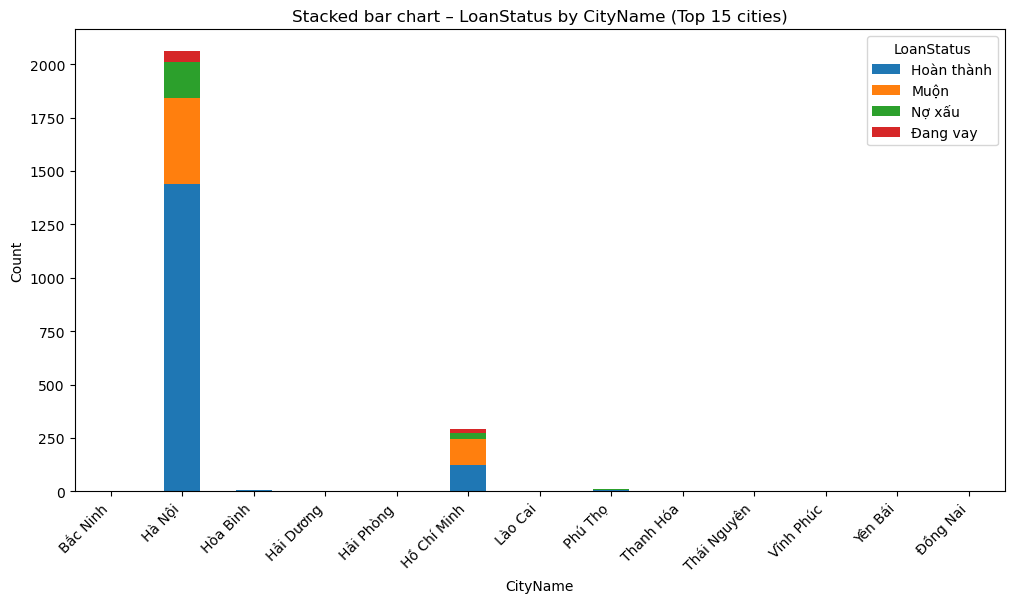

In [58]:
#Stacked bar chart – LoanStatus by CityName
top_cities = df['CityName'].value_counts().head(15).index
subset = df[df['CityName'].isin(top_cities)]

df_crosstab = pd.crosstab(subset['CityName'], subset['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Stacked bar chart – LoanStatus by CityName (Top 15 cities)")
plt.xlabel("CityName")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

In [59]:
#Calculate the Non-Performing Loan (NPL) ratio by CityName
npl_by_city = (
    pd.crosstab(df['CityName'], df['LoanStatus'], normalize='index') * 100
)

npl_by_city.sort_values('Nợ xấu', ascending=False)

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
CityName,,,,
Lào Cai,0.000000,0.000000,100.000000,0.000000
Thanh Hóa,75.000000,0.000000,25.000000,0.000000
Vĩnh Phúc,75.000000,0.000000,25.000000,0.000000
Phú Thọ,80.000000,0.000000,20.000000,0.000000
Hồ Chí Minh,42.123288,41.780822,10.273973,5.821918
Hà Nội,69.805825,19.514563,8.300971,2.378641
Bắc Ninh,100.000000,0.000000,0.000000,0.000000
Hòa Bình,100.000000,0.000000,0.000000,0.000000
Hải Dương,100.000000,0.000000,0.000000,0.000000


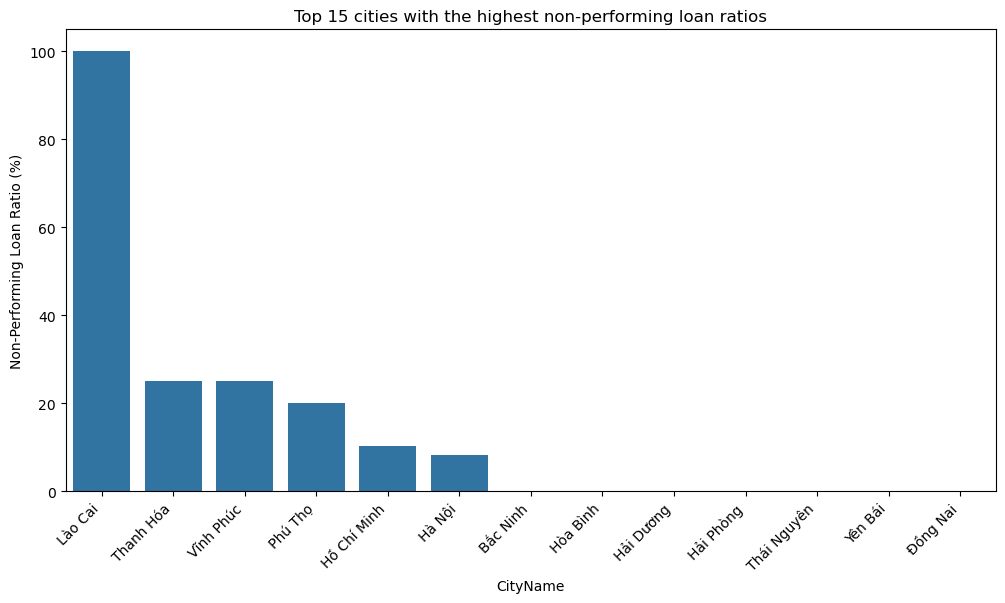

In [60]:
# Non-performing loan ratio by CityName
plt.figure(figsize=(12,6))
sns.barplot(
    data=npl_by_city.reset_index().nlargest(15, 'Nợ xấu'),
    x='CityName',
    y='Nợ xấu'
)
plt.title("Top 15 cities with the highest non-performing loan ratios")
plt.xlabel("CityName")
plt.ylabel("Non-Performing Loan Ratio (%)")
plt.xticks(rotation=45, ha='right')
plt.show()

<Figure size 1200x600 with 0 Axes>

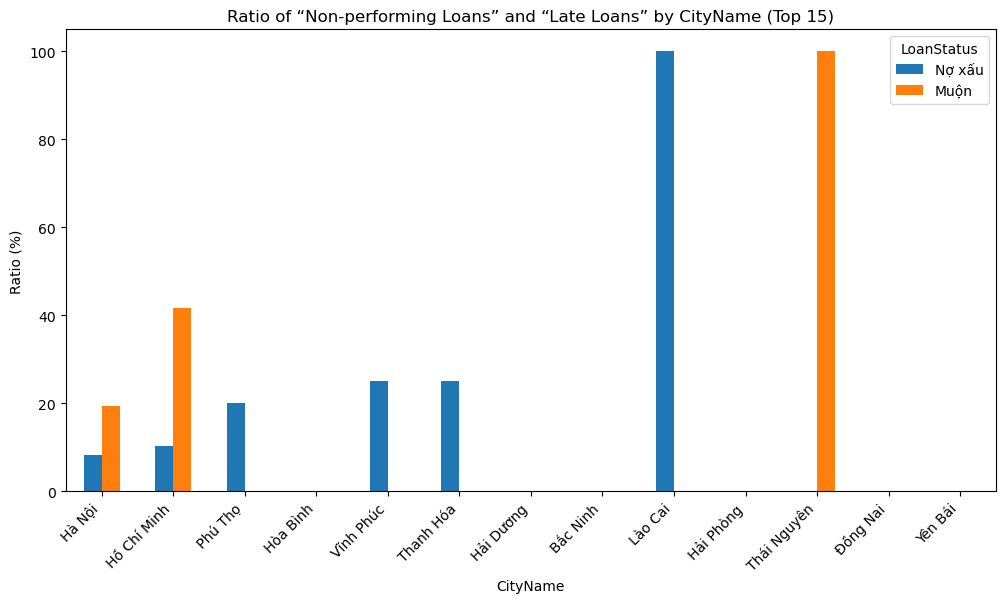

In [61]:
#Ratio of “Non-performing Loans” and “Late Loans” by CityName
plt.figure(figsize=(12,6))
npl_by_city[['Nợ xấu', 'Muộn']].loc[top_cities].plot(kind='bar', figsize=(12,6))
plt.title("Ratio of “Non-performing Loans” and “Late Loans” by CityName (Top 15)")
plt.xlabel("CityName")
plt.ylabel("Ratio (%)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="LoanStatus")
plt.show()

In [62]:
#Combine provinces/cities with < 20 applications into "Other"
#Count the number of applications by province/city
city_counts = df['CityName'].value_counts()

# Identify provinces/cities with fewer than 20 records
rare_cities = city_counts[city_counts < 20].index

# Create a new column: CityName_grouped
df['CityName_grouped'] = df['CityName'].where(~df['CityName'].isin(rare_cities), 'Khác')


In [63]:
risk_by_city_grouped = (
    pd.crosstab(df['CityName_grouped'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_city_grouped

LoanStatus,Nợ xấu,Muộn
CityName_grouped,,
Hà Nội,8.300971,19.514563
Hồ Chí Minh,10.273973,41.780822
Khác,16.129032,3.225806


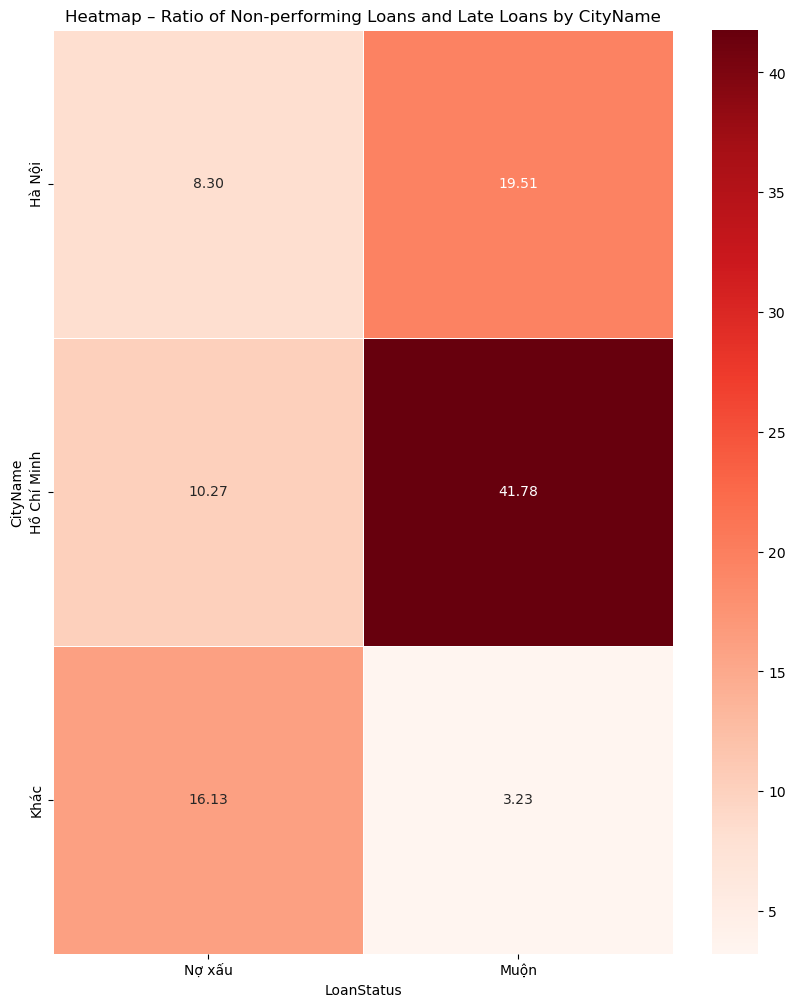

In [64]:
#Heatmap
plt.figure(figsize=(10,12))
sns.heatmap(
    risk_by_city_grouped,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=.5
)
plt.title("Heatmap – Ratio of Non-performing Loans and Late Loans by CityName")
plt.xlabel("LoanStatus")
plt.ylabel("CityName")
plt.show()

**Insight**

The analysis reveals significant regional risk differences, with Hanoi and Ho Chi Minh City accounting for the majority of the portfolio. Therefore, risk indicators in these two regions significantly impact the overall portfolio picture.

In Hanoi, the non-performing loan (NPL) ratio is approximately 8.3% and the "Muộn" (Late) ratio is around 19.5%, reflecting a medium risk level, consistent with a large market with a high portfolio size. This structure indicates that the majority of loans remain under control, although a significant group of customers are making late payments.

Meanwhile, Ho Chi Minh City has a significantly higher "Muộn" (Late) ratio (approximately 41.8%), considerably higher than Hanoi, while the NPL ratio is around 10.3%. This suggests that customers in Ho Chi Minh City tend to make more late payments, but this has not yet resulted in correspondingly bad debt. This is a sign of potential risk, especially if the "Late" status persists for an extended period.

For provinces with a small number of files, the appearance of very high non-performing or "Late" loan ratios (e.g., 25% or 100%) does not reflect true risk, but is mainly due to the small sample size. When provinces with fewer than 20 files are grouped into the "Other" category, the non-performing loan ratio is approximately 16.1% while the "Late" ratio is only about 3.2%, indicating that the risk in smaller provinces is not as high as the initial individual ratios suggest.

Overall, portfolio risk is concentrated mainly in large cities, especially Ho Chi Minh City with its high "Late" ratio, while smaller provinces need to be assessed cautiously due to data limitations. This suggests that regional risk management should prioritize monitoring the "Late" group in large markets, rather than relying solely on the current non-performing loan ratio.

**LoanStatus vs AgeGroup**

1. Which age group has the highest rate of bad debt?

2. Which age group has the highest rate of late payments?

3. Is there a trend of "younger age → higher risk"?

4. Do older age groups have lower or higher risk?

5. Is there a particularly high-risk age group (18–22)?

In [65]:
pd.crosstab(df['AgeGroup'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
AgeGroup,,,,
18-25,328,116,58,18
26-35,886,275,117,35
36-45,314,105,28,11
46-55,50,23,3,1
56-65,3,5,0,0
Unknown,5,1,0,1


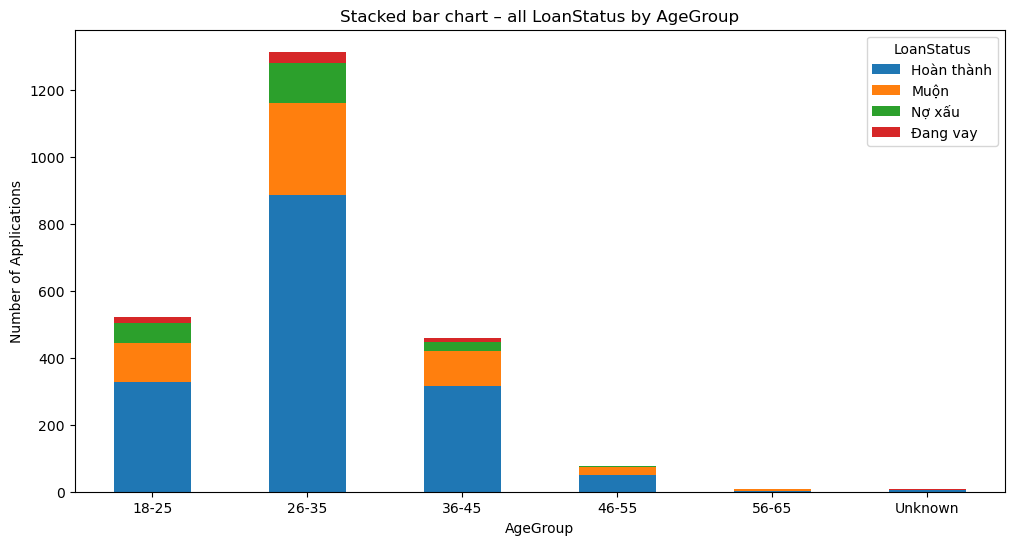

In [66]:
#Stacked bar chart – all LoanStatus by AgeGroup
df_crosstab = pd.crosstab(df['AgeGroup'], df['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Stacked bar chart – all LoanStatus by AgeGroup")
plt.xlabel("AgeGroup")
plt.ylabel("Number of Applications")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

In [67]:
#Ratio of Non-performing Loans and Late Loans by AgeGroup
risk_by_age = (
    pd.crosstab(df['AgeGroup'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_age

LoanStatus,Nợ xấu,Muộn
AgeGroup,,
18-25,11.153846,22.307692
26-35,8.910891,20.944402
36-45,6.113537,22.925764
46-55,3.896104,29.870130
56-65,0.000000,62.500000
Unknown,0.000000,14.285714


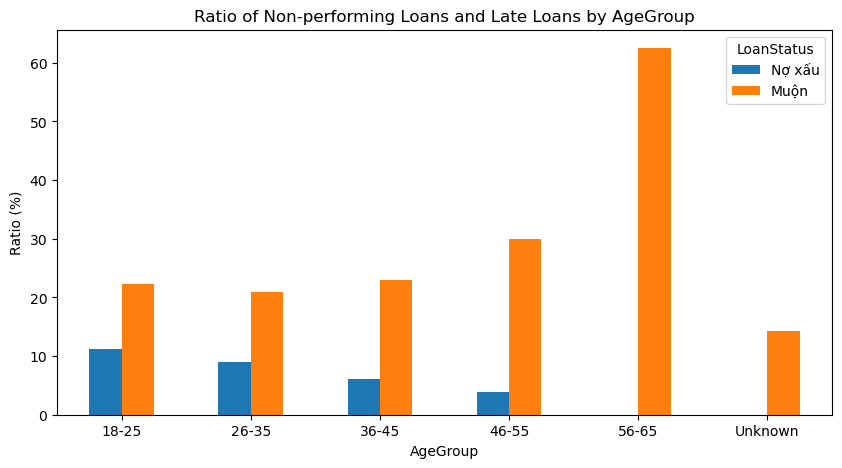

In [68]:
#Ratio of Non-performing Loans and Late Loans by AgeGroup
risk_by_age[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(10,5))
plt.title("Ratio of Non-performing Loans and Late Loans by AgeGroup")
plt.xlabel("AgeGroup")
plt.ylabel("Ratio (%)")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

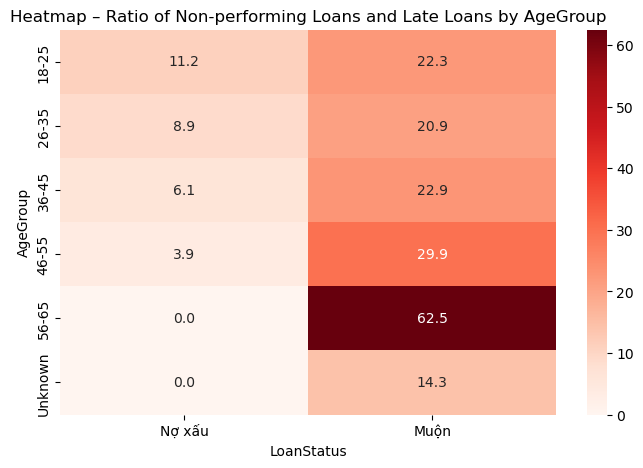

In [69]:
plt.figure(figsize=(8,5))
sns.heatmap(
    risk_by_age,
    annot=True,
    cmap="Reds",
    fmt=".1f"
)
plt.title("Heatmap – Ratio of Non-performing Loans and Late Loans by AgeGroup")
plt.show()

**Insight**

The 26-35 age group accounts for the largest number of records in the dataset, and also has the highest absolute number of "Late" and "Bad Debt" records. However, in terms of percentage, this is not the highest risk group, suggesting that large size is the main reason for the high number of risky records.

The 18-25 age group has the highest rate of Bad Debt among all age groups (approximately 11.2%), and the rate of Late payments is also quite high (~22%). This indicates that younger age groups have a higher risk level, possibly due to unstable income or limited financial experience.

The 36-45 age group has a lower rate of Bad Debt compared to the two younger groups, but the rate of Late payments remains high (~22.9%). This suggests that the risk in this group is not about complete inability to repay debt, but mainly about delayed payments.

The 46–55 age group has a low rate of non-performing loans (~3.9%) but a nearly 30% rate of overdue payments. This indicates potential financial pressure at this stage, even if it hasn't yet resulted in non-performing loans.

The 56–65 age group has a very high rate of overdue payments (62.5%) but no non-performing loans. However, the number of cases in this group is very small, so the results are more of a warning than a definitive conclusion. This age group needs to be monitored separately due to the risk of prolonged overdue payments.

Overall, the data shows that risk does not decrease with age as expected. Non-performing loans are more concentrated in younger age groups (18–25), while overdue payments are significantly higher in older age groups. This suggests that risk management should be differentiated by age group, paying particular attention to younger and older groups with high signs of overdue payments.

**LoanStatus vs Gender**

1. Do men and women have different loan statuses?

2. Which gender has a higher percentage of which status?

3. Which gender has a higher rate of bad debt?

4. Which gender has a higher rate of late payments?

5. Are there significant differences in credit behavior between men and women?

6. Is gender a significant risk factor?

In [70]:
pd.crosstab(df['Gender'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
Gender,,,,
0.0,1028,308,142,41
1.0,555,216,64,25
Unknown,3,1,0,0


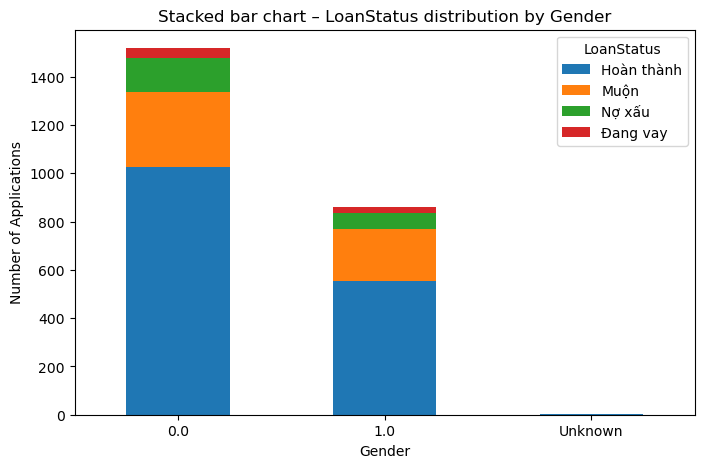

In [71]:
#Stacked bar chart – LoanStatus distribution by Gender
df_crosstab = pd.crosstab(df['Gender'], df['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Stacked bar chart – LoanStatus distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Applications")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

In [72]:
#Ratio of Non-performing Loans and Late Loans by Gender
risk_by_gender = (
    pd.crosstab(df['Gender'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_gender

LoanStatus,Nợ xấu,Muộn
Gender,,
0.0,9.348255,20.276498
1.0,7.441860,25.116279
Unknown,0.000000,25.000000


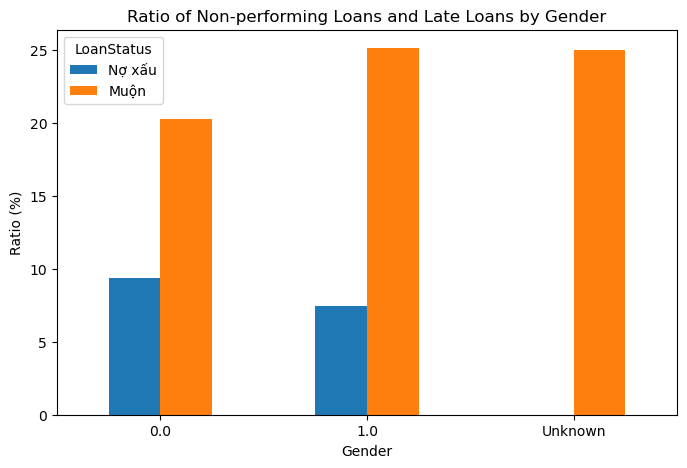

In [73]:
risk_by_gender[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(8,5))
plt.title("Ratio of Non-performing Loans and Late Loans by Gender")
plt.xlabel("Gender")
plt.ylabel("Ratio (%)")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

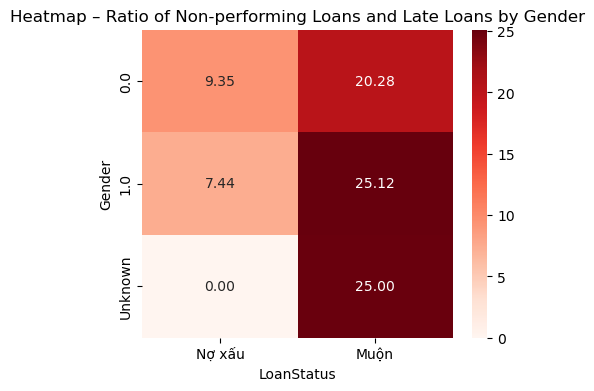

In [74]:
plt.figure(figsize=(5,4))
sns.heatmap(
    risk_by_gender,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)
plt.title("Heatmap – Ratio of Non-performing Loans and Late Loans by Gender")
plt.show()

**Insight**

Regarding bad debt, the Gender = 0 (Female) group has a higher rate (~9.35%) than the Gender = 1 (Male) group (~7.44%). This difference is not significant, indicating that gender is not a strong determinant of bad debt in the dataset.

Conversely, in the "Late" state, the Gender = 1 group has a significantly higher rate (~25.1%) than the Gender = 0 group (~20.3%). This suggests that the Gender = 1 group tends to make more late payments, even if they haven't yet become bad debt.

Overall, both genders have a much higher rate of "Late" payments than "Bad Debt," indicating that the main issue in the portfolio lies in late payment behavior, rather than complete inability to repay.

In conclusion:
Gender is not a prominent risk factor when considered in isolation. However, the difference in the "Late" rate suggests that gender may indirectly influence the outcome through other factors such as income, loan product type, or financial behavior. Therefore, incorporating other variables (age, product, income, etc.) is necessary for a more comprehensive assessment, rather than relying solely on gender as the primary criterion.

**LoanStatus vs Salary**

1. Do high/low incomes have different LoanStatus distributions?

2. Does income correlate with the ability to repay loans on time?

3. Does low income lead to a higher rate of bad debt?

4. Does low income lead to a higher rate of late payments?

5. Is there such a thing as a “risky” income level?

6. Does a high income truly mean low risk?

In [75]:
pd.crosstab(df['IncomeBracket'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
IncomeBracket,,,,
10-15m,268,111,26,8
15-25m,98,43,6,5
5-10m,1041,334,148,45
<5m,143,25,25,8
>=25m,36,12,1,0


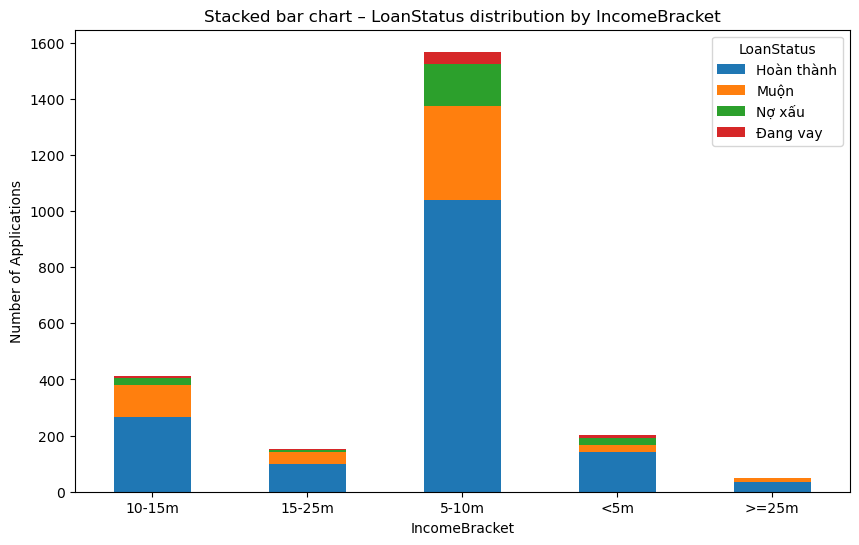

In [76]:
#Stacked bar chart – LoanStatus distribution by IncomeBracket
df_crosstab = pd.crosstab(df['IncomeBracket'], df['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Stacked bar chart – LoanStatus distribution by IncomeBracket")
plt.xlabel("IncomeBracket")
plt.ylabel("Number of Applications")
plt.legend(title="LoanStatus")
plt.xticks(rotation=0)
plt.show()

In [77]:
#Ratio of Non-performing Loans and Late Loans by IncomeBracket
risk_by_salary = (
    pd.crosstab(df['IncomeBracket'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_salary

LoanStatus,Nợ xấu,Muộn
IncomeBracket,,
10-15m,6.295400,26.876513
15-25m,3.947368,28.289474
5-10m,9.438776,21.301020
<5m,12.437811,12.437811
>=25m,2.040816,24.489796


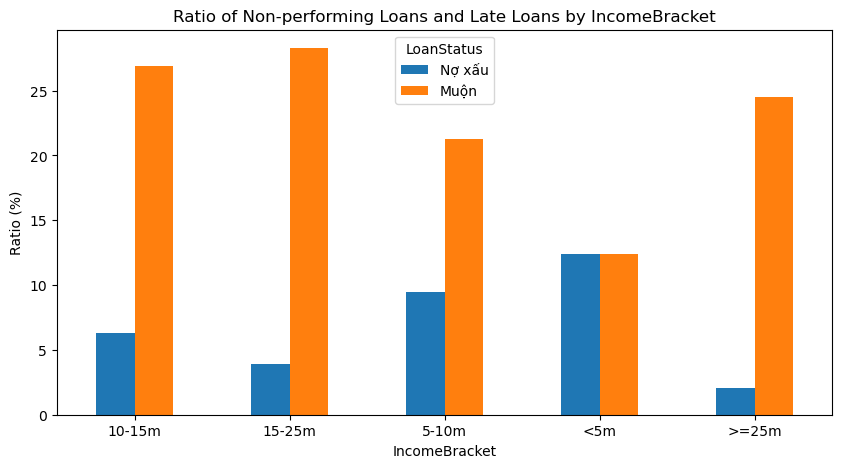

In [78]:
#Stacked bar chart – Ratio of Non-performing Loans and Late Loans by IncomeBracket
risk_by_salary[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(10,5))
plt.title("Ratio of Non-performing Loans and Late Loans by IncomeBracket")
plt.xlabel("IncomeBracket")
plt.ylabel("Ratio (%)")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

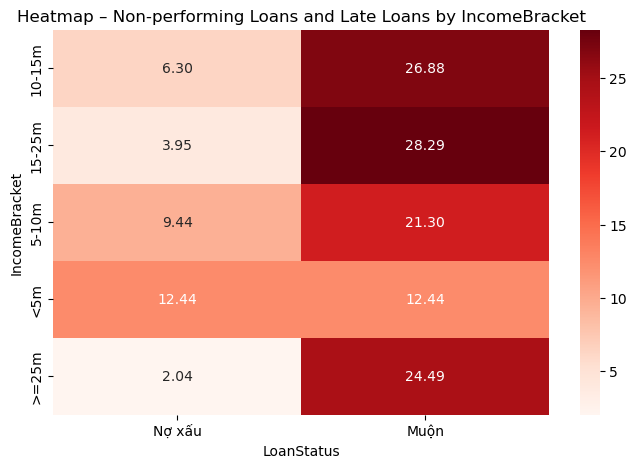

In [79]:
#Heatmap – see which income group is at the highest risk
plt.figure(figsize=(8,5))
sns.heatmap(
    risk_by_salary,
    annot=True,
    cmap="Reds",
    fmt=".2f"
)
plt.title("Heatmap – Non-performing Loans and Late Loans by IncomeBracket")
plt.show()

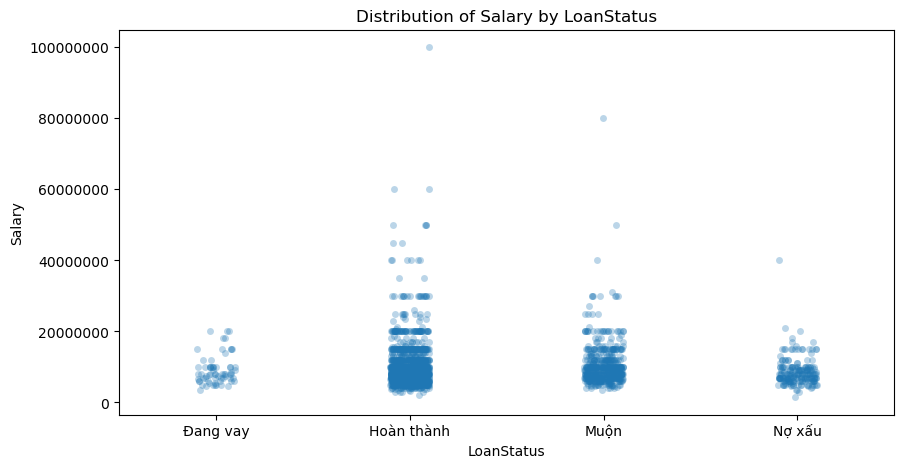

In [80]:
#Scatterplot – Salary vs LoanStatus
plt.figure(figsize=(10,5))
sns.stripplot(
    data=df,
    x='LoanStatus',
    y='Salary',
    alpha=0.3
)
plt.title("Distribution of Salary by LoanStatus")
plt.ylabel("Salary")
plt.xlabel("LoanStatus")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight**

Analysis of the relationship between income and loan status reveals some noteworthy points, but not as extreme as the original.

1. Low-income groups (<5 million and 5–10 million)

The <5 million group has the highest Non-Performing Loan (NPL) rate (~12.4%), and the Delay Rate is also high (~12.4%).

The 5–10 million group has a fairly high Delay Rate (~21.3%) and NPLs of approximately 9.4%.

--> This indicates that low-income groups have a significantly higher risk, especially the risk of becoming NPLs.

2. Middle-income groups (10–15 million and 15–25 million)

These two groups have significantly lower NPL rates (approximately 4–6%).

However, the Delay Rate remains quite high (approximately 26–28%).

--> This group is relatively stable in terms of bad debt, but still faces the risk of late payments, which may be related to short-term cash flow rather than default.

3. High-income group (≥25 million VND)

The bad debt ratio is very low (~2%).

However, the late payment rate remains high (~24.5%), not significantly lower than the middle-income group.

--> High income does not necessarily mean always paying on time. This group may experience late payments due to behavioral factors (subjective, multiple loans simultaneously), although they are less likely to fall into bad debt.

4. The most "risky" income group

Overall, the group with incomes <5 million VND is the most vulnerable because:

The highest bad debt ratio

The late payment rate is also high

Other groups mainly have late payment problems, which have not yet significantly transformed into bad debt.

5. General Conclusion

Income is related to risk, but it is not the sole determining factor.

Low income is a clear warning sign of bad debt.

Even high incomes can still result in significant late payments, so risk cannot be assessed solely based on salary.

6. Suggestions

<10 million VND: stricter conditions, lower limits, early debt reminders.

10–25 million VND: relatively safe group, can be expanded but requires managing late payment behavior.

≥25 million VND: requires monitoring borrowing behavior and repayment history; should not be assumed to be low risk.

**LoanStatus vs JobName**

1. Which professions have the best loan quality (high "Fully Repaid" rate)?

2. Which professions tend to have a high rate of "Delays"?

3. Which professions have the highest rate of "Non-Performing Loans"?

4. Which professions have the highest rate of "Delays"?

5. Do stable jobs (office workers) have lower risk than freelancers/workers?

6. Are there any professions with few loan applications but extremely high risk?

In [81]:
pd.crosstab(df['JobName'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
JobName,,,,
Bán hàng,8,15,0,2
Bảo vệ,20,9,1,1
Bộ đội / công an,4,0,0,0
CQ Hành chính Nhà nước,7,2,0,0
Chăm sóc KH,3,3,0,1
Các hình thức tự kinh doanh khác,103,18,13,1
Công nhân,14,24,6,5
Công việc ko ổn định/Thu nhập thất thường,0,1,0,0
Giám Sát,10,10,0,1


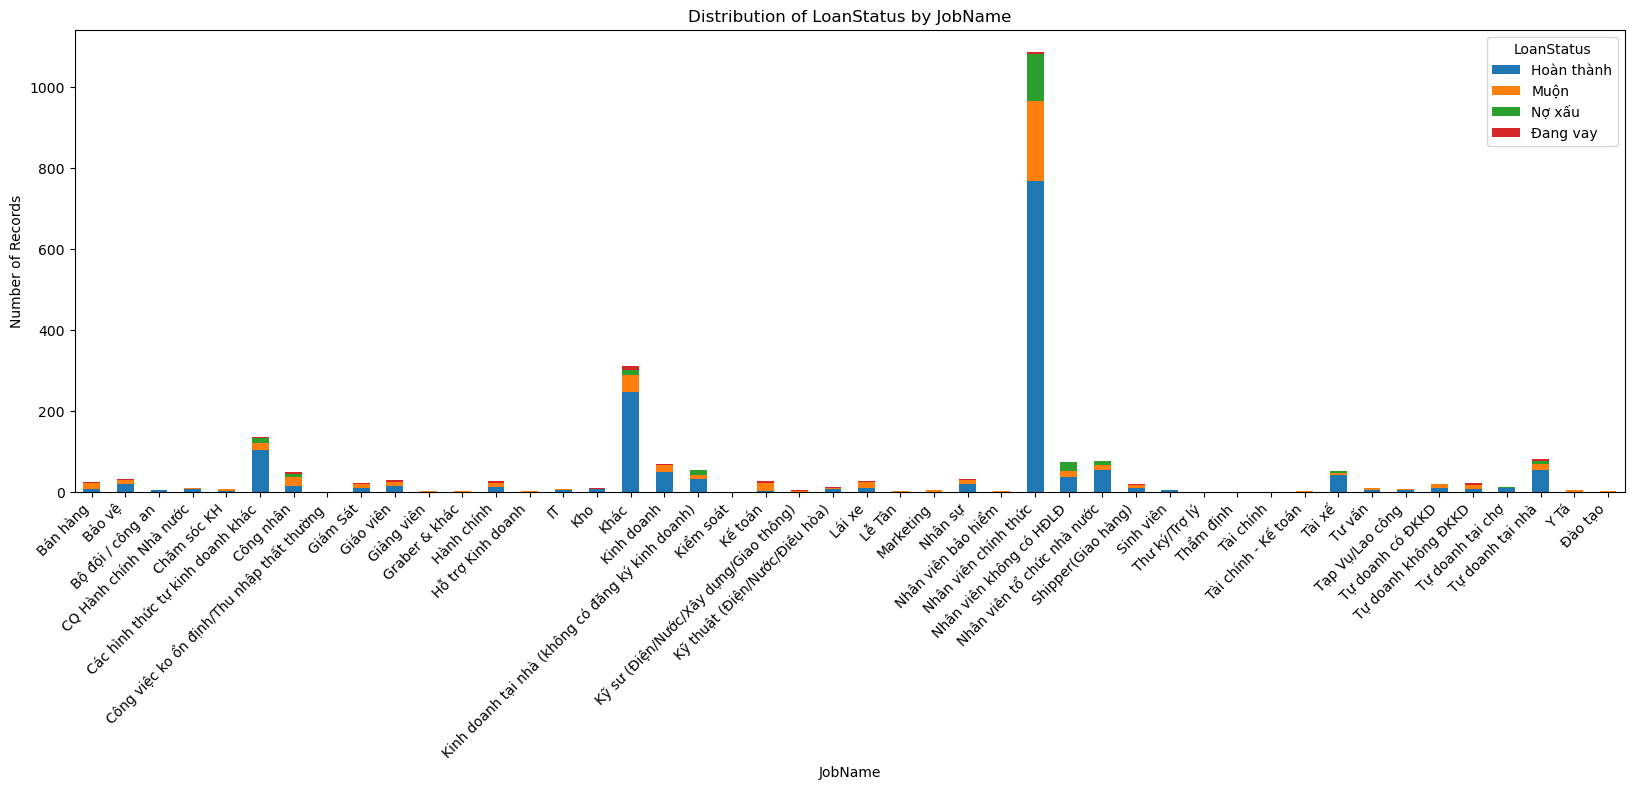

In [82]:
#Stacked bar chart – LoanStatus by JobName
top_jobs = df['JobName'].value_counts().index
subset = df[df['JobName'].isin(top_jobs)]

df_crosstab = pd.crosstab(subset['JobName'], subset['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(20,6))
plt.title("Distribution of LoanStatus by JobName")
plt.xlabel("JobName")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha='right')
plt.legend(title="LoanStatus")
plt.show()


In [83]:
#Non-performing loan ratio + Late loan ratio by career
risk_by_job = (
    pd.crosstab(df['JobName'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_job

LoanStatus,Nợ xấu,Muộn
JobName,,
Bán hàng,0.000000,60.000000
Bảo vệ,3.225806,29.032258
Bộ đội / công an,0.000000,0.000000
CQ Hành chính Nhà nước,0.000000,22.222222
Chăm sóc KH,0.000000,42.857143
Các hình thức tự kinh doanh khác,9.629630,13.333333
Công nhân,12.244898,48.979592
Công việc ko ổn định/Thu nhập thất thường,0.000000,100.000000
Giám Sát,0.000000,47.619048


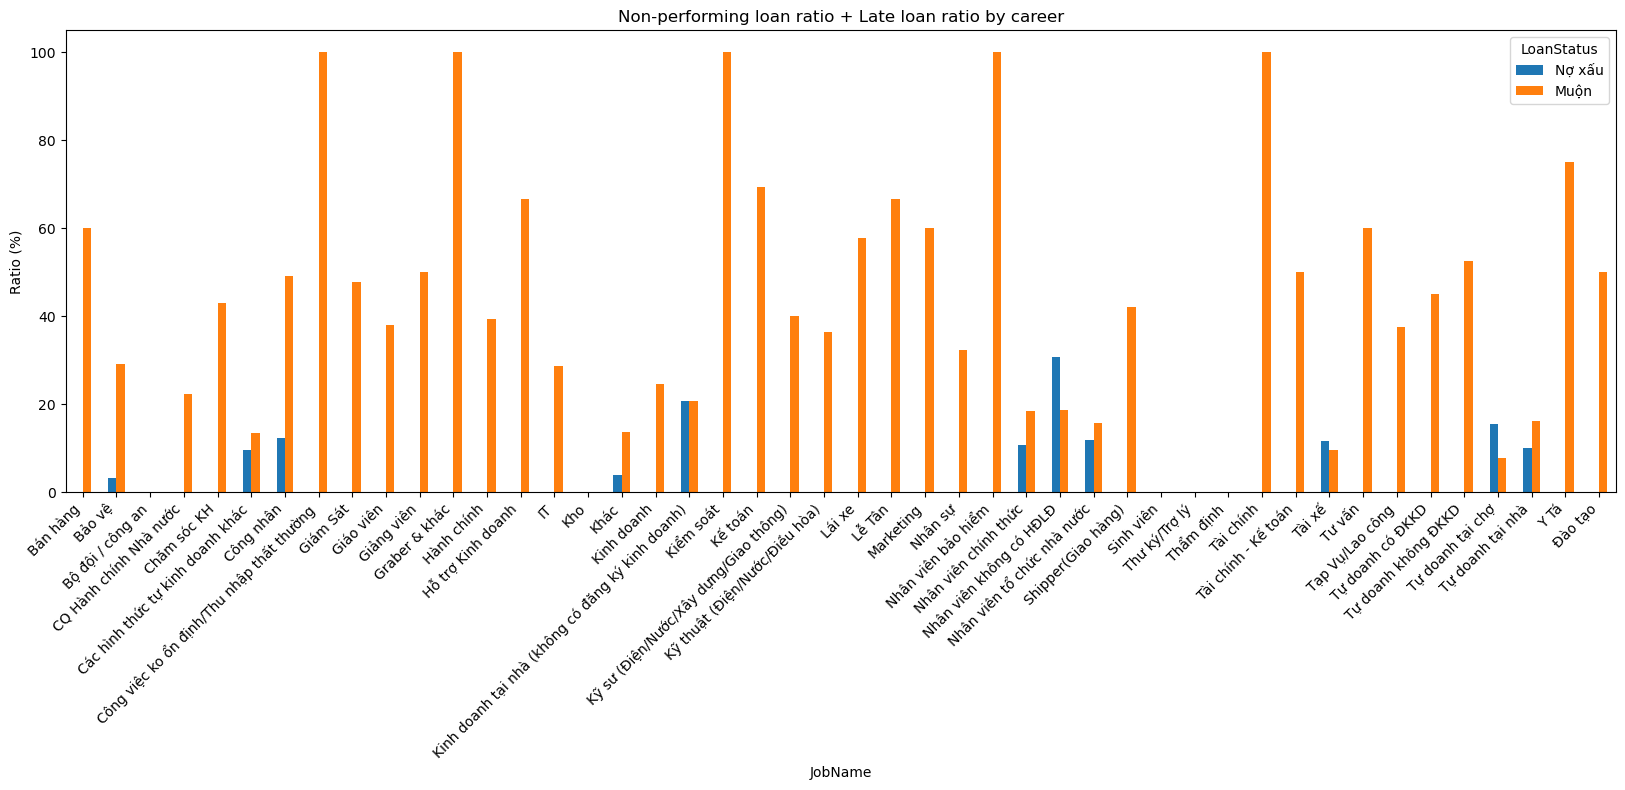

In [84]:
#Stacked bar chart – Non-performing loan ratio + Late loan ratio by career
risk_by_job[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(20,6))
plt.title("Non-performing loan ratio + Late loan ratio by career")
plt.xlabel("JobName")
plt.ylabel("Ratio (%)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="LoanStatus")
plt.show()

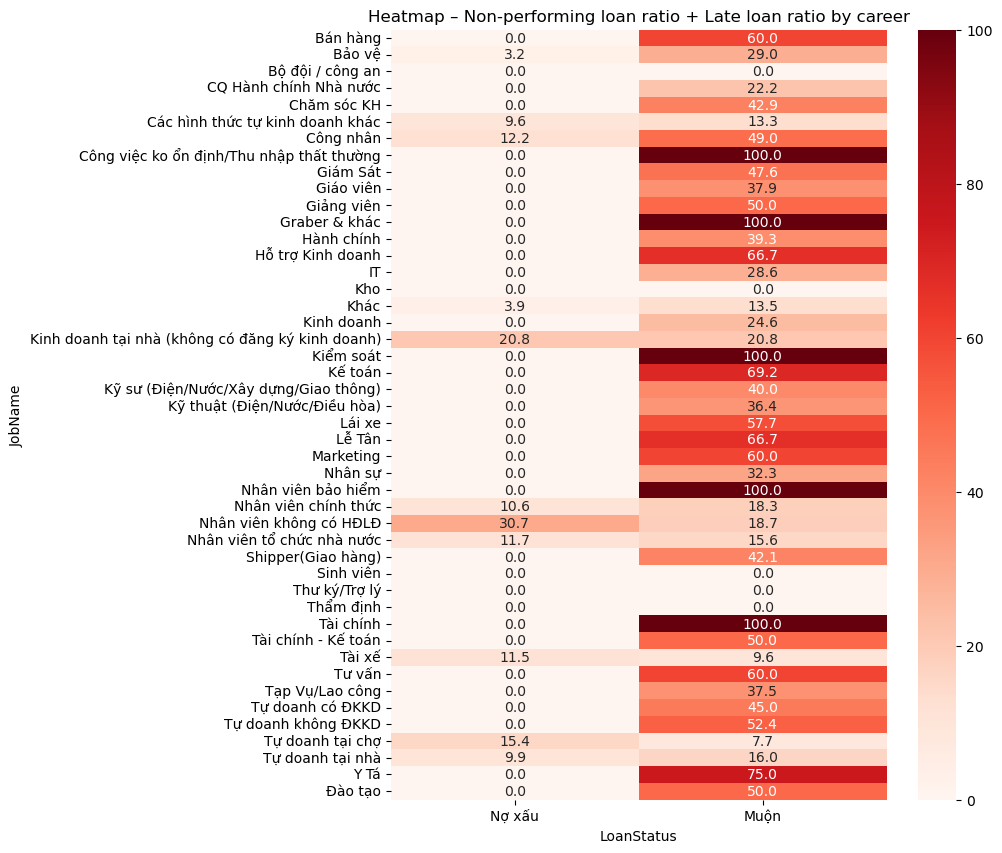

In [85]:
#Heatmap – Risks by JobName (Bad & Late Debt)
plt.figure(figsize=(8,10))
sns.heatmap(
    risk_by_job,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)
plt.title("Heatmap – Non-performing loan ratio + Late loan ratio by career")
plt.show()


**Insight**

1. Occupations with high "Delay" rates are concentrated in the unstable income group.

Some occupations have very high "Delay" rates (many over 50%, even 100%), mainly falling into the following groups:

Unstable jobs / irregular income

Freelancers, small business owners, delivery drivers, Grab drivers, salespeople, security guards, receptionists…

This indicates that these occupational groups are prone to late payments, likely due to irregular income or heavy reliance on short-term cash flow.

2. Many occupations with high "Delay" rates do not have accompanying bad debt.

Most occupations with high "Delay" rates have a bad debt rate of 0% or very low.

This shows that:

Customers are late in paying but still tend to pay in full, not yet becoming bad debt.

The main risk here is the pressure of recovery and cash flow management, rather than capital loss.

3. Bad Debt Only Prominently Appears in Certain Occupations

Some occupations have a noticeable rate of bad debt, although they don't account for a large number of cases, for example:

Factory Workers

Home-Based Businesses (without business registration)

Employees Without Employment Contracts

Self-employed (some groups)

These groups have both unstable incomes and lack legal binding agreements, so the risk of transitioning from Delayed to Bad Debt is higher.

4. Stable Occupations Have Lower Risk and More Even Distribution

Occupational Groups Such as:

Full-time Employees

Accountants, Administrators, Technicians, Teachers, Human Resources

Share the following characteristics:

Low Bad Debt Rate

Average Delay Rate

Large Distribution of Cases → More Reliable Conclusion

These occupations show that stable income helps reduce risk, although it doesn't completely eliminate the possibility of late payments.

5. Caution is needed for occupations with very few records but extreme rates.

Some occupations have:

Very few records (under 10)

Late or Bad Debt Rate = 100%

→ Do not immediately conclude high risk, as this rate is easily distorted due to the very small sample size.

These groups should only be considered as warning signs; more data is needed for confirmation.

6. Summary

Occupation is clearly related to risk, but it is not the only determining factor.

Occupations with unstable income → High late rates.

Bad debt is only truly prominent in groups that lack both stability and employment ties.

For common, stable occupations → lower risk and easier to manage.

**LoanStatus vs ResidenceType**

1. Do different residential groups have different LoanStatus distributions?

2. Which residential group has the highest (most stable) "On Time" rate?

3. Which residential group tends to have more Late?

4. Which residential group has the highest rate of Non-Performing Loans?

5. Which residential group has the highest rate of Late?

In [86]:
pd.crosstab(df['Hình thức cư trú'], df['LoanStatus'])


LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
Hình thức cư trú,,,,
Khác,127,12,3,0
Nhà sở hữu,26,32,0,4
Sở hữu cá nhân,396,93,34,9
Sở hữu nhà nước,7,0,1,0
Thuê,282,195,60,32
Thuộc sở hữu của họ hàng,231,68,54,5
Đồng sở hữu,517,125,54,16


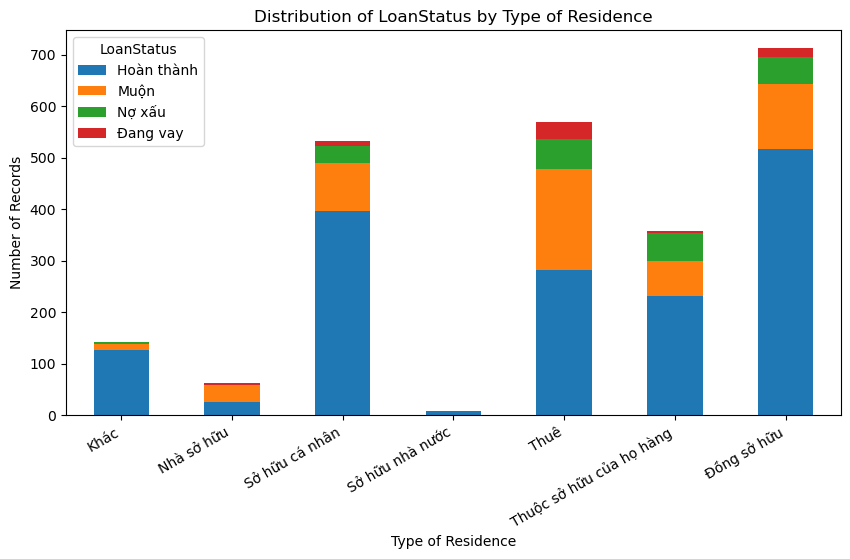

In [87]:
#Stacked bar chart – LoanStatus by Type of Residence
df_crosstab = pd.crosstab(df['Hình thức cư trú'], df['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title("Distribution of LoanStatus by Type of Residence")
plt.xlabel("Type of Residence")
plt.ylabel("Number of Records")
plt.xticks(rotation=30, ha='right')
plt.legend(title="LoanStatus")
plt.show()

In [88]:
#Calculate the Non-Performing Loan + Late Payment Rate by Residence Type
risk_by_res = (
    pd.crosstab(df['Hình thức cư trú'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_res


LoanStatus,Nợ xấu,Muộn
Hình thức cư trú,,
Khác,2.112676,8.450704
Nhà sở hữu,0.000000,51.612903
Sở hữu cá nhân,6.390977,17.481203
Sở hữu nhà nước,12.500000,0.000000
Thuê,10.544815,34.270650
Thuộc sở hữu của họ hàng,15.083799,18.994413
Đồng sở hữu,7.584270,17.556180


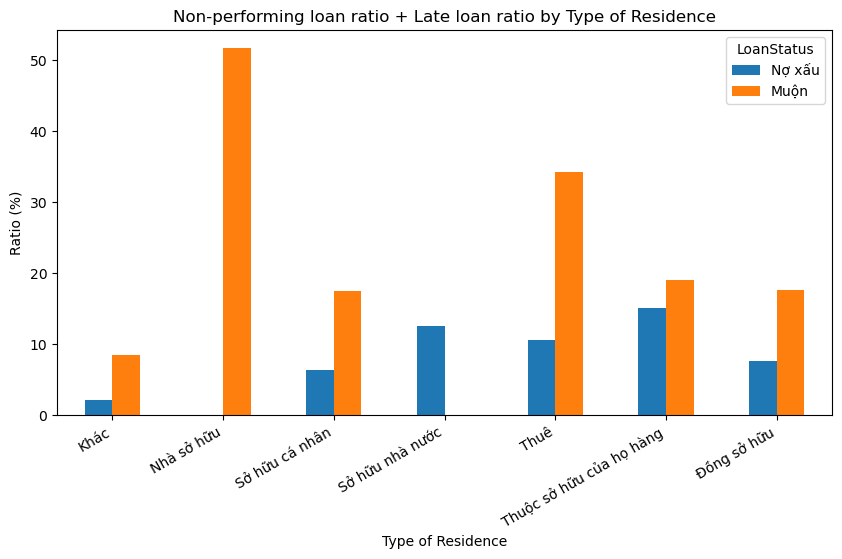

In [89]:
#Stacked bar chart – Risks by Type of Residence
risk_by_res[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(10,5))
plt.title("Non-performing loan ratio + Late loan ratio by Type of Residence")
plt.xlabel("Type of Residence")
plt.ylabel("Ratio (%)")
plt.xticks(rotation=30, ha='right')
plt.legend(title="LoanStatus")
plt.show()

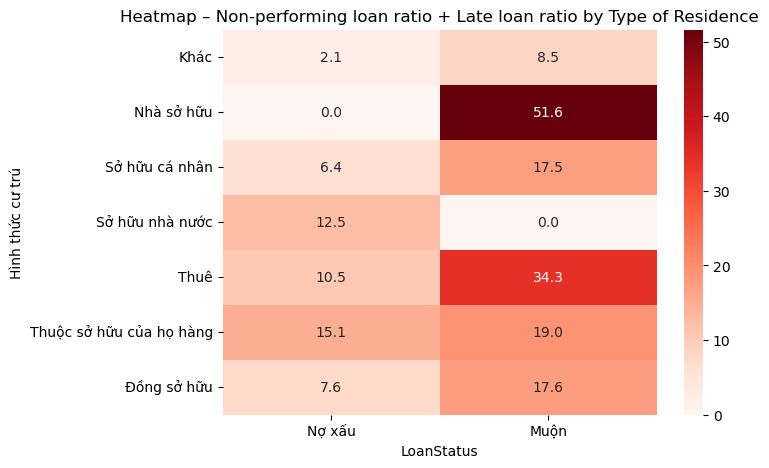

In [90]:
#Heatmap – to compare risks by type of residence
plt.figure(figsize=(7,5))
sns.heatmap(
    risk_by_res,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)
plt.title("Heatmap – Non-performing loan ratio + Late loan ratio by Type of Residence")
plt.show()

**Insight**

Analysis by residency type reveals significant differences in repayment behavior, particularly in the "Delay" rate among groups.

The Homeowner group has the highest Delay rate (~51.6%), despite not recording any bad debt. This suggests that even with their own homes, customers tend to delay payments, possibly due to financial pressure or poor budget allocation.

The Renter group has a relatively high risk, with a Delay rate of ~34.3% and a Bad Debt rate of ~10.5%. This group shows clearer risk compared to the homeowner group, reflecting lower levels of housing and financial stability.

The Household-Owned group stands out in both aspects, with the highest Bad Debt rate (~15.1%) and a Delay rate of ~19%. This group needs close monitoring as it carries both the risk of late payments and the potential for developing bad debt.

The Individual and Co-Owned group has a medium risk level, with a Delay Rate of approximately 17–18% and Non-Performing Loans below 8%, indicating relative stability.

The State-Owned group has a Non-Performing Loan rate of approximately 12.5% ​​but no Delay Rates; however, the number of cases is very small, so a definitive conclusion cannot be drawn, and caution is needed in interpretation.

The Other group has low Delay Rates and Non-Performing Loans, but due to its unclear nature and small number, it is possible that this group "combines" many different cases, and the classification method needs to be reconsidered.

Overall, the form of residence significantly influences debt repayment behavior, but the impact is mainly reflected in late payments rather than non-performing loans. Groups with lower levels of residence stability (renting, household-owned) generally carry higher risks and should be prioritized for monitoring during the appraisal process.

#**Risk Variables vs LoanStatus**

**TS_CREDIT_SCORE_V2 vs LoanStatus**

1. Does a low credit score lead to a bad Loan Status?

2. Does a lower score increase the rate of "Late" and "Bad Debt"?

3. Which credit score segment accounts for the most applications?

4. Does a score < 600 (Low) have the highest rate of Bad Debt?

5. Does a score of 600–700 (Medium) have a higher rate of Late than Bad Debt?

6. Is a score >= 800 (Excellent) almost safe?

7. Are there any risk ranges? (e.g., 560–620)

In [91]:
pd.crosstab(df['CreditScoreGroup'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
CreditScoreGroup,,,,
Excellent,6,0,0,1
Good,188,63,3,9
Low (High Risk),797,224,161,22
Medium,595,238,42,34


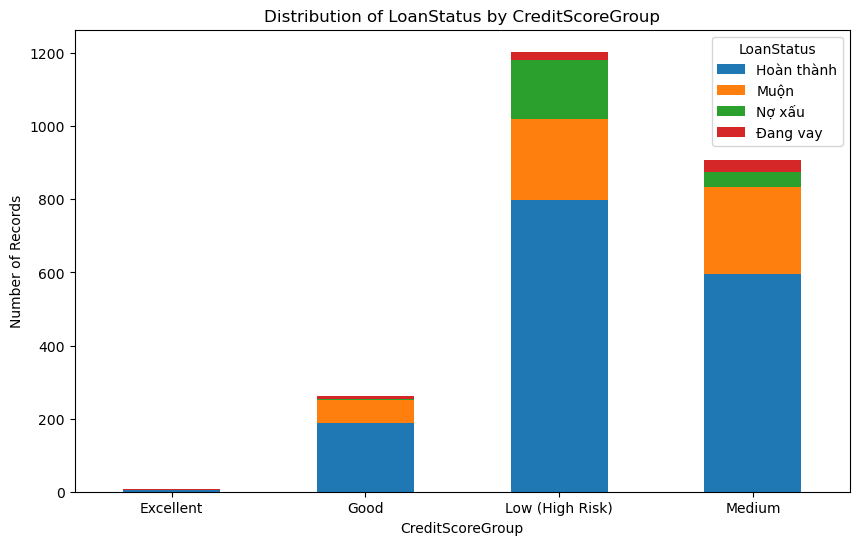

In [92]:
#Stacked bar chart – LoanStatus according to CreditScoreGroup
df_crosstab = pd.crosstab(df['CreditScoreGroup'], df['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Distribution of LoanStatus by CreditScoreGroup")
plt.xlabel("CreditScoreGroup")
plt.ylabel("Number of Records")
plt.legend(title="LoanStatus")
plt.xticks(rotation=0)
plt.show()

In [93]:
#Calculate the Non-Performing Loan + Late Loan Rate by CreditScoreGroup
risk_by_score = (
    pd.crosstab(df['CreditScoreGroup'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_score

LoanStatus,Nợ xấu,Muộn
CreditScoreGroup,,
Excellent,0.000000,0.000000
Good,1.140684,23.954373
Low (High Risk),13.372093,18.604651
Medium,4.620462,26.182618


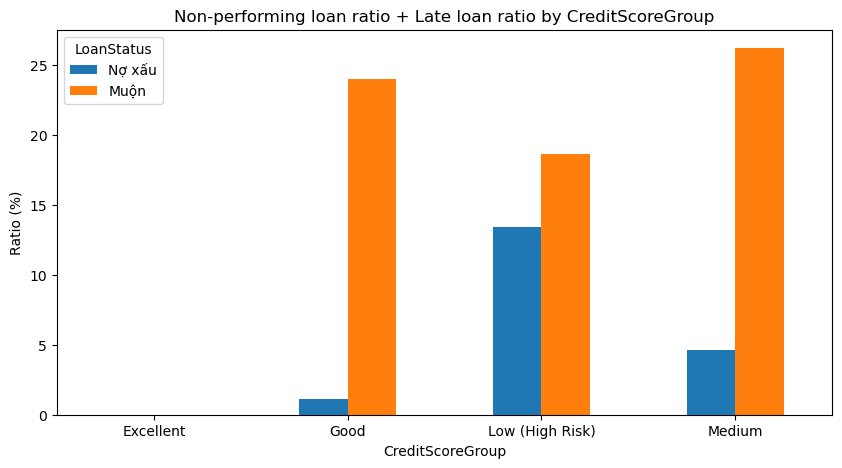

In [94]:
#Bar chart – Non-performing loan ratio + Late loan ratio by CreditScoreGroup
risk_by_score[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(10,5))
plt.title("Non-performing loan ratio + Late loan ratio by CreditScoreGroup")
plt.xlabel("CreditScoreGroup")
plt.ylabel("Ratio (%)")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

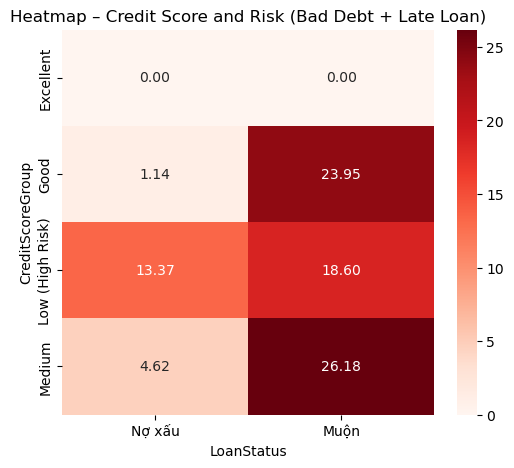

In [95]:
#Heatmap – Credit Score and Risk (Bad Debt + Late Loan)
plt.figure(figsize=(6,5))
sns.heatmap(
    risk_by_score,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)
plt.title("Heatmap – Credit Score and Risk (Bad Debt + Late Loan)")
plt.show()

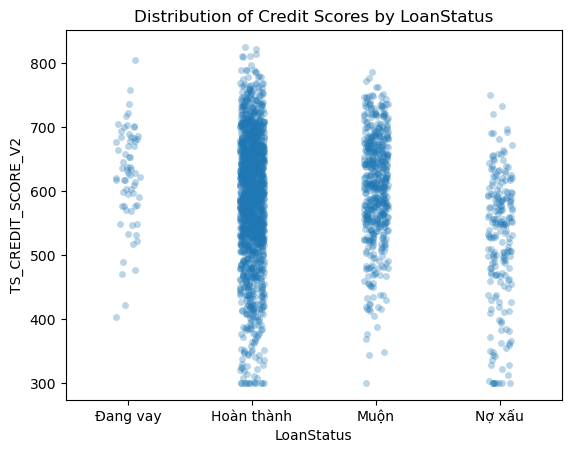

In [96]:
#Scatter plot – TS_CREDIT_SCORE_V2 vs LoanStatus --> Shows low scores concentrated in Non-performing/Late Loans.
sns.stripplot(
    data=df,
    x='LoanStatus',
    y='TS_CREDIT_SCORE_V2',
    alpha=0.3
)
plt.title("Distribution of Credit Scores by LoanStatus")
plt.show()

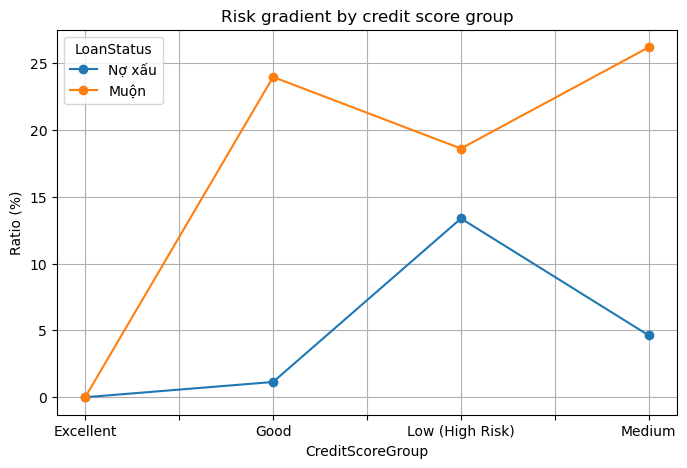

In [97]:
#Line chart – Risk gradient by credit score group
risk_by_score[['Nợ xấu', 'Muộn']].plot(kind='line', marker='o', figsize=(8,5))
plt.title("Risk gradient by credit score group")
plt.xlabel("CreditScoreGroup")
plt.ylabel("Ratio (%)")
plt.grid(True)
plt.show()

**Insight**

Analysis shows that credit score (TS_CREDIT_SCORE_V2) has a clear correlation with loan status, especially with bad debt. As the credit score decreases, the risk increases significantly.

The Low (High Risk) group is the highest risk segment:

It accounts for the largest number of applications.

It has the highest bad debt ratio (~13.4%).

It also has a relatively high lateness rate (~18.6%).

→ This group requires the strictest control during the approval process and post-disbursement monitoring.

The Medium group (600–700):

It has an average bad debt ratio (~4.6%), much lower than the Low group.

However, it has the highest lateness rate among all groups (~26.2%).

→ This indicates that the Medium group tends to have more late payments but hasn't yet turned into bad debt, meaning the risk is more about late payments than default.

Good Group (700–800):

Very low bad debt ratio (~1.1%).

Later payments are still significant (~24%).

→ Overall credit quality is good, but late payment behavior is still common, showing that a good credit score doesn't automatically mean on-time payments.

Excellent Group (≥800):

Almost no bad debt and no late payments.

The number of cases is small but shows a very high level of safety.

→ Suitable for prioritizing preferential policies (low interest rates, pre-approved).

Overall:

The risk of bad debt decreases significantly as the credit score increases.

However, the risk of late payments does not decrease uniformly across the score, remaining particularly high in the Medium and Good groups.

This indicates the need to clearly distinguish between the risk of late payments and the risk of default, rather than lumping them together in a single measure.

Therefore:

Credit score is a very strong variable for predicting bad debt.

For the Medium and Good groups, focus should be placed on managing late payment behavior (reminders, flexible payment schedules) rather than tightening approval processes.

The Low group requires control from the outset (credit limits, loan conditions).

The Excellent group can be leveraged to optimize revenue with low risk.

**HasBadDebt vs LoanStatus**

1. How does the LoanStatus differ between groups 0 and 1?

2. Do groups with a poor CIC (HasBadDebt=1) tend to have higher rates of late payments/bad debt?

3. Does a HasBadDebt of 1 lead to a significantly higher bad debt ratio?

4. Are there many groups without a poor CIC but still experiencing bad debt?

In [98]:
pd.crosstab(df['HasBadDebt'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
HasBadDebt,,,,
0,1410,489,158,64
1,176,36,48,2


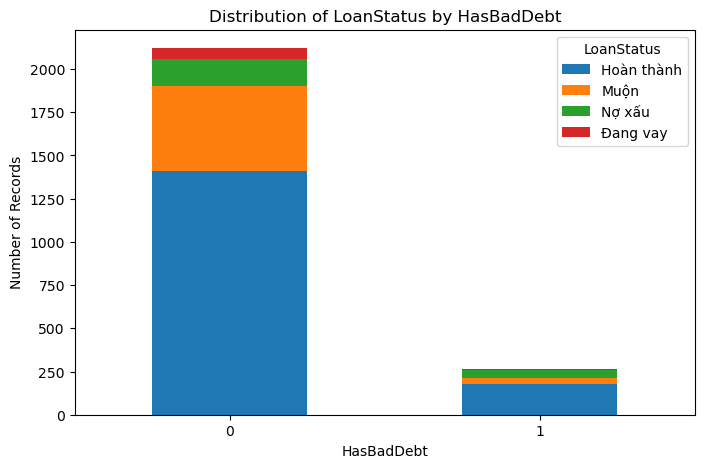

In [99]:
#Stacked bar chart – LoanStatus via HasBadDebt
df_crosstab = pd.crosstab(df['HasBadDebt'], df['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Distribution of LoanStatus by HasBadDebt")
plt.xlabel("HasBadDebt")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

In [100]:
risk_by_baddebt = (
    pd.crosstab(df['HasBadDebt'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_baddebt

LoanStatus,Nợ xấu,Muộn
HasBadDebt,,
0,7.449316,23.055163
1,18.320611,13.740458


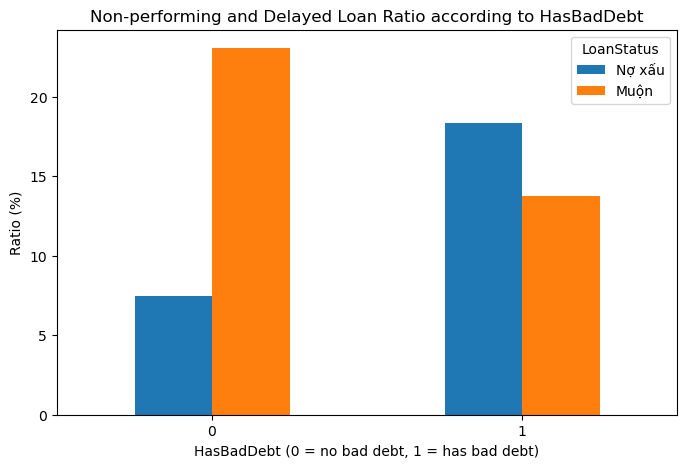

In [101]:
#Bar chart – Non-performing and Delayed Loan Ratio according to HasBadDebt
risk_by_baddebt[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(8,5))
plt.title("Non-performing and Delayed Loan Ratio according to HasBadDebt")
plt.xlabel("HasBadDebt (0 = no bad debt, 1 = has bad debt)")
plt.ylabel("Ratio (%)")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

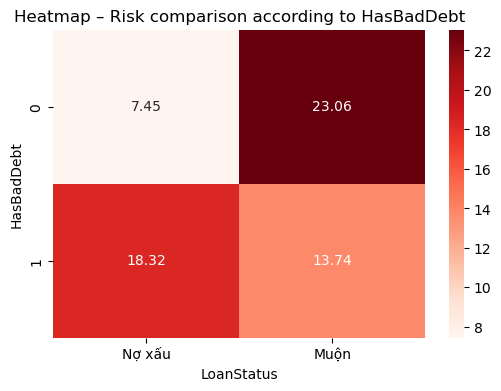

In [102]:
#Heatmap – Risk comparison according to HasBadDebt
plt.figure(figsize=(6,4))
sns.heatmap(
    risk_by_baddebt,
    annot=True,
    cmap="Reds",
    fmt=".2f"
)
plt.title("Heatmap – Risk comparison according to HasBadDebt")
plt.show()

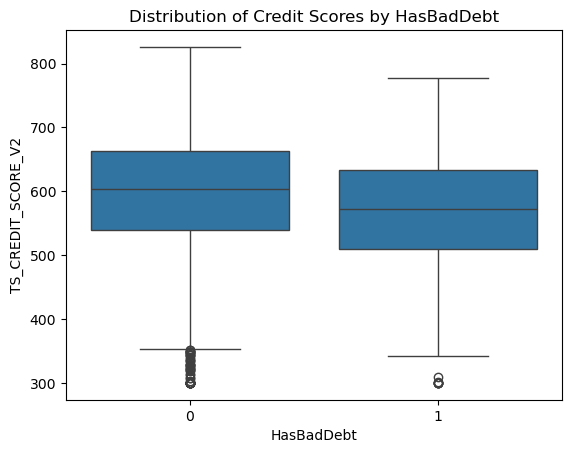

In [103]:
#Credit score distribution according to HasBadDebt --> To check if a bad CIC record is dragging down your score?
sns.boxplot(data=df, x='HasBadDebt', y='TS_CREDIT_SCORE_V2')
plt.title("Distribution of Credit Scores by HasBadDebt")
plt.show()

**Insight**

The results show that HasBadDebt significantly influences LoanStatus, but the level of influence differs between "Late" and "Bad Debt".

The group with no bad CIC (HasBadDebt = 0) accounted for the majority of records in the dataset. However, this group still recorded a relatively high rate of Late payments (~23.1%), while the rate of Bad Debt was low (~7.4%). This indicates that the absence of a bad CIC does not necessarily mean timely repayment behavior, but mainly reflects that the customer has never been in a state of default.

Conversely, the group with a bad CIC (HasBadDebt = 1) showed a significantly higher risk of Bad Debt, with a Bad Debt rate (~18.3%), approximately 2.5 times higher than the group without a bad CIC.

Meanwhile, the Delay rate for this group is lower (~13.7%), indicating that loans from the group with poor CIC tend to quickly transition to Non-Performing Loans instead of just remaining in a late payment state.

Observing the credit score distribution according to HasBadDebt shows that the group with poor CIC has a lower median credit score; however, there is still significant overlap between the two groups. This suggests that while a poor CIC is an important risk indicator, it is not sufficient to completely differentiate credit behavior when considered alone.

In summary, HasBadDebt is a strong predictor of Non-Performing Loan risk, but does not reflect Delay risk well. Therefore, this variable should be combined with factors such as repayment behavior, credit score, and income for a more comprehensive risk assessment, rather than being used independently.

**HasLatePayment vs LoanStatus**

1. Is there a difference in the LoanStatus distribution between the two groups?

2. Does the group with late payments tend to have a higher rate of "Late" or "Bad Debt"?

3. How many times higher is the "Late" rate compared to 0 if HasLatePayment = 1?

4. Does the group with late payments have a significantly higher rate of "Bad Debt"?

5. Why do the group without late payments still have bad debt?

In [104]:
pd.crosstab(df['HasLatePayment'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
HasLatePayment,,,,
0,1368,429,187,63
1,218,96,19,3


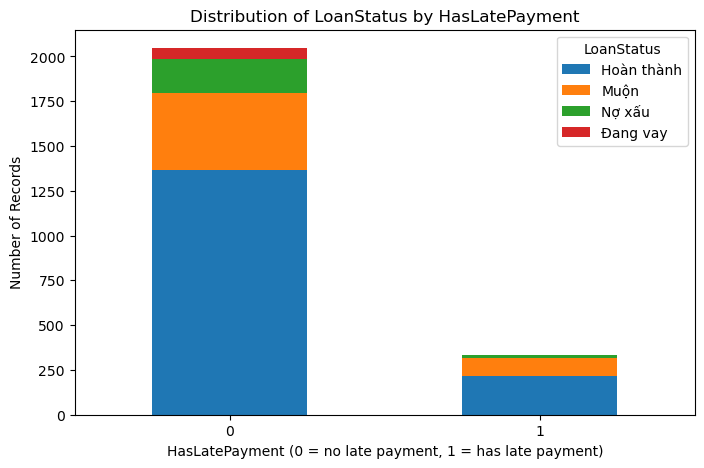

In [105]:
#Stacked bar chart – LoanStatus via HasLatePayment
df_crosstab = pd.crosstab(df['HasLatePayment'], df['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Distribution of LoanStatus by HasLatePayment")
plt.xlabel("HasLatePayment (0 = no late payment, 1 = has late payment)")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

In [106]:
#Non-performing Loan Ratio + Late Payments according to HasLatePayment
risk_by_late = (
    pd.crosstab(df['HasLatePayment'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_late

LoanStatus,Nợ xấu,Muộn
HasLatePayment,,
0,9.135320,20.957499
1,5.654762,28.571429


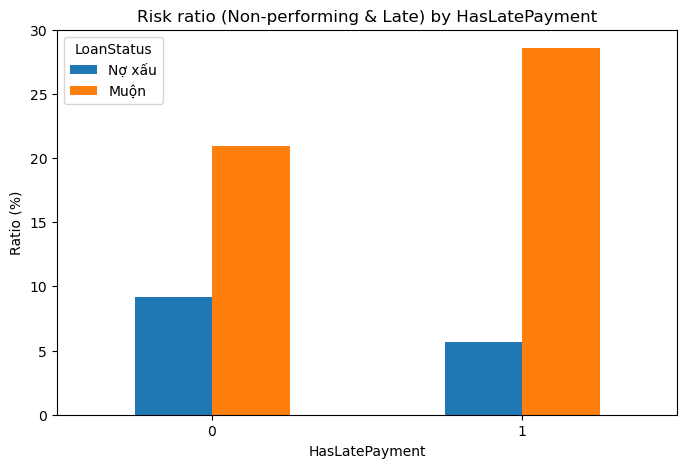

In [107]:
#Bar chart – Risk ratio according to HasLatePayment
risk_by_late[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(8,5))
plt.title("Risk ratio (Non-performing & Late) by HasLatePayment")
plt.xlabel("HasLatePayment")
plt.ylabel("Ratio (%)")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

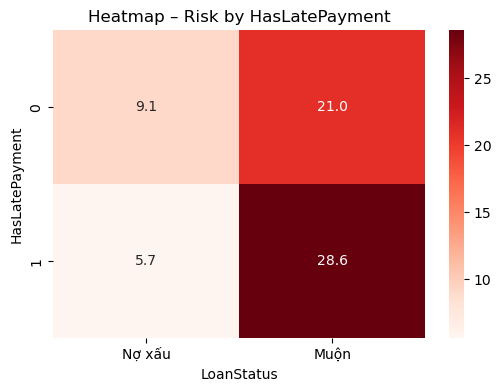

In [108]:
#Heatmap – A clear comparison of the risks of having and not having HasLatePayment
plt.figure(figsize=(6,4))
sns.heatmap(
    risk_by_late,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)
plt.title("Heatmap – Risk by HasLatePayment")
plt.show()

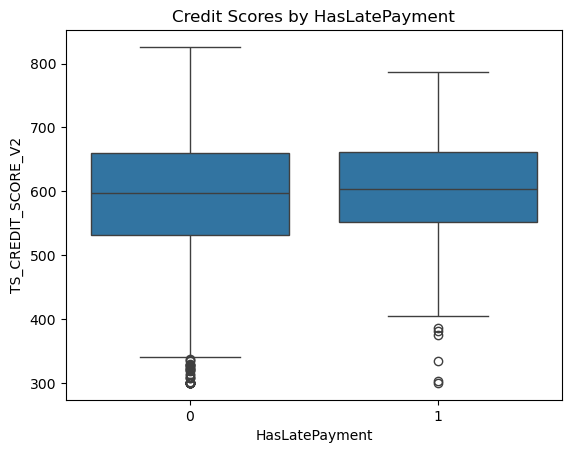

In [109]:
#Scatterplot - Credit score distribution by HasLatePayment --> Check if late payers have lower scores
sns.boxplot(data=df, x='HasLatePayment', y='TS_CREDIT_SCORE_V2')
plt.title("Credit Scores by HasLatePayment")
plt.show()

**Insight**

The analysis results show that a history of late payments (HasLatePayment) is clearly associated with "Late" behavior, but does not directly increase the Non-Performing Loan (NPL) ratio in the current data.

Specifically, the group with late payments (HasLatePayment = 1) recorded a very high NPL ratio (~28.6%), significantly higher than the group without late payments (~21.0%). This confirms that late payments are a strong signal reflecting unstable payment behavior, even if it hasn't immediately transformed into NPL. Conversely, the NPL ratio of the group with late payments (~5.7%) is lower than that of the group without late payments (~9.1%), indicating that having made late payments does not necessarily mean inability to repay.

Observing the credit score distribution shows that the median scores of the two groups are quite similar, with the group with late payments not showing a significantly lower trend. This suggests that the current credit scoring model does not fully reflect the risk of late payments, or that delays in updating the Credit Information Center (CIC) prevent the risk from being recognized as bad debt in a timely manner.

From a risk management perspective, HasLatePayment should be considered an early warning signal, especially for the risk of transitioning from "Late" to "Bad Debt" in the future, rather than just for predicting immediate bad debt. Therefore, this variable is suitable for combination with credit score fluctuations, income, and recent payment history to increase the ability to detect risk early, rather than being used independently in the decision to reject applications.

**3D Multivariate Analysis (Loan Status)**

**LoanStatus vs SalaryGroup vs ProductCreditName**

-> Regarding SalaryGroup:

Which product group (<5M or 5–8M) has the highest rate of bad debt?

Does the 8–12M group have consistently low risk across all products?

Does the 20M+ group still have high-risk products?

- Regarding ProductCreditName:

Which product is high-risk only for the low-income group?

Which product is high-risk across all SalaryGroups?

Which product has the lowest risk for the high-income group?

- Regarding LoanStatus:

Which group has the highest rate of bad debt and late payments?

Are there any segments with excessively high risk that require stricter credit limits or approval conditions?

In [110]:
#Pivot Table – LoanStatus by SalaryGroup & ProductCreditName
pivot_salary_product = pd.crosstab(
    [df['IncomeBracket'], df['ProductCreditName']],
    df['LoanStatus'],
    normalize='index'
) * 100

pivot_salary_product = pivot_salary_product[['Nợ xấu', 'Muộn']]
pivot_salary_product

LoanStatus                               Nợ xấu        Muộn
IncomeBracket ProductCreditName                            
10-15m        Cầm cố xe máy            0.000000   37.500000
              Cầm cố xe máy KCC        6.818182   27.272727
              Cầm cố Điện thoại        4.500000   30.500000
              Cầm cố Điện thoại HK     7.894737    7.894737
              Vay theo sim            26.829268    4.878049
              Đăng ký xe ô tô          0.000000   30.000000
15-25m        Cầm cố xe máy            0.000000   28.205128
              Cầm cố xe máy KCC        0.000000   43.750000
              Cầm cố Điện thoại        6.666667   28.333333
              Cầm cố Điện thoại HK     0.000000   33.333333
              Vay theo sim            22.222222    0.000000
              Ô tô ngân hàng           0.000000    0.000000
              Đăng ký xe ô tô          0.000000    0.000000
5-10m         Cầm Sim Số Đẹp           0.000000  100.000000
              Cầm cố xe máy            0.282486   24.576271
              Cầm cố xe máy KCC        3.529412   27.058824
              Cầm cố Điện thoại        7.887324   24.366197
              Cầm cố Điện thoại HK     5.294118   12.352941
              Cầm ô tô                 0.000000    0.000000
              Vay theo sim            36.238532   10.550459
              Vay trực tuyến qua Sim   0.000000   20.000000
              Ô tô ngân hàng           0.000000   33.333333
              Đăng ký xe ô tô          0.000000   10.526316
<5m           Cầm cố xe máy            0.000000    5.000000
              Cầm cố xe máy KCC        7.692308   23.076923
              Cầm cố Điện thoại       12.500000   14.062500
              Cầm cố Điện thoại HK     0.000000   18.181818
              Vay theo sim            27.586207    3.448276
>=25m         Cầm cố xe máy            0.000000   28.571429
              Cầm cố xe máy KCC        0.000000   50.000000
              Cầm cố Điện thoại        0.000000   33.333333
              Cầm cố Điện thoại HK    14.285714    0.000000
              Unknown                  0.000000    0.000000
              Vay theo sim             0.000000    0.000000
              Ô tô ngân hàng           0.000000   33.333333
              Đăng ký xe ô tô          0.000000   22.222222

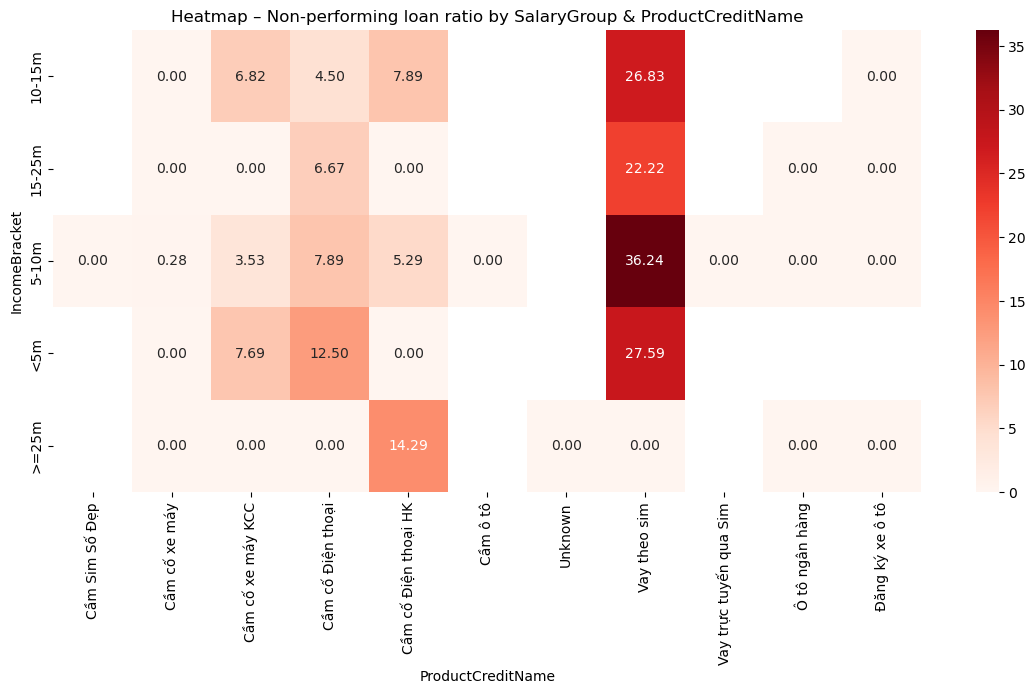

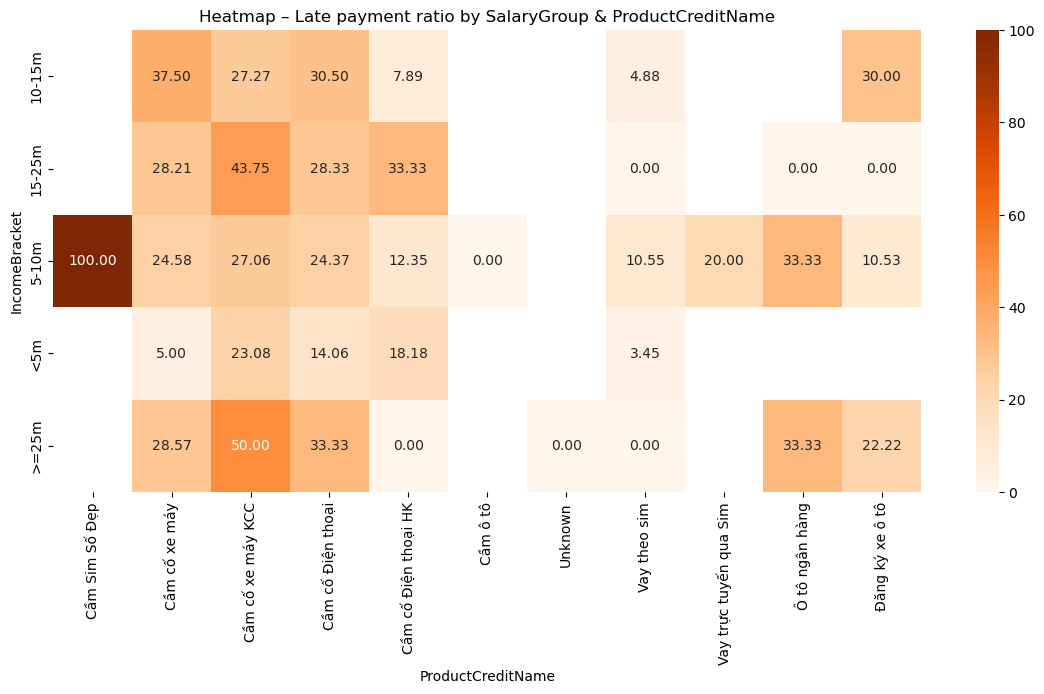

In [111]:
#Heatmap – Analyze by SalaryGroup first (from an income perspective) --> Unstack by ProductCreditName to see which income group is at risk for each product.
#Heatmap – Bad debt by SalaryGroup & ProductCreditName
plt.figure(figsize=(14,6))
sns.heatmap(
    pivot_salary_product['Nợ xấu'].unstack(),
    annot=True,
    fmt=".2f",
    cmap="Reds"
)
plt.title("Heatmap – Non-performing loan ratio by SalaryGroup & ProductCreditName")
plt.xlabel("ProductCreditName")
plt.ylabel("IncomeBracket")
plt.show()

#Heatmap – Late payments by SalaryGroup & ProductCreditName
plt.figure(figsize=(14,6))
sns.heatmap(
    pivot_salary_product['Muộn'].unstack(),
    annot=True,
    fmt=".2f",
    cmap="Oranges"
)
plt.title("Heatmap – Late payment ratio by SalaryGroup & ProductCreditName")
plt.xlabel("ProductCreditName")
plt.ylabel("IncomeBracket")
plt.show()

**CreditScoreGroup vs HasBadDebt vs LoanStatus**

--> Analyze the relationship between credit score segmentation, poor CIC history, and current loan status.

1. Which group has the highest risk of bad debt?

2. How high is the risk of bad debt for a low score (<600) + HasBadDebt = 1?

3. Are the 600-700 group significantly affected by a bad CIC?

4. Are the high-scoring group (800+) affected by a bad CIC?

5. Is CreditScoreGroup or HasBadDebt more important in risk stratification?

6. Are there any unusual segments?

- High score but still bad debt

- Low score but still paying off debts

In [112]:
#Pivot Table – 3D Analysis
pivot_score_baddebt = pd.crosstab(
    [df['CreditScoreGroup'], df['HasBadDebt']],
    df['LoanStatus'],
    normalize='index'
) * 100

pivot_score_baddebt = pivot_score_baddebt[['Nợ xấu', 'Muộn']]
pivot_score_baddebt

LoanStatus                      Nợ xấu       Muộn
CreditScoreGroup HasBadDebt                      
Excellent        0            0.000000   0.000000
Good             0            0.796813  25.099602
                 1            8.333333   0.000000
Low (High Risk)  0           12.319538  19.249278
                 1           20.000000  14.545455
Medium           0            3.398058  27.427184
                 1           16.470588  14.117647

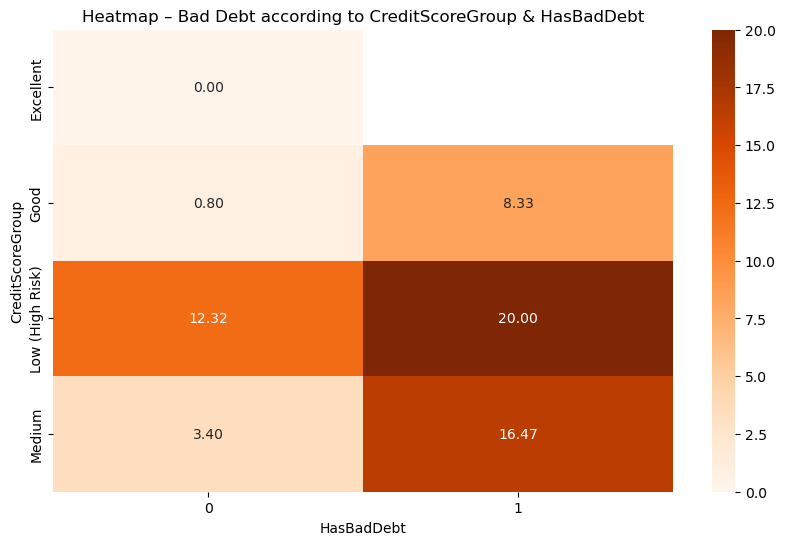

In [113]:
#Heatmap – Bad Debt according to CreditScoreGroup & HasBadDebt
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_score_baddebt['Nợ xấu'].unstack(),
    annot=True,
    fmt=".2f",
    cmap="Oranges"
)
plt.title("Heatmap – Bad Debt according to CreditScoreGroup & HasBadDebt")
plt.xlabel("HasBadDebt")
plt.ylabel("CreditScoreGroup")
plt.show()

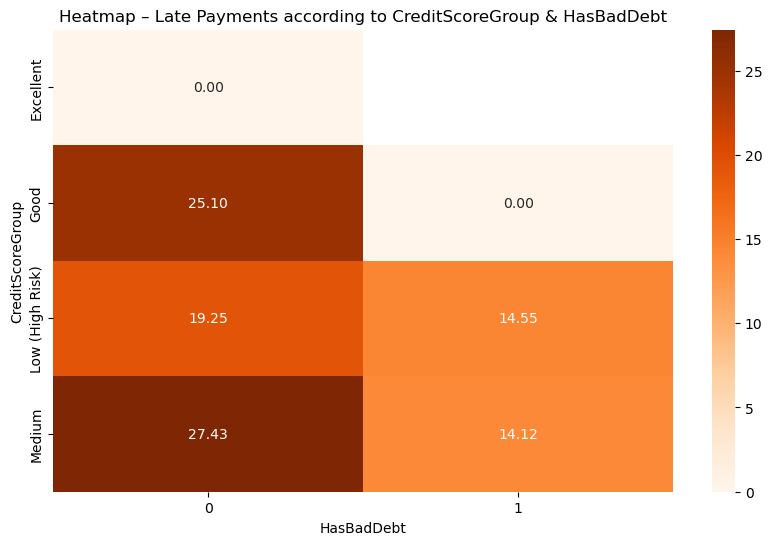

In [114]:
#Heatmap – Late Payments according to CreditScoreGroup & HasBadDebt
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_score_baddebt['Muộn'].unstack(),
    annot=True,
    fmt=".2f",
    cmap="Oranges"
)
plt.title("Heatmap – Late Payments according to CreditScoreGroup & HasBadDebt")
plt.xlabel("HasBadDebt")
plt.ylabel("CreditScoreGroup")
plt.show()

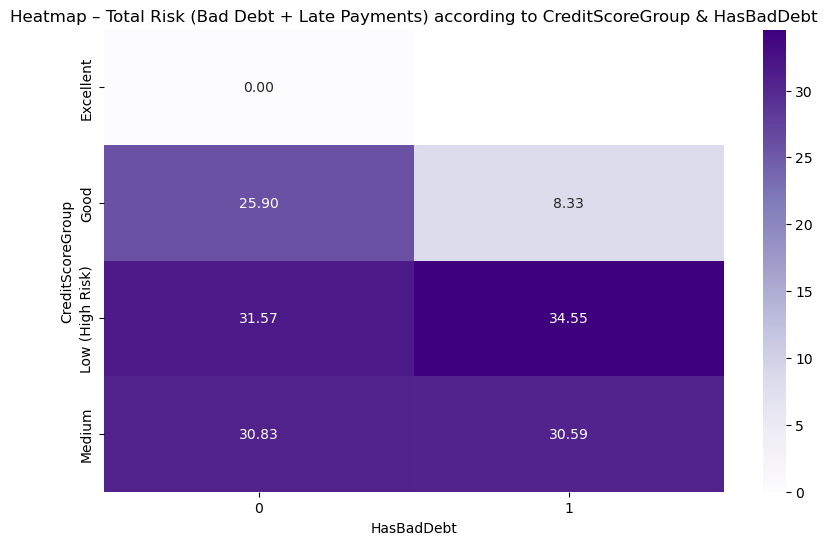

In [115]:
#Heatmap – Total Risk (Bad Debt + Late Payments)
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_score_baddebt.sum(axis=1).unstack(),
    annot=True,
    fmt=".2f",
    cmap="Purples"
)
plt.title("Heatmap – Total Risk (Bad Debt + Late Payments) according to CreditScoreGroup & HasBadDebt")
plt.xlabel("HasBadDebt")
plt.ylabel("CreditScoreGroup")
plt.show()

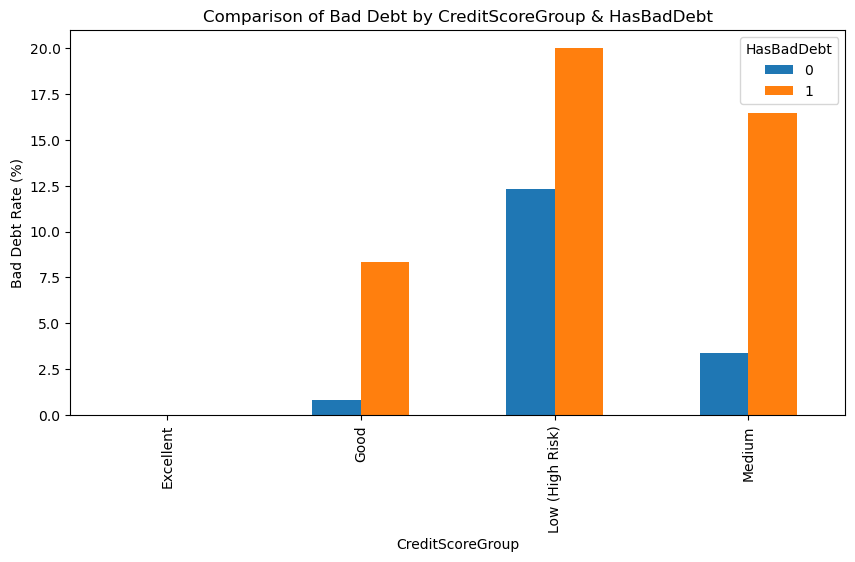

In [116]:
#Barplot – Risk based on HasBadDebt but broken down by CreditScoreGroup
pivot_score_baddebt['Nợ xấu'].unstack().plot(kind='bar', figsize=(10,5))
plt.title("Comparison of Bad Debt by CreditScoreGroup & HasBadDebt")
plt.xlabel("CreditScoreGroup")
plt.ylabel("Bad Debt Rate (%)")
plt.show()

**CreditScoreGroup vs HasLatePayment vs LoanStatus**

--> Combining credit score + CIC late payment history + loan status.

1. Which credit score group is most affected by HasLatePayment?

2. Low score + late payments → high risk of bad debt?

3. Average score but late payments → leaning towards "late"?

4. High score + late payments → customer is considered unusual?

5. Is HasLatePayment or CreditScoreGroup stronger in risk prediction?

6. Are there any extremely high-risk groups → needing consideration for blocking/tightening?

In [117]:
pivot_score_late = pd.crosstab(
    [df['CreditScoreGroup'], df['HasLatePayment']],
    df['LoanStatus'],
    normalize='index'
) * 100

pivot_score_late = pivot_score_late[['Nợ xấu', 'Muộn']]
pivot_score_late

LoanStatus                          Nợ xấu       Muộn
CreditScoreGroup HasLatePayment                      
Excellent        0                0.000000   0.000000
Good             0                0.452489  22.171946
                 1                4.761905  33.333333
Low (High Risk)  0               14.409222  17.867435
                 1                6.748466  23.312883
Medium           0                4.627249  24.935733
                 1                4.580153  33.587786

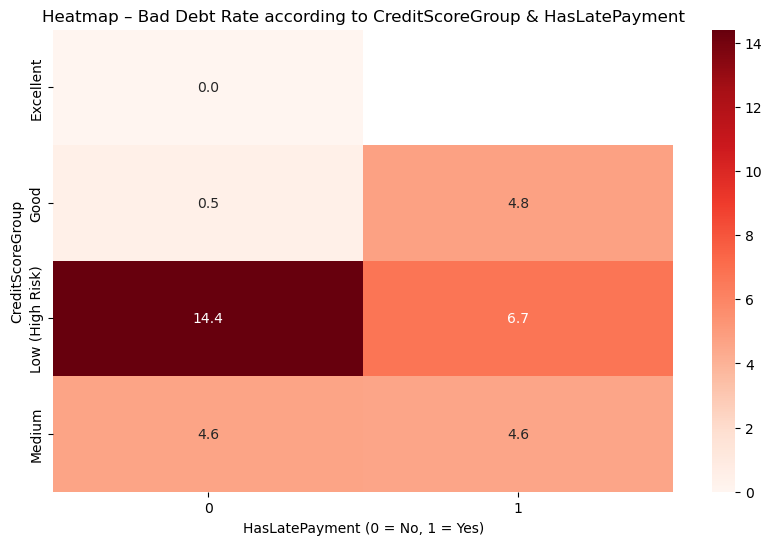

In [118]:
#Heatmap – Bad debt according to CreditScoreGroup vs HasLatePayment
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_score_late['Nợ xấu'].unstack(),
    annot=True,
    fmt=".1f",
    cmap="Reds"
)
plt.title("Heatmap – Bad Debt Rate according to CreditScoreGroup & HasLatePayment")
plt.xlabel("HasLatePayment (0 = No, 1 = Yes)")
plt.ylabel("CreditScoreGroup")
plt.show()

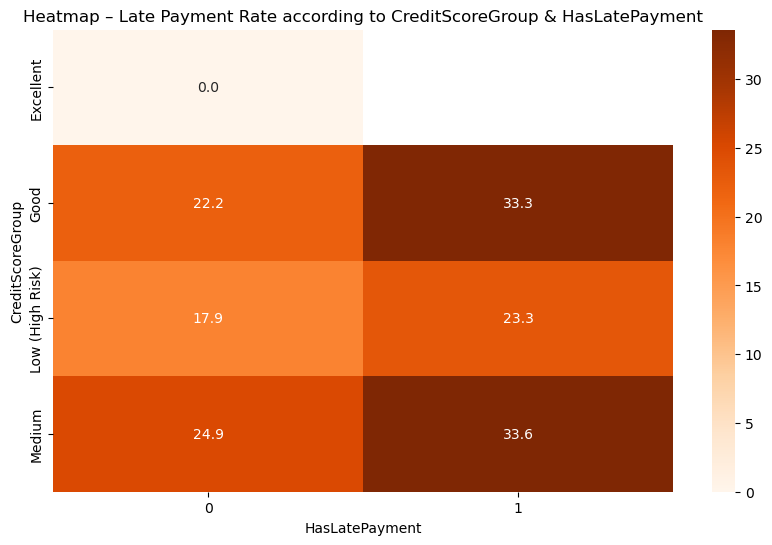

In [119]:
#Heatmap – Late Payments according to CreditScoreGroup vs HasLatePayment
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_score_late['Muộn'].unstack(),
    annot=True,
    fmt=".1f",
    cmap="Oranges"
)
plt.title("Heatmap – Late Payment Rate according to CreditScoreGroup & HasLatePayment")
plt.xlabel("HasLatePayment")
plt.ylabel("CreditScoreGroup")
plt.show()

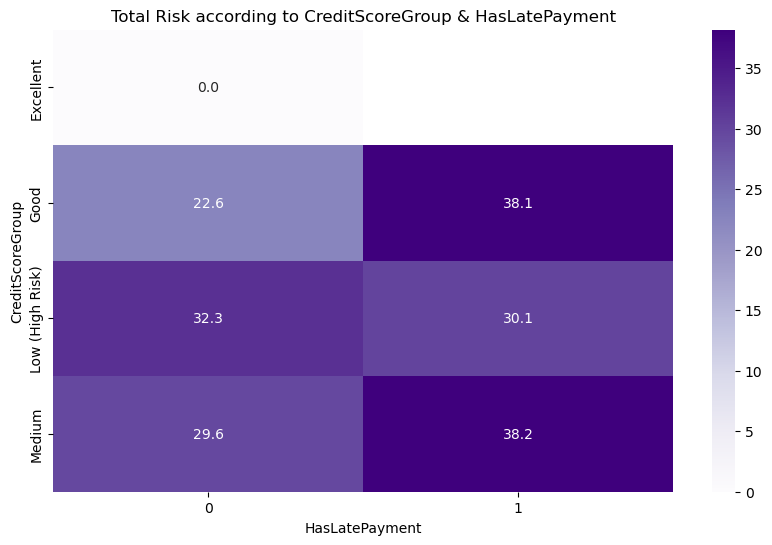

In [120]:
#Total risk (Non-performing loans + Late payments)
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_score_late.sum(axis=1).unstack(),
    annot=True,
    fmt=".1f",
    cmap="Purples"
)
plt.title("Total Risk according to CreditScoreGroup & HasLatePayment")
plt.xlabel("HasLatePayment")
plt.ylabel("CreditScoreGroup")
plt.show()

**Insight**

When combining credit score (CreditScoreGroup), late payment history (HasLatePayment), and current loan status (LoanStatus), we see a very clear and consistent risk stratification model. Credit score acts as the foundation for determining the base risk level, while late payment behavior tends to exacerbate risk, especially in the average (Good) and high-risk (Low) groups. Conversely, the Excellent group is almost unaffected even by late payments.

Specifically, the Low (High Risk) group is always the highest risk segment. Without late payments, this group already has a late rate of nearly 80%, and when late payments occur, this rate increases to nearly 87%. This shows that a low credit score is a fundamental risk factor, and late payments only exacerbate an already high risk. Even in the Low+ category, where there are no late payments, the risk is still higher than all other segments.

For the Good segment, the impact of late payments is most evident. When Good customers do not make late payments, the Late rate is nearly 70%, but if there are late payments, the risk increases sharply to nearly 86% – almost equivalent to the Low segment. This shows that the history of late payments is a more influential variable than credit score in the Good segment. Therefore, this group needs to be assessed more thoroughly based on past repayment behavior, rather than just relying on credit score.

Meanwhile, the Medium segment is more stable. The Late rate fluctuates around 75–80% in both late and non-late payment states, indicating that late payment behavior does not significantly change the risk level of this group. This is a segment with relatively consistent behavior, suitable for conditional approval policies or moderate priority classification.

For the Excellent segment, the risk is almost negligible. The Delay Rate is only around 14% when there are no late payments, and even with late payments, the data still shows a very low risk level. This reflects high credit quality, which helps customers better withstand short-term credit events, making it suitable for prioritizing quick approvals or reducing paperwork requirements.

From the above observations, we can identify several key risk segments. The highest risk is found in the combinations: Low + Late Payments and Good + Late Payments – both groups have Delay Rates above 85%. Meanwhile, Medium + Late Payments have slightly increased but stable risk, while Excellent has very low risk. Notably, there is a "contrasting" phenomenon, such as Good + Late Payments having significantly higher risk than Medium, or Low + No Late Payments still having higher risk than Medium + Late Payments.

Overall, the CreditScoreGroup – HasLatePayment – ​​LoanStatus analysis shows that risk doesn't simply depend on credit score or late payment behavior alone, but rather on a combination of these two factors. Low scores indicate underlying risk, while late payments act as a catalyst amplifying risk, particularly strong in the Good and Low categories. Conversely, the Excellent category is almost immune to late payments, demonstrating the high reliability of this segment.

-- Possible conclusions:

1. For the Low category:

When there are late payments, approval may be discouraged, or conditions may need to be significantly tightened.

Even without late payments, this group still carries high risk.

2. For the Good category:

Late payment history is a crucial indicator.

Prioritizing HasLatePayment control over sales alone is advisable.

3. For the Medium category:

The most stable group → possibly the "sweet spot" in terms of profit-risk.

4. For the Excellent group:

Loans may be granted more easily and with less risk.

**Age vs Gender vs LoanStatus**

--> Analysis of Age – Gender – Loan Status.

Objectives:

To identify which age group has the highest risk.

Which gender has the highest risk within each age group?

To identify specific risk segments:

Young men: high risk?

Older women: many late applications?

Middle-aged men: safest?

--> By age:

1. Which age group has the highest rate of bad debt?

2. Which age group has the most late applications?

3. Do young people (25-35) have a higher risk than middle-aged people (30-45)?

--> By gender:

4. Do men or women have a higher rate of bad debt?

5. Which gender has more late applications?

--> By combined age + gender:

6. Are men under 25 the highest risk group?

7. Do women aged 25–35 have the lowest bad debt?

8. Is the 45–60 age group (both genders) at low risk?

9. Are there any unusual segments?

In [121]:
#Pivot Table – LoanStatus and AgeGroup vs Gender
pivot_age_gender_status = pd.crosstab(
    [df['AgeGroup'], df['Gender']],
    df['LoanStatus'],
    normalize='index'
) * 100

pivot_age_gender_status = pivot_age_gender_status[['Nợ xấu', 'Muộn']]
pivot_age_gender_status

LoanStatus           Nợ xấu       Muộn
AgeGroup Gender                       
18-25    0.0      13.496933  21.165644
         1.0       7.216495  24.226804
26-35    0.0       9.294118  19.647059
         1.0       8.207343  23.326134
36-45    0.0       5.841924  19.587629
         1.0       6.586826  28.742515
46-55    0.0       4.347826  30.434783
         1.0       3.225806  29.032258
56-65    0.0       0.000000  33.333333
         1.0       0.000000  80.000000
Unknown  0.0       0.000000   0.000000
         Unknown   0.000000  25.000000

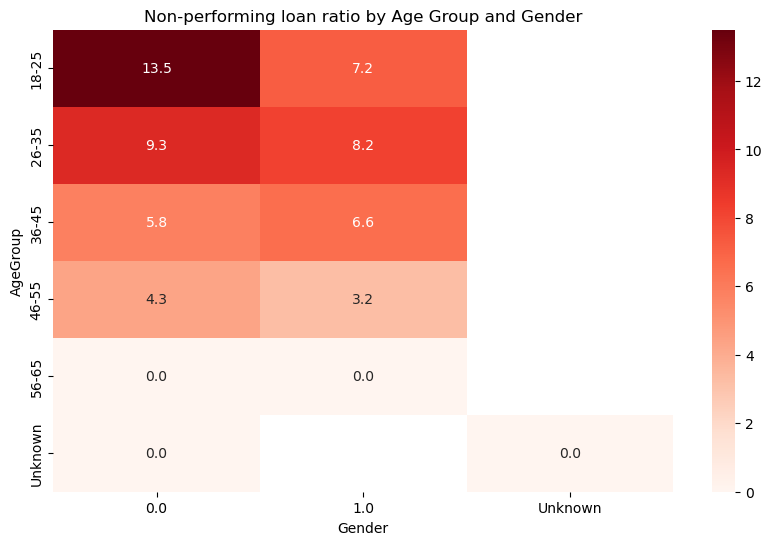

In [122]:
#Heatmap – Bad Debt by AgeGroup vs Gender
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_age_gender_status['Nợ xấu'].unstack(),
    annot=True,
    fmt=".1f",
    cmap="Reds"
)
plt.title("Non-performing loan ratio by Age Group and Gender")
plt.xlabel("Gender")
plt.ylabel("AgeGroup")
plt.show()

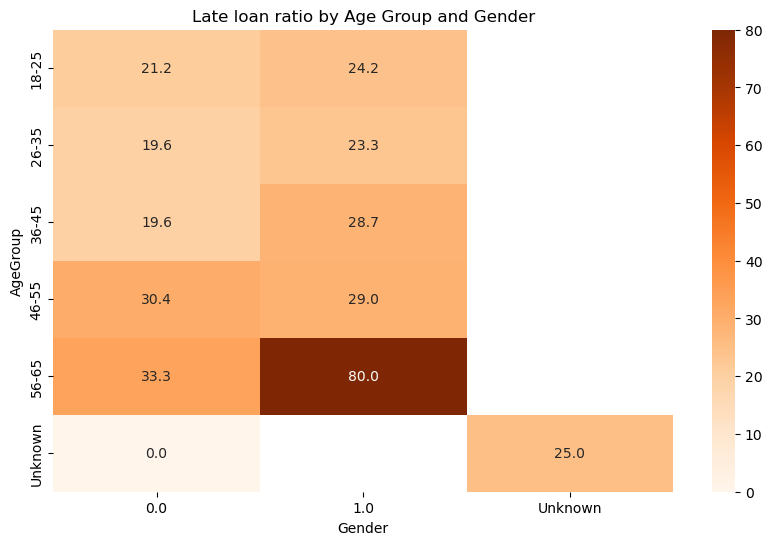

In [123]:
#Heatmap – Late According to Age Group vs Gender
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_age_gender_status['Muộn'].unstack(),
    annot=True,
    fmt=".1f",
    cmap="Oranges"
)
plt.title("Late loan ratio by Age Group and Gender")
plt.xlabel("Gender")
plt.ylabel("AgeGroup")
plt.show()

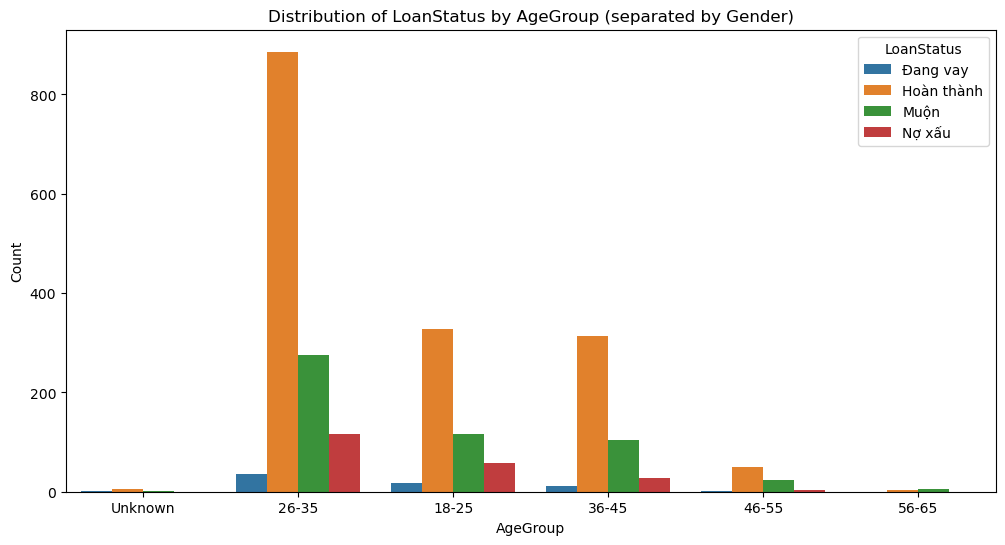

In [124]:
#Bar chart – AgeGroup separated by Gender and LoanStatus
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x='AgeGroup',
    hue='LoanStatus',
    dodge=True
)
plt.title("Distribution of LoanStatus by AgeGroup (separated by Gender)")
plt.ylabel("Count")
plt.xlabel("AgeGroup")
plt.xticks(rotation=0)
plt.show()


##**Salary vs Gender vs LoanStatus**

1. Trong cùng một mức lương, nam hay nữ rủi ro hơn (Nợ xấu / Muộn cao hơn)?

2. Nhóm lương thấp (<10M) có tỷ lệ Nợ xấu & Muộn cao rõ rệt không?

3. Nhóm lương trung bình (10–15M) có phải an toàn ở cả hai giới?

4. Nhóm lương cao (25M+) có gần như không Nợ xấu không?

In [125]:
#Pivot: IncomeBracket vs Gender vs LoanStatus
pivot_salary_gender_status = (
    pd.crosstab(
        [df['IncomeBracket'], df['Gender']],
        df['LoanStatus'],
        normalize='index'
    ) * 100
)

pivot_salary_gender_status = pivot_salary_gender_status[['Nợ xấu', 'Muộn']]
pivot_salary_gender_status

LoanStatus                Nợ xấu       Muộn
IncomeBracket Gender                       
10-15m        0.0       4.929577  26.056338
              1.0       9.302326  28.682171
15-25m        0.0       5.154639  27.835052
              1.0       1.818182  29.090909
5-10m         0.0      10.878244  18.862275
              1.0       6.939502  25.622776
              Unknown   0.000000  25.000000
<5m           0.0      12.844037   9.174312
              1.0      11.956522  16.304348
>=25m         0.0       0.000000  29.629630
              1.0       4.545455  18.181818

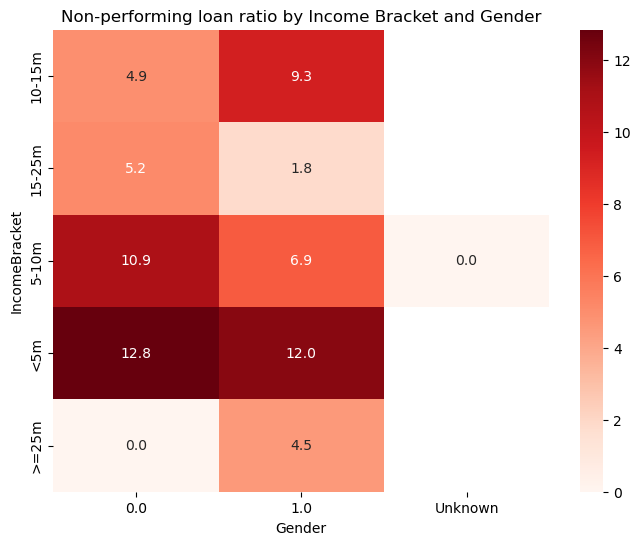

In [126]:
#Heatmap – Non-performing loans by IncomeBracket vs Gender
plt.figure(figsize=(8,6))
sns.heatmap(
    pivot_salary_gender_status['Nợ xấu'].unstack(),
    annot=True,
    fmt=".1f",
    cmap="Reds"
)
plt.title("Non-performing loan ratio by Income Bracket and Gender")
plt.xlabel("Gender")
plt.ylabel("IncomeBracket")
plt.show()

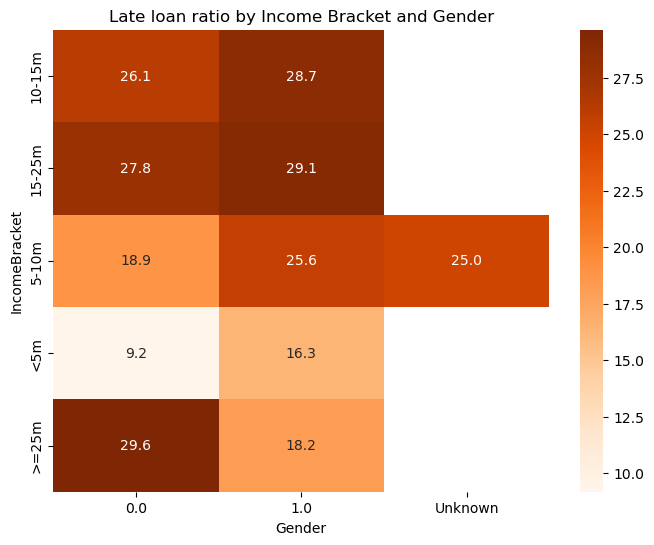

In [127]:
#Heatmap – Late according to IncomeBracket vs Gender
plt.figure(figsize=(8,6))
sns.heatmap(
    pivot_salary_gender_status['Muộn'].unstack(),
    annot=True,
    fmt=".1f",
    cmap="Oranges"
)
plt.title("Late loan ratio by Income Bracket and Gender")
plt.xlabel("Gender")
plt.ylabel("IncomeBracket")
plt.show()

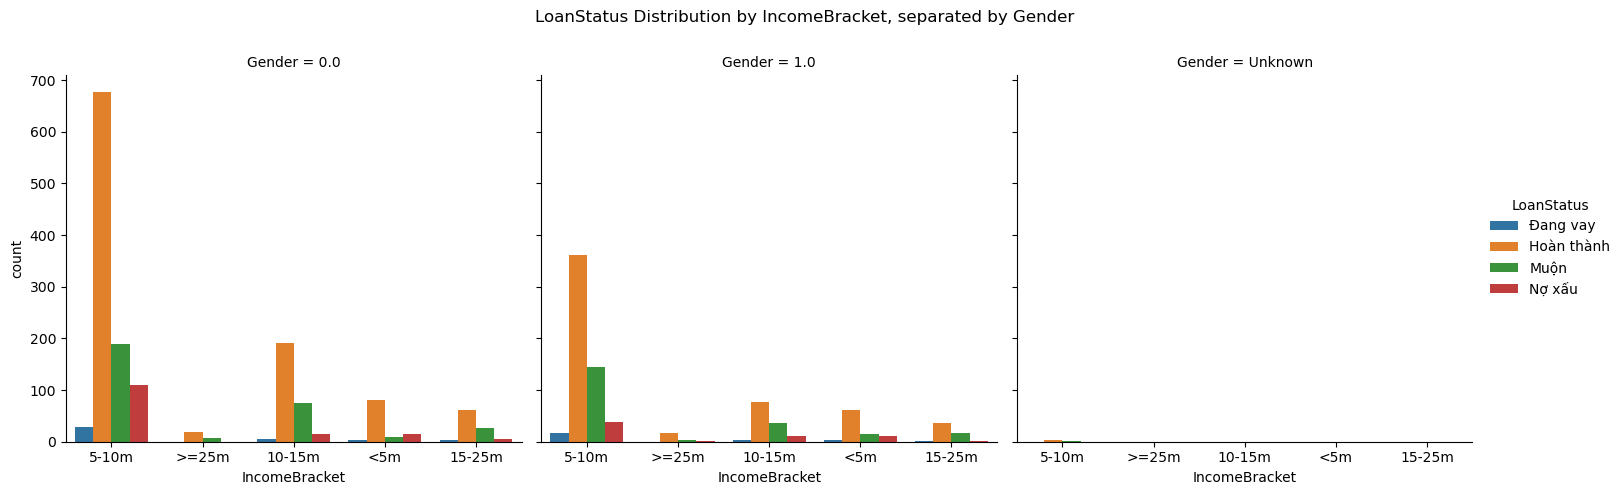

In [128]:
#LoanStatusDistribution by IncomeBracket, separated by Gender
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=df,
    x='IncomeBracket',
    hue='LoanStatus',
    col='Gender',
    kind='count',
    height=5,
    aspect=1
)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("LoanStatus Distribution by IncomeBracket, separated by Gender")
plt.show()

**Age vs Salary vs LoanStatus**


--> By Age:

1. Which age group has the highest rate of bad debt within the same SalaryGroup?

2. Do younger age groups (15-25) have a higher risk?

3. Do those 65+ have a high risk despite high income?

--> By Income:

4. Do low-income groups (<8M) have risk across all age groups?

5. Do those 8–12M have low risk across all age groups?

6. Are those 20M+ affected by age, or are they largely unaffected?

--> Summary:

7. Are there any Age-Salary segments that are too risky and need to be restricted/tightened?

In [129]:
#Pivot Table – LoanStatus and AgeGroup vs SalaryGroup
pivot_age_salary_status = (
    pd.crosstab(
        [df['AgeGroup'], df['IncomeBracket']],
        df['LoanStatus'],
        normalize='index'
    ) * 100
)

pivot_age_salary_status = pivot_age_salary_status[['Nợ xấu', 'Muộn']]
pivot_age_salary_status

LoanStatus                 Nợ xấu        Muộn
AgeGroup IncomeBracket                       
18-25    10-15m          6.382979   36.170213
         15-25m          0.000000   27.272727
         5-10m          11.734694   22.704082
         <5m            13.432836   10.447761
         >=25m           0.000000    0.000000
26-35    10-15m          6.779661   25.847458
         15-25m          4.000000   29.333333
         5-10m           9.545984   19.790454
         <5m            13.675214   12.820513
         >=25m           0.000000   26.923077
36-45    10-15m          5.309735   23.008850
         15-25m          5.172414   22.413793
         5-10m           7.086614   23.228346
         <5m             0.000000   18.750000
         >=25m           5.882353   23.529412
46-55    10-15m          5.882353   41.176471
         15-25m          0.000000   57.142857
         5-10m           4.000000   22.000000
         <5m             0.000000    0.000000
         >=25m           0.000000   50.000000
56-65    15-25m          0.000000  100.000000
         5-10m           0.000000   57.142857
Unknown  5-10m           0.000000   16.666667
         >=25m           0.000000    0.000000

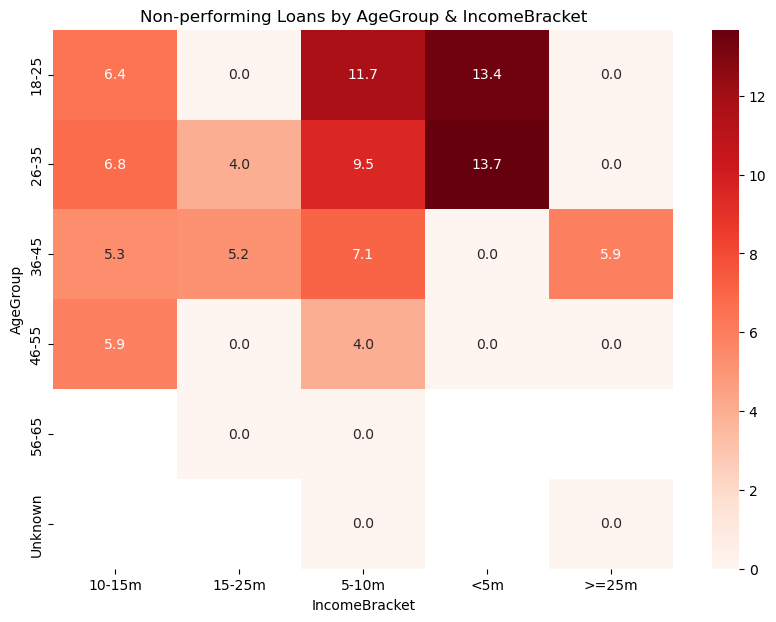

In [130]:
#Heatmap – Non-performing loans according to AgeGroup vs SalaryGroup
plt.figure(figsize=(10,7))
sns.heatmap(
    pivot_age_salary_status['Nợ xấu'].unstack(),
    annot=True,
    fmt=".1f",
    cmap="Reds"
)
plt.title("Non-performing Loans by AgeGroup & IncomeBracket")
plt.xlabel("IncomeBracket")
plt.ylabel("AgeGroup")
plt.show()

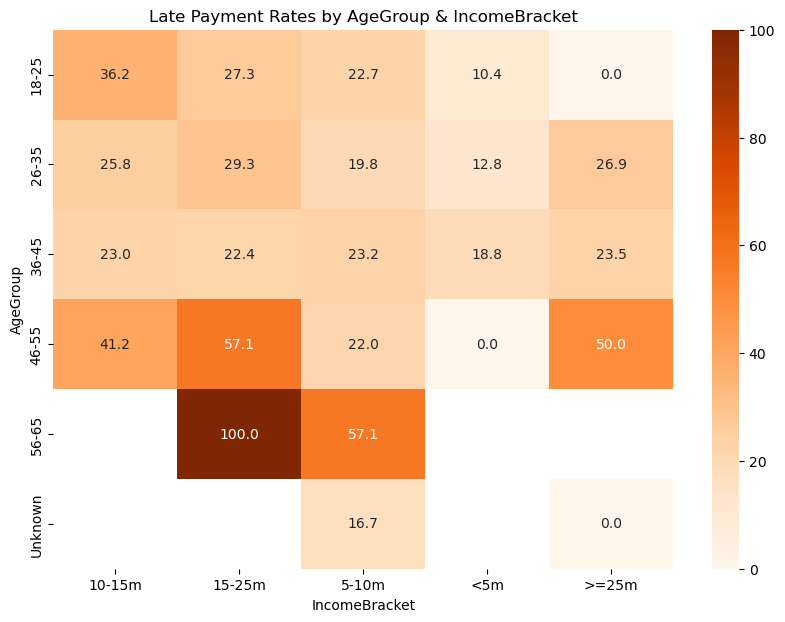

In [131]:
#Heatmap – Late by AgeGroup vs SalaryGroup
plt.figure(figsize=(10,7))
sns.heatmap(
    pivot_age_salary_status['Muộn'].unstack(),
    annot=True,
    fmt=".1f",
    cmap="Oranges"
)
plt.title("Late Payment Rates by AgeGroup & IncomeBracket")
plt.xlabel("IncomeBracket")
plt.ylabel("AgeGroup")
plt.show()

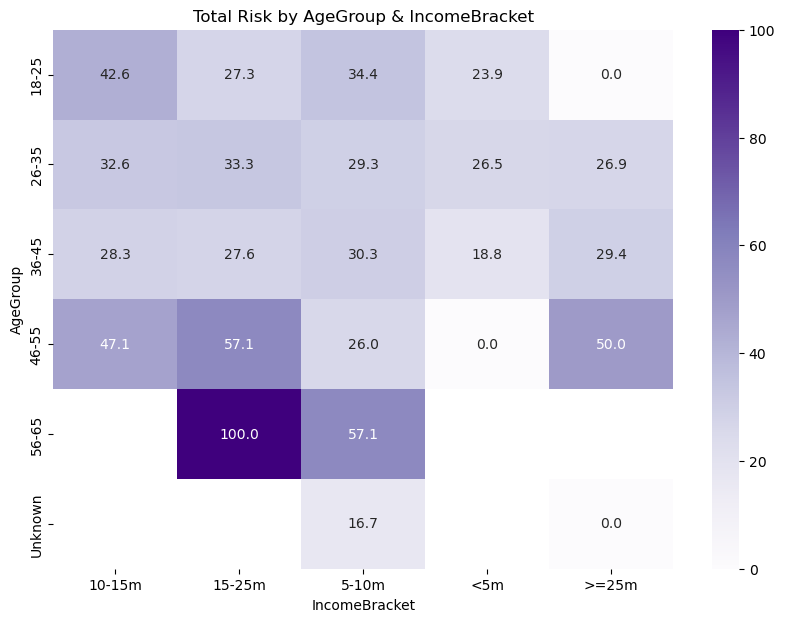

In [132]:
#Total risk (Non-performing loans + Late payments)
plt.figure(figsize=(10,7))
sns.heatmap(
    pivot_age_salary_status.sum(axis=1).unstack(),
    annot=True,
    fmt=".1f",
    cmap="Purples"
)
plt.title("Total Risk by AgeGroup & IncomeBracket")
plt.xlabel("IncomeBracket")
plt.ylabel("AgeGroup")
plt.show()

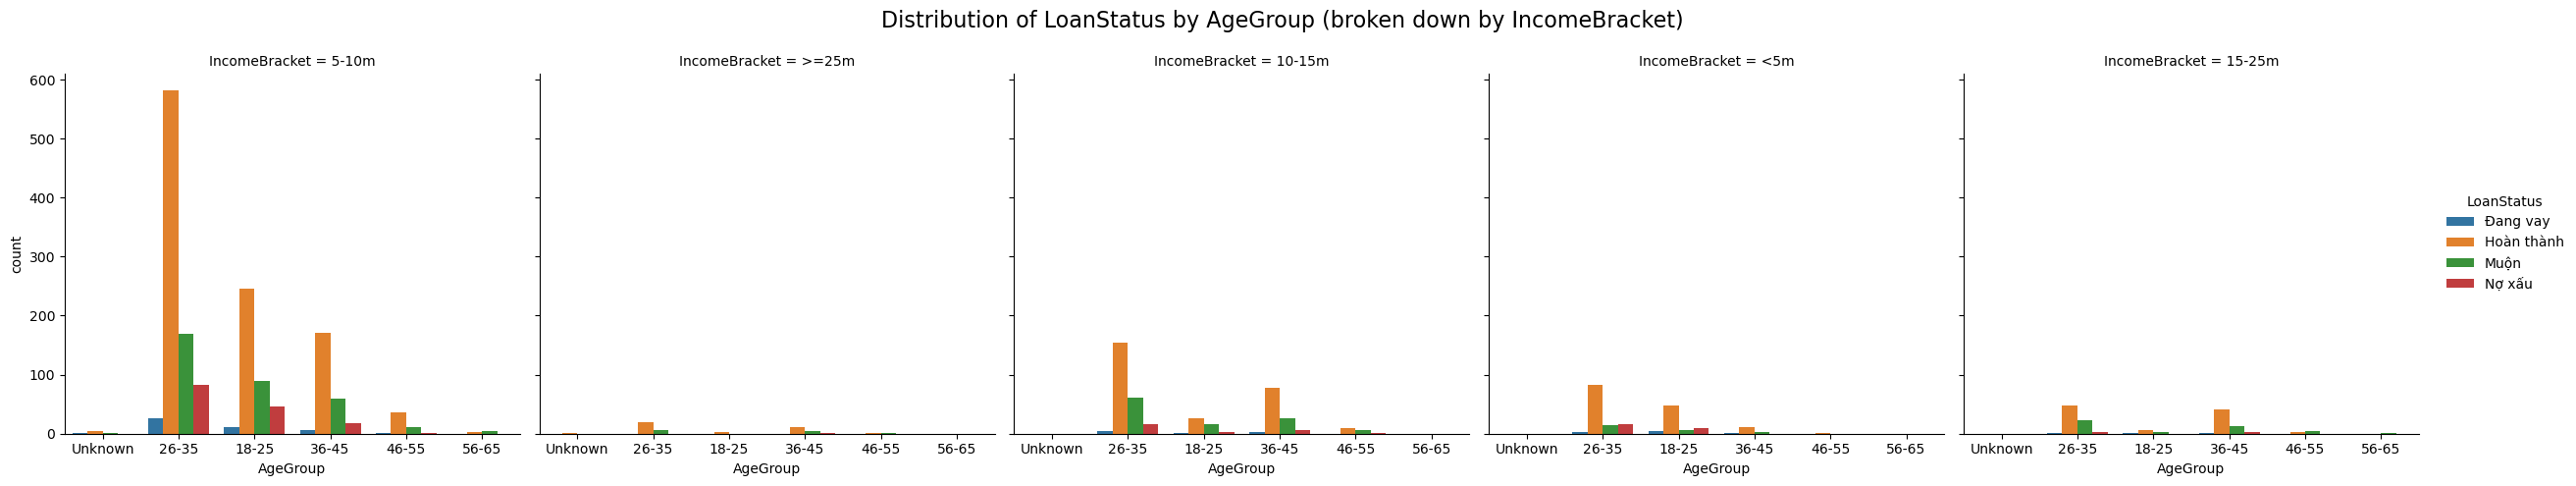

In [133]:
#Distribution Chart – LoanStatus broken down by AgeGroup vs IncomeBracket
sns.catplot(
    data=df,
    x='AgeGroup',
    hue='LoanStatus',
    col='IncomeBracket',
    kind='count',
    height=5,
    aspect=1
)
plt.subplots_adjust(top=0.85)
plt.suptitle("Distribution of LoanStatus by AgeGroup (broken down by IncomeBracket)", fontsize=16)
plt.show()

#**Insight tổng hợp và phân tích chẩn đoán Nguyên nhân Gây ra Nợ xấu (Risk Driver Analysis)**



**Overall INSIGHT (Storytelling)**

TIMA's credit risk analysis reveals that bad debt is not a random phenomenon, but rather the result of an interplay of multiple factors: customer financial capacity, payment behavior, demographic characteristics, and the nature of each credit product. Examining each data point reveals a consistent story: bad debt often originates from groups with weak financial capacity, low credit scores, or those using products with structural risks, with late payments acting as a precursor to the formation of bad debt.

First, analysis by loan product type shows a strong differentiation between product lines. Products in the "quick loan - small asset" category, such as phone pawning and SIM card loans, recorded very high late payment rates and the largest absolute amount of bad debt. This indicates that the product itself carries high risk, as the customer base using these products often has urgent borrowing needs, lacks the ability to prove income, or does not own valuable assets. Conversely, products with substantial collateral, such as motorcycle loans, car registrations, and bank-backed vehicles, demonstrate very good repayment quality, with almost no bad debts. This contrast reveals an important conclusion: risk lies not only with the customer but also in the product structure.

Analysis by geographical area shows that risk is concentrated mainly in Hanoi and Ho Chi Minh City—the two largest markets, where the late payment rate is high but the bad debt rate is low. The high late payment rate reflects significant debt recovery pressure, while the low bad debt rate raises a crucial question: is this truly good credit quality, or merely the result of flexible recovery measures, debt deferral, and term restructuring? In smaller provinces, while the number of loan applications is low, the rate of late payments is much higher, indicating less stable operational risk and debt recovery.

Regarding age groups, younger groups (18–25 and 26–35) represent the greatest risk: high late payment rates and the occurrence of bad debt despite often high incomes. This suggests behavioral risk plays a significant role, as younger groups tend to lack financial stability, have undisciplined spending habits, or borrow from multiple sources. Conversely, middle-aged groups (36–55) are noticeably more stable, with almost no bad debt regardless of income level. This reflects the "financial maturity" of middle-aged customers.

When considering income, the risk pattern becomes very clear: low income is a decisive factor, especially below 5 million VND. This is the only group that experiences both high late payments and high bad debt rates. The middle-income group (10–25 million VND) is the safest, while the high-income group (≥25 million VND), although free of bad debt, still experiences significant late payments, indicating the continued risk of behavioral issues.

Regarding occupations, those with erratic incomes (self-employed, delivery drivers, small home-based businesses, manual laborers) have very high late payment rates, while those in administrative/office jobs, technical fields, and teaching are much more stable. This suggests that stable monthly income is a crucial "shield" for debt repayment ability.

In terms of credit score, this is the strongest risk stratification variable in the entire dataset. The low-scoring group has a significantly higher rate of late payments and bad debt, while the Excellent group is almost completely safe. However, interestingly, the Medium and Good groups still have surprisingly high late payment rates, suggesting a need to reconsider the scoring method or add late payment behavior to the internal scoring scale.

A history of poor credit history (HasBadDebt) isn't always a strong differentiating factor, but in some segments—especially the Good credit score group—a bad CIC significantly increases risk. Meanwhile, has late payment proves to be the strongest risk predictor after credit score: across all score groups, simply having late payments significantly increases the late rate, particularly in the Good and Low groups. This suggests that actual repayment behavior is just as important as credit score.

When analyzing the three-dimensional risk, the highest risk combinations become very clear:

- Low score + Late payments

- Good score + Late payments

- Low income + High-risk products

- Young men + Low income

- The 26-35 age group + under 5 million VND (the most risky hotspot)

Conversely, the safest segments are always:

- Excellent score

- Income 10-25 million VND

- Age 36-55

- Products with strong collateral

The sum of all analysis results shows that bad debt is not random, but the result of 3 risk levels:

Level 1 (Financial capacity): low income, unstable occupation

Level 2 (Behavior): late payments, low credit score, poor CIC

Level 3 (Products): structurally risky products (phones, SIM cards, etc.)

**KẾT LUẬN: Những yếu tố ảnh hưởng mạnh nhất gây ra Nợ xấu**

***1. Low Credit Score (High Risk) --> The Strongest Factor***

Credit score is the clearest risk stratification factor:

The low-score group is the only group that records bad debt and has a very high delinquency rate.

This shows that credit score not only reflects credit history, but also reflects the overall financial quality and spending behavior of the customer.

Mechanism of influence:

Low credit score --> unstable income / multiple debts --> easy to default --> easy to be classified as bad debt.

***2. Low Income (<5M and 5–10M) --> Reduced actual repayment capacity***

Low-income customers demonstrate:

- The highest delinquency rate.

- The group with the highest number of bad debts.

The risk is particularly serious in the 18–35 age group.

Mechanism of Impact:
Low income --> lack of cash flow reserves --> any unforeseen event --> disruption of repayment ability --> easily turns into bad debt.

***3. History of Late Payments (HasLatePayment = 1)***

- Late payments do not immediately result in bad debt, but:

- They are a signal that the customer has financial discipline problems.

- In the Good & Low segments, late payments significantly increase risk.

- They are a behavioral variable with early warning value.

Mechanism of Impact:
Previous late payments --> weak financial management ability --> repeat cycle --> prolonged series of late payments --> gradually turns into bad debt.

***4. Loan Product Type – Specifically Phone Pawning & SIM Card Loans → Structural Risk***

Some products have very high inherent risks regardless of age group or income:

- Phone pawning: 70–90% late payment rate, 0.5–0.7% bad debt.

- SIM card loans: unusually high late payment rate, many groups exhibit “hidden” risks.

Mechanism of impact:

Low asset value --> less commitment from customers --> small, short loan amounts --> easily abused for capital turnover --> high-risk behavior --> lower repayment capacity.

***5. Unstable occupation – seasonal/fluctuating income group***

- Occupations such as cleaning, janitorial work, small self-employment, ride-hailing, real estate sales… have:

- Very high late payment rates (80–100%).

- Bad debt appears in some occupations.

Mechanism of impact:
Unstable income --> low reserve fund --> higher risk of default --> increased risk of inability to repay debt when income decreases.

**Risk Variables - Financial Capability**

**TS_CREDIT_SCORE_V2 vs Salary**

1. Does a higher income necessarily mean a higher credit score?

2. Does a lower income lower credit scores?

3. Is there a linear or non-linear relationship?

4. Which salary levels exhibit strong dispersion (highly dispersed scores)?

5. Do low incomes (<10M) have a high concentration of low credit scores?

6. Do high incomes (>25M) have high and stable credit scores?

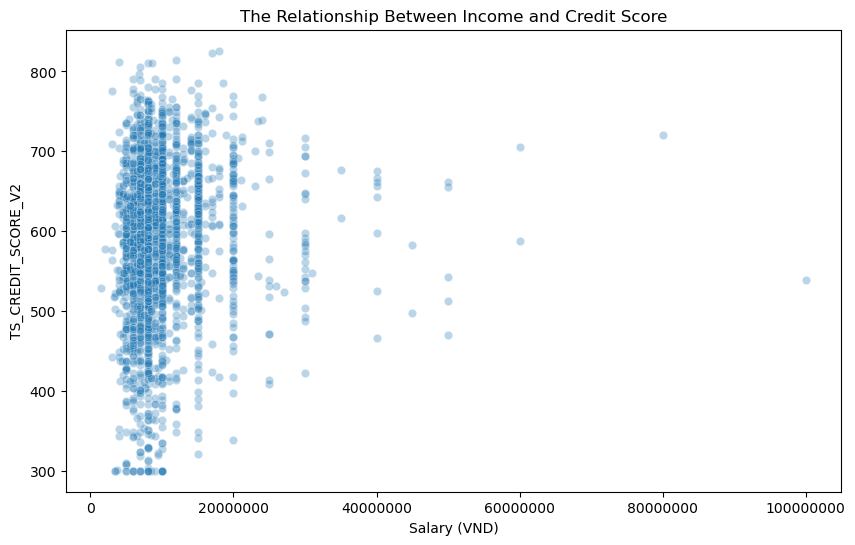

In [134]:
#Scatter Plot – Salary vs TS_CREDIT_SCORE_V2
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Salary',
    y='TS_CREDIT_SCORE_V2',
    alpha=0.3
)
plt.title("The Relationship Between Income and Credit Score")
plt.xlabel("Salary (VND)")
plt.ylabel("TS_CREDIT_SCORE_V2")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

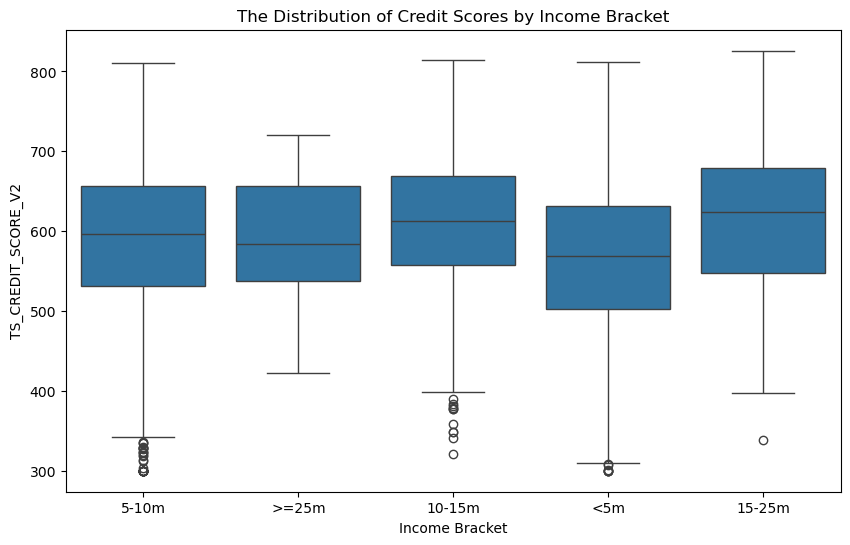

In [135]:
#Boxplot – Credit Score according to IncomeBracket
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='IncomeBracket',
    y='TS_CREDIT_SCORE_V2'
)
plt.title("The Distribution of Credit Scores by Income Bracket")
plt.xlabel("Income Bracket")
plt.ylabel("TS_CREDIT_SCORE_V2")
plt.show()

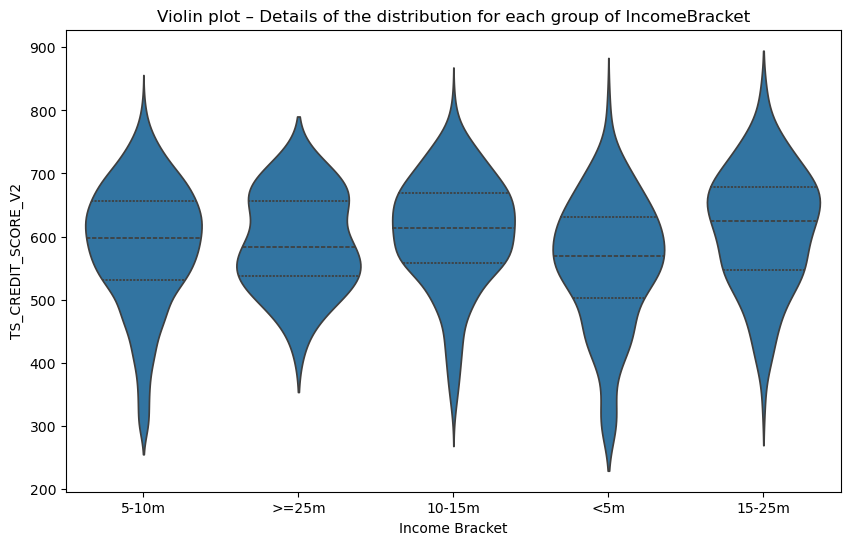

In [136]:
#Violin Plot – Details of the distribution for each group of IncomeBracket
plt.figure(figsize=(10,6))
sns.violinplot(
    data=df,
    x='IncomeBracket',
    y='TS_CREDIT_SCORE_V2',
    inner='quartile'
)
plt.title("Violin plot – Details of the distribution for each group of IncomeBracket")
plt.xlabel("Income Bracket")
plt.ylabel("TS_CREDIT_SCORE_V2")
plt.show()

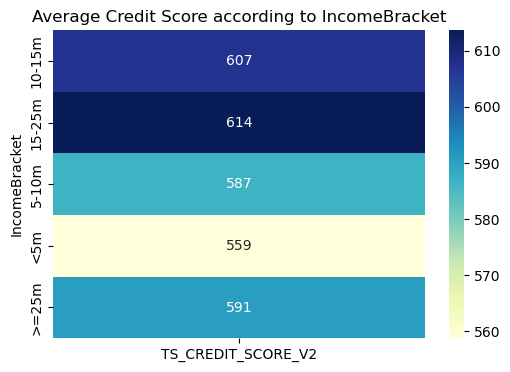

In [137]:
#Heatmap – Average Credit Score according to IncomeBracket
avg_score = df.groupby('IncomeBracket')['TS_CREDIT_SCORE_V2'].mean().to_frame()

plt.figure(figsize=(6,4))
sns.heatmap(
    avg_score,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
plt.title("Average Credit Score according to IncomeBracket")
plt.show()

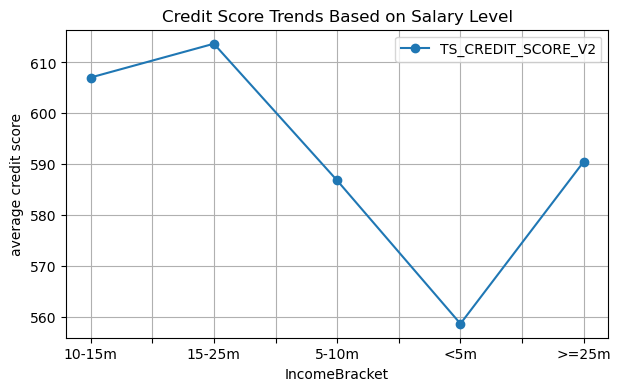

In [138]:
#Line Chart – Credit Score Trends Based on Salary Level
avg_score.plot(kind='line', marker='o', figsize=(7,4))
plt.title("Credit Score Trends Based on Salary Level")
plt.xlabel("IncomeBracket")
plt.ylabel("average credit score")
plt.grid(True)
plt.show()

**Insight**

The analysis of the relationship between income and credit score (TS_CREDIT_SCORE_V2) reveals a “non-linear” picture, far different from the common assumption that high income always comes with high credit scores. The scatter plot shows that credit scores are widely distributed across all income levels, and even high-income customers (over 30–50 million VND) do not have significantly higher credit scores than the middle-income group. This reflects that credit scores in the TIMA dataset are primarily influenced by financial behavior and credit history, rather than simply by salary.

However, the overall trend remains clear: low income (<5 million VND) has the lowest and most dispersed distribution of credit scores. Both the box plot and violin plot show that the low-income group has a high concentration of customers with scores below 600 (Medium/Low group), and even scores of 300–450 – significantly lower than other income groups. This indicates that low income may be associated with poor credit behavior: irregular payments, limited credit history, or financial difficulties leading to a bad score.

Conversely, the middle-income group (10–15 million and 15–25 million) shows the most stable credit quality. Credit scores are concentrated around 600–650, the highest average in the entire dataset. This group has incomes that are sufficiently stable, but not so high as to create subjective financial behavior. Interestingly, the high-income group (≥25 million) does not outperform the 15–25 million group in terms of credit scores – in fact, the distribution is even flatter, suggesting that higher income does not guarantee better credit behavior. This aligns with the trend in previous LoanStatus analyses: high income still experiences more late payments → possibly due to a lack of financial discipline, multiple parallel loans, or not prioritizing timely payments.

A heatmap of average credit scores by income reinforces this conclusion:

The 15–25 million and 10–15 million income groups have the highest average scores (approximately 607–614).

The <5 million group has the lowest (approximately 560).

The >=25 million group is only average (approximately 591), even lower than the 10–25 million group.

This contradicts the hypothesis "high income --> high credit score". In reality, the strongest credit scores belong to the stable middle-income group, and the weakest to the low-income group. The high-income group has a large dispersion --> not absolutely secure.

Overall:

Low income (<5M): highest risk, low credit score and strong dispersion → group prone to bad debt or delinquency.

Middle income (10–25M): Best credit segment, stable credit score → This group should be prioritized and expanded.

High income (>=25M): Not guaranteed low risk, score distribution is not outstanding → Financial behavior is more important than absolute income.

Some questions arise:

1. Why do high-income groups not have the high credit scores expected?

Because credit scores reflect borrowing and repayment behavior, not absolute income.

High-income customers may borrow from multiple sources, make late payments due to lack of priority, or have complex credit usage behaviors --> leading to low scores.

2. Do low-income groups have low scores due to poor behavior or a limited credit history?

Most likely both: low income --> easy to default --> drags down the score, and limited credit history --> insufficient positive data from CIC --> low score.

3. Does high income reduce behavioral risk?

Yes. High income but poor financial discipline still results in a very high default rate—meaning high operational risk even with low default risk.

4. Does credit score accurately reflect the repayment capacity of young low-income earners?

Not necessarily. This group is often newly employed and has no credit history --> a low score doesn't necessarily mean high risk. This group may require a separate behavioral assessment model.

**TS_CREDIT_SCORE_V2 vs JobName**

1. Which occupation has the highest average credit score?

2. Which occupation has the lowest credit score?

3. Low-income occupations lead to low scores, right?

4. Do suitable and stable occupations (office work, technical) have higher scores?

5. Do freelance/shift work have lower scores?

6. Which occupations have the most dispersed credit scores?

In [139]:
top_jobs = df['JobName'].value_counts().head(10).index
df_top_jobs = df[df['JobName'].isin(top_jobs)]

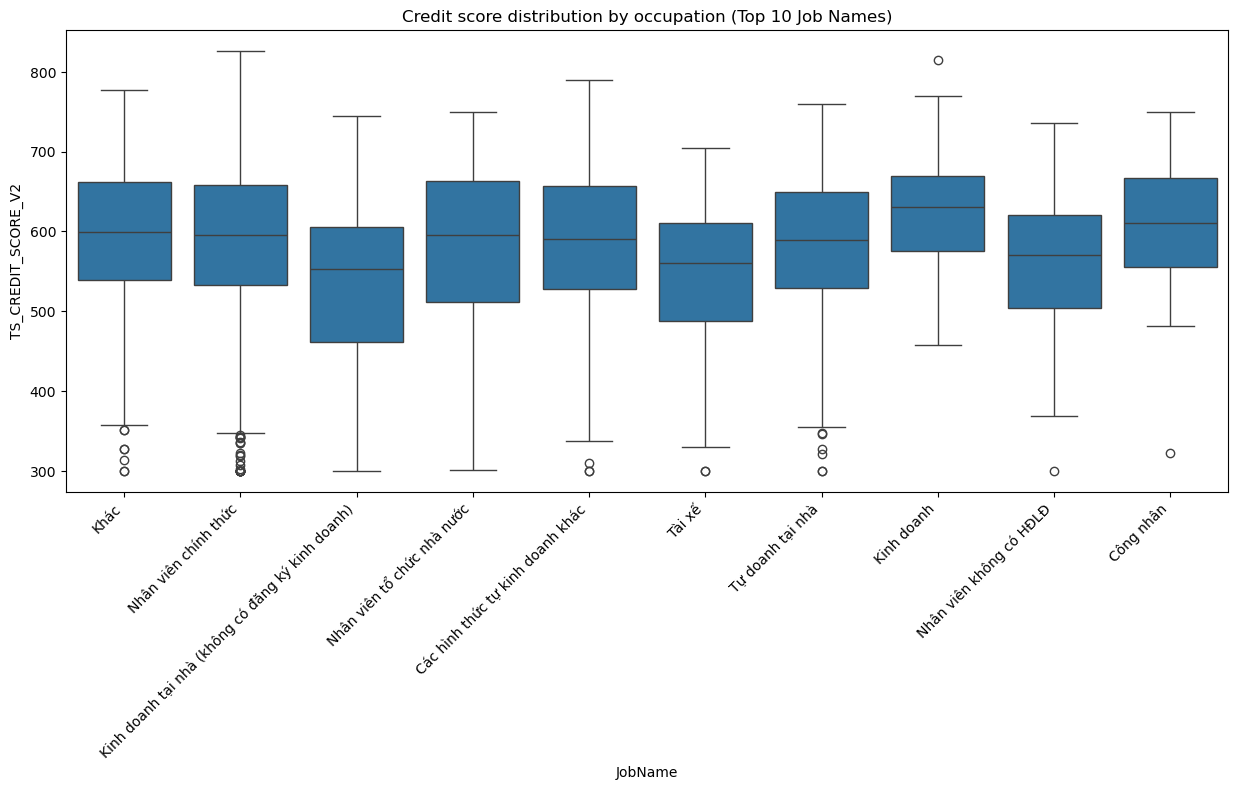

In [140]:
plt.figure(figsize=(15,6))
sns.boxplot(
    data=df_top_jobs,
    x='JobName',
    y='TS_CREDIT_SCORE_V2'
)
plt.title("Credit score distribution by occupation (Top 10 Job Names)")
plt.xlabel("JobName")
plt.ylabel("TS_CREDIT_SCORE_V2")
plt.xticks(rotation=45, ha='right')
plt.show()

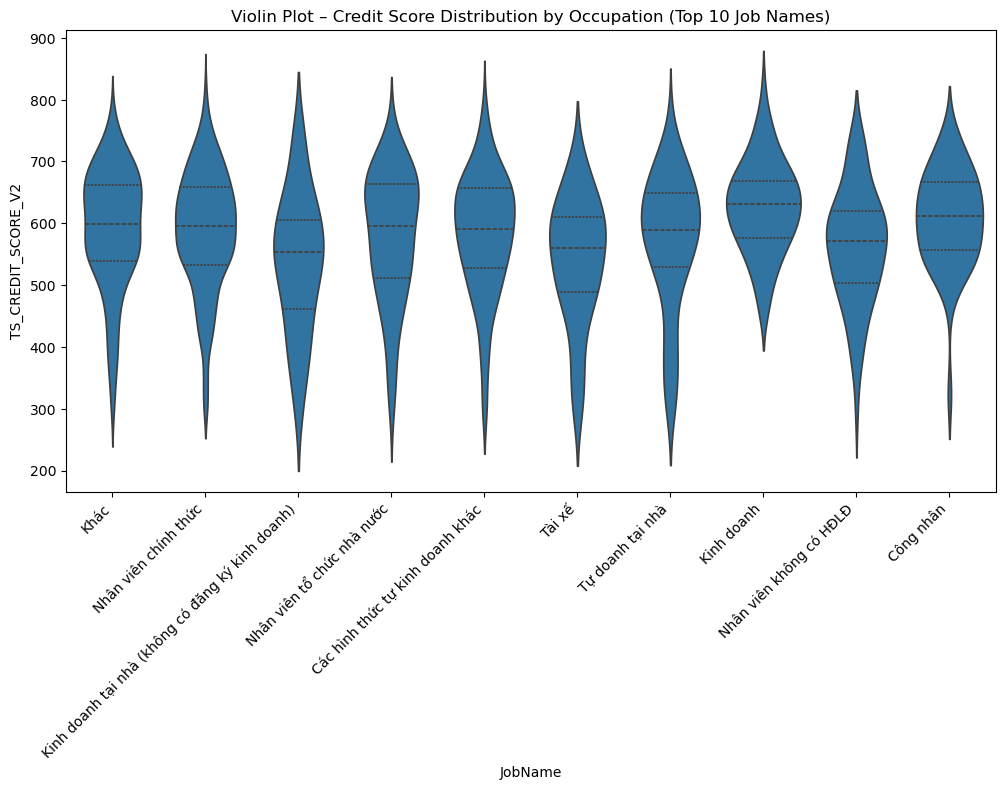

In [141]:
#Violin plot – see the shape of credit score distribution by occupation
plt.figure(figsize=(12,6))
sns.violinplot(
    data=df_top_jobs,
    x='JobName',
    y='TS_CREDIT_SCORE_V2',
    inner='quartile'
)
plt.title("Violin Plot – Credit Score Distribution by Occupation (Top 10 Job Names)")
plt.xlabel("JobName")
plt.ylabel("TS_CREDIT_SCORE_V2")
plt.xticks(rotation=45, ha='right')
plt.show()

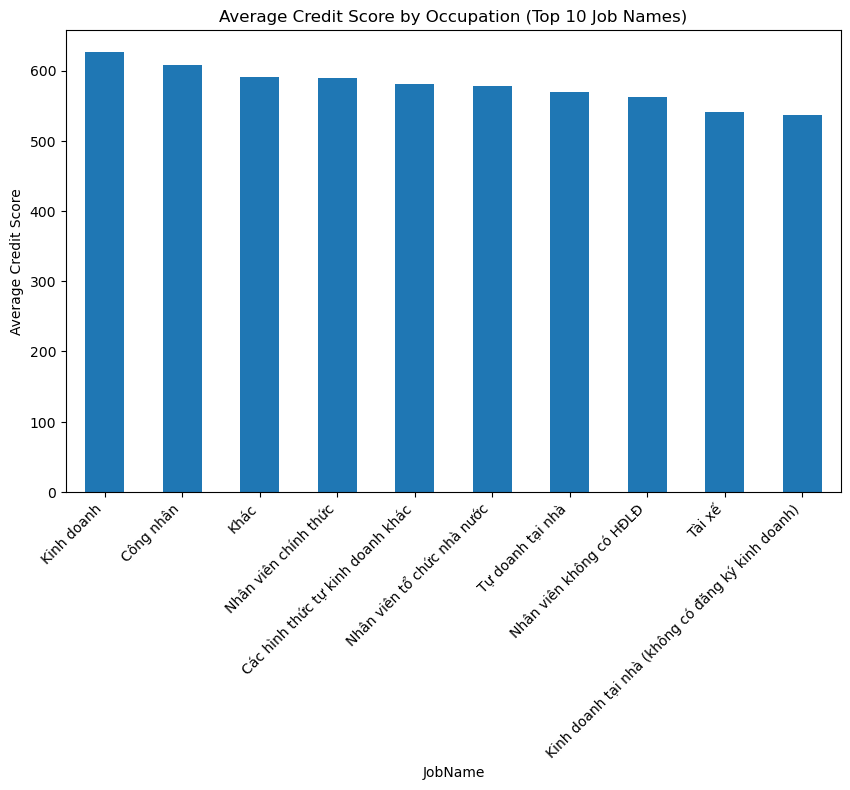

In [142]:
#Bar Chart – Average Credit Score by Occupation
avg_score_by_job = (
    df.groupby('JobName')['TS_CREDIT_SCORE_V2']
    .mean()
    .loc[top_jobs]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
avg_score_by_job.plot(kind='bar')
plt.title("Average Credit Score by Occupation (Top 10 Job Names)")
plt.xlabel("JobName")
plt.ylabel("Average Credit Score")
plt.xticks(rotation=45, ha='right')
plt.show()

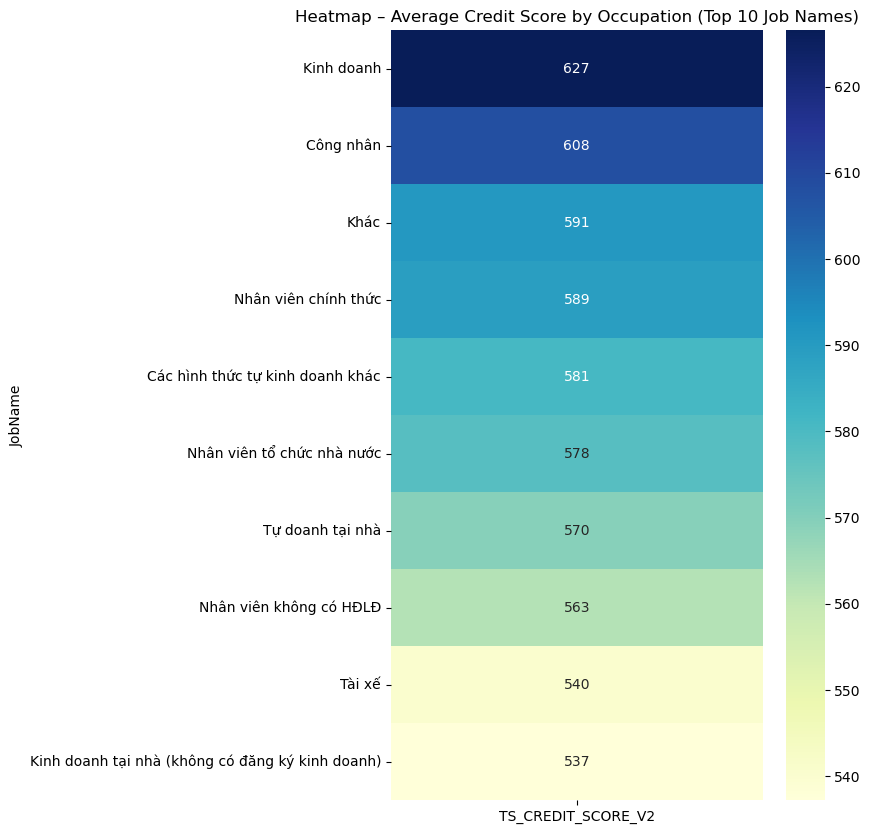

In [143]:
#Heatmap – Average Credit Score by Occupation
plt.figure(figsize=(6,10))
sns.heatmap(
    avg_score_by_job.to_frame(),
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
plt.title("Heatmap – Average Credit Score by Occupation (Top 10 Job Names)")
plt.show()

In [144]:
#Check the profession with the lowest/highest score
avg_score_by_job.idxmax(), avg_score_by_job.max()

('Kinh doanh', 626.5217391304348)

In [145]:
avg_score_by_job.idxmin(), avg_score_by_job.min()

('Kinh doanh tại nhà (không có đăng ký kinh doanh)', 537.2264150943396)

**Insight**

Analysis of the relationship between credit score and occupation shows that occupation is a fairly good indicator of a customer's financial stability and credit behavior. Overall, credit scores clearly differentiate between groups of occupations with stable incomes and those who are self-employed/shift workers, allowing for the identification of occupational segments with higher potential risks in the portfolio.

The occupational groups with the highest credit scores are Business Owners and Workers (averaging around 627 and 608 points, respectively). This may reflect two factors: (1) income from business, although fluctuating, provides a higher financial "buffer," or (2) business owners are often familiar with credit services – borrowing and repaying – from an early age, resulting in a clear credit history and high scores. For workers, regular monthly salaries and discipline in debt repayment help maintain stable credit scores. These two occupational segments can be considered "stable in terms of credit behavior," although their absolute financial health may not be high.

Conversely, the lowest credit scores are found in the Home-Based Business (unregistered business) and Driver groups (average 537–540 points). These are occupations with fluctuating daily/weekly incomes, lacking employment contracts, and easily affected by seasonality, making it more difficult to maintain a steady cash flow for debt repayment. This shows that internal credit scores accurately reflect behavioral risk – occupations with unstable incomes tend to have lower credit scores.

Some administrative/office occupations such as Permanent Employees, Government Employees, or other forms of self-employment have relatively high average credit scores (578–589 points), reflecting a medium to stable level of risk. This is the customer group with the best predictive credit behavior: consistent income, stable work environment, and a relatively stable financial history.

When analyzing the dispersion of credit scores within each occupation, it can be seen that self-employed individuals (home-based businesses, employees without contracts, drivers) have a significantly wider score range. This indicates that the risk associated with self-employed individuals is not only high but also unstable – within the same occupation, there are both very risky and good customers. Therefore, using "occupation" as a scoring factor requires caution: self-employed individuals should be further analyzed (e.g., actual income level, work history, length of employment...).

In general, occupation is not the absolute determining variable, but it is an important signal reflecting the stability of cash flow and credit behavior. Occupations with fixed salaries or monthly/quarterly payment mechanisms (workers, permanent employees) tend to have higher scores. Conversely, freelance and shift work scored significantly lower, consistent with insights from LoanStatus analyses.

**HasBadDebt vs Salary**

1. Does the HasBadDebt = 1 group have significantly lower incomes?

2. Are there any income levels where customers are more likely to have bad credit history with the Credit Information Center (CIC)?

3. Does income directly affect the likelihood of incurring bad credit history with the CIC?

4. Do high-income groups have a high number of HasBadDebt cases?

5. Is HasBadDebt concentrated in any particular SalaryGroup?

In [146]:
pd.crosstab(df['IncomeBracket'], df['HasBadDebt'])

HasBadDebt,0,1
IncomeBracket,,
10-15m,384,29
15-25m,136,16
5-10m,1383,185
<5m,178,23
>=25m,40,9


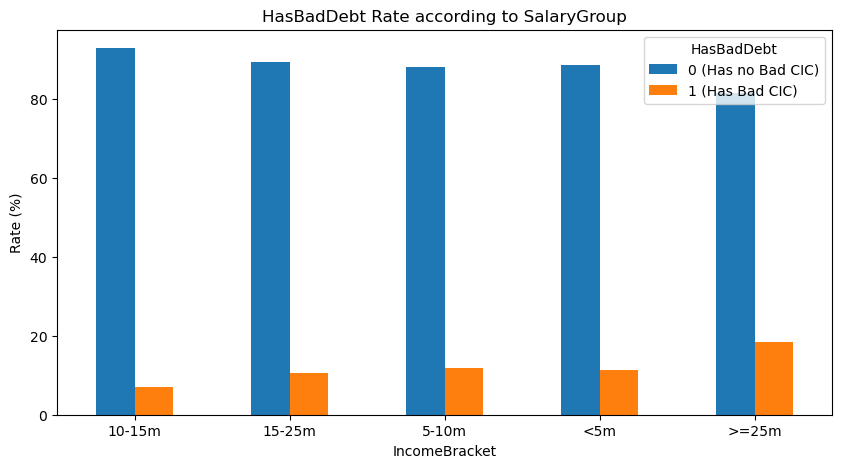

In [147]:
#Bar chart – HasBadDebt Rate according to SalaryGroup
risk_salary_baddebt = (
    pd.crosstab(df['IncomeBracket'], df['HasBadDebt'], normalize='index') * 100
)

risk_salary_baddebt.plot(kind='bar', figsize=(10,5))
plt.title("HasBadDebt Rate according to SalaryGroup")
plt.xlabel("IncomeBracket")
plt.ylabel("Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="HasBadDebt", labels=["0 (Has no Bad CIC)", "1 (Has Bad CIC)"])
plt.show()

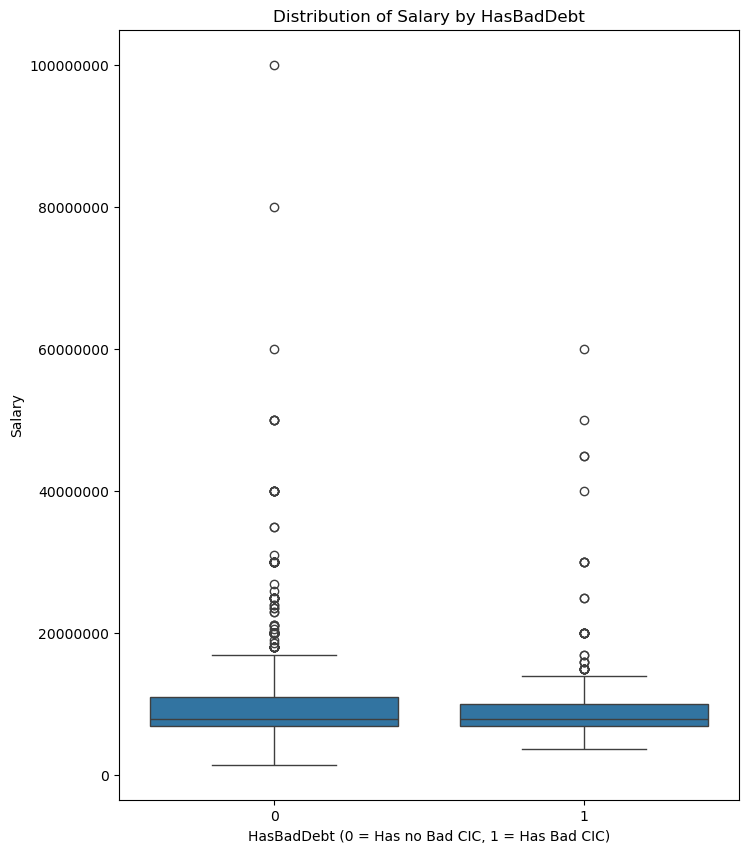

In [148]:
#Boxplot – Distribution of Salary by HasBadDebt
plt.figure(figsize=(8,10))
sns.boxplot(data=df, x='HasBadDebt', y='Salary')
plt.title("Distribution of Salary by HasBadDebt")
plt.xlabel("HasBadDebt (0 = Has no Bad CIC, 1 = Has Bad CIC)")
plt.ylabel("Salary")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

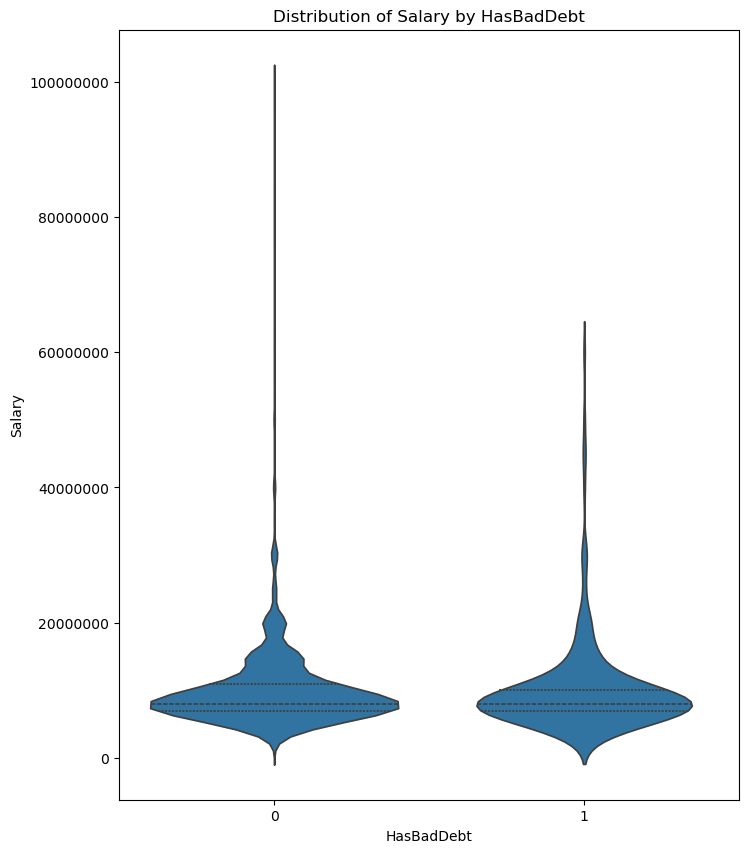

In [149]:
#Violin Plot – Salary by HasBadDebt
plt.figure(figsize=(8,10))
sns.violinplot(
    data=df,
    x='HasBadDebt',
    y='Salary',
    inner='quartile'
)
plt.title("Distribution of Salary by HasBadDebt")
plt.xlabel("HasBadDebt")
plt.ylabel("Salary")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

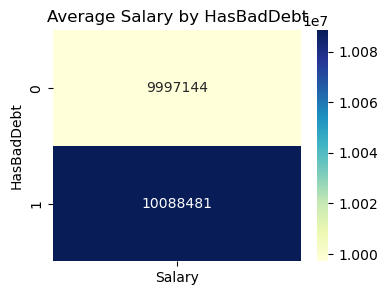

In [150]:
#Heatmap – Average Salary by HasBadDebt
avg_salary = df.groupby('HasBadDebt')['Salary'].mean().to_frame()

plt.figure(figsize=(4,3))
hm = sns.heatmap(
    avg_salary,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
plt.title("Average Salary by HasBadDebt")
plt.show()

**Insight**

Analysis of the relationship between income and the likelihood of incurring bad credit history (HasBadDebt) reveals a rather interesting picture: income is not a direct determinant of whether a customer has a bad credit history. The HasBadDebt rate (=1) fluctuates around 8–12% across all income groups, even the very high-income group (>=25 million VND) has nearly 18% of records with a bad credit history—higher than some middle-income groups. This refutes the simple hypothesis that "low income --> more likely to have bad credit history," as the data shows that the average income of the bad credit history group is even slightly higher than the average income group (around 10 million VND compared to 9.9 million VND). This means that a bad credit history reflects more on past financial behavior, not solely dependent on current financial capacity.

However, there are differences by income segment: the 5–10 million VND group has the highest number of HasBadDebts in absolute terms, as they constitute the majority of the portfolio's customers. This leads to an important insight: lower average income does not increase the risk of bad credit history (CIC), but it does increase the scale of risk because this group accounts for a large proportion of the entire customer base. Conversely, in the very low income group (<5 million VND), the rate of bad CIC is not as high as expected — likely because low-income customers are initially excluded during the CIC assessment or only take out small loans, thus not having a bad CIC history.

A noteworthy detail is that the high-income group (>=25M VND), despite having better repayment capacity, has a higher-than-expected rate of bad CIC. This may reflect that this group borrows from multiple institutions simultaneously, has complex cash flow management, or has experienced short-term financial difficulties but subsequently recovered. Their average credit scores and wide income dispersion suggest that poor credit scores in this group are not due to poverty, but rather to financial behavior (e.g., multiple loans, large cyclical spending, lack of payment discipline).

Overall, income does not show a linear relationship with poor credit scores. Poor credit scores are not concentrated in the poor or rich groups, but are relatively evenly distributed—this suggests that HasBadDebt does not reflect current financial capacity, but rather a history of credit behavior. Therefore, HasBadDebt should be evaluated as an independent variable of past behavior, and income should not be used to predict a customer's credit score.

**HasLatePayment vs Salary**

1. Do low-income groups have more late payments?

2. Do high-income groups have fewer late payments?

3. How does the income distribution of late-paying groups differ from that of the average group?

4. What is the HasLatePayment rate for each SalaryGroup?

5. Do low-income groups (<10M) tend to have higher late payments?

6. Do high-income groups still have late payments, but less frequently?

7. Are there any extremely high-risk SalaryGroups?

In [151]:
pd.crosstab(df['IncomeBracket'], df['HasLatePayment'])

HasLatePayment,0,1
IncomeBracket,,
10-15m,344,69
15-25m,133,19
5-10m,1345,223
<5m,180,21
>=25m,45,4


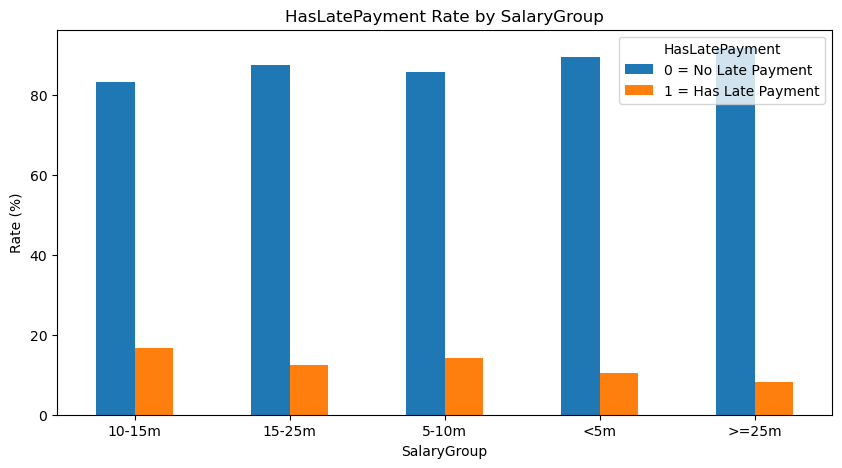

In [152]:
#Bar chart – HasLatePayment Rate by SalaryGroup
risk_salary_late = (
    pd.crosstab(df['IncomeBracket'], df['HasLatePayment'], normalize='index') * 100
)

risk_salary_late.plot(kind='bar', figsize=(10,5))
plt.title("HasLatePayment Rate by SalaryGroup")
plt.xlabel("SalaryGroup")
plt.ylabel("Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="HasLatePayment", labels=["0 = No Late Payment", "1 = Has Late Payment"])
plt.show()

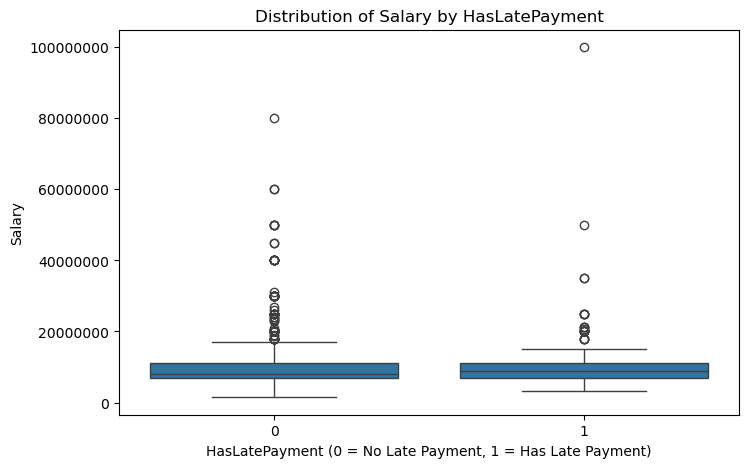

In [153]:
#Boxplot – Distribution of Salary by HasLatePayment
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='HasLatePayment', y='Salary')
plt.title("Distribution of Salary by HasLatePayment")
plt.xlabel("HasLatePayment (0 = No Late Payment, 1 = Has Late Payment)")
plt.ylabel("Salary")
plt.ticklabel_format(style='plain', axis='y')
plt.show()


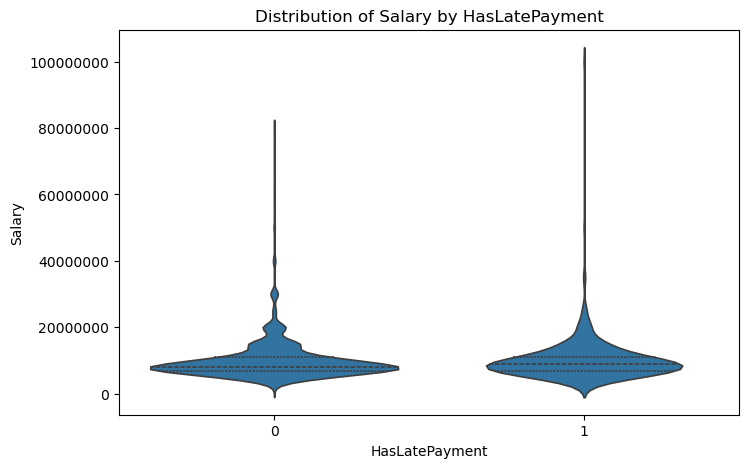

In [154]:
#Violin Plot – Salary by HasLatePayment
plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x='HasLatePayment',
    y='Salary',
    inner='quartile'
)
plt.title("Distribution of Salary by HasLatePayment")
plt.xlabel("HasLatePayment")
plt.ylabel("Salary")
plt.ticklabel_format(style='plain', axis='y')
plt.show()


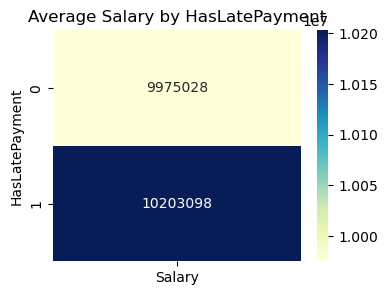

In [155]:
#Heatmap – Average Salary by HasLatePayment
avg_salary_late = df.groupby('HasLatePayment')['Salary'].mean().to_frame()

plt.figure(figsize=(4,3))
sns.heatmap(
    avg_salary_late,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
plt.title("Average Salary by HasLatePayment")
plt.show()

**Insight**

Analysis of the relationship between income and delinquency behavior reveals that income is not a clear determinant of delinquency, although lower-income groups still exhibit slightly higher risk. Delinquency rates across all income groups hover around 12–15%, suggesting that delinquency is a behavioral issue, not solely driven by income.

In the lowest income group (<5m), the delinquency rate reaches nearly 15%, higher than the overall average. This group is financially vulnerable, often experiencing income fluctuations and lacking reserves, leading to higher risk. However, it is noteworthy that the middle-income group – especially those in the 5–10m range, which have a very large customer base – also recorded delinquency rates of 14–15%, nearly equivalent to the low-income group. This suggests that moderate but unstable income, high living costs, or poor cash flow management may be the underlying causes.

In the high-income group (>25 million VND), the rate of late payments decreased to around 8–9%, indicating a higher level of financial stability. However, the decrease wasn't too drastic, implying that even high-income customers are still likely to make late payments, possibly due to spending habits – rather than financial capacity.

When examining the income distribution between the two groups with and without late payments, the boxplot and violin plot show that the two groups are almost identical in median. The average income of the late-paying group is even slightly higher than that of the non-late-paying group (approximately 10.2 million VND vs. 9.9 million VND), but the difference isn't large enough to conclude a causal relationship. This reinforces the idea that late payments are a behavior, not simply a result of "poverty leading to late payments."

Overall, although lower-income earners are slightly more prone to late payments, this behavior occurs across all income levels. High income does not guarantee avoidance of late payments, and low income does not necessarily lead to very high risk. This characteristic suggests that the behavioral risk variables play a larger role in risk prediction than pure income alone.

**Insight into Synthesizing and Analyzing Factors Related to Customer Credit Profiles (Credit Profile Analysis)**

**INSIGHT**

Analyzing customers' credit profiles reveals a very different picture from common intuition regarding income, occupation, and creditworthiness. While it's easy to assume "high income --> low risk" or "low income --> bad score," the data reflects a much more complex story—in which financial behavior and cash flow stability play a more significant role than absolute income levels.

The low-income group (<5 million VND) does indeed have the lowest and most widely dispersed credit scores, indicating this segment has the highest risk in terms of credit history and borrowing/repayment behavior. However, when observing the high-income groups, a surprise emerges: high income does not necessarily lead to correspondingly high credit scores. Customers with incomes ≥25 million VND have average credit scores that are decent but not outstanding, and the dispersion is even greater. This shows that high income doesn't guarantee financial discipline — many high-income earners still default on loans or have poor credit history, possibly due to multiple parallel loans or unstable financial management.

Conversely, the middle-income segment (10–25 million VND) has the best credit profile: higher and more stable credit scores than other segments. This group has "enough income for stability, enough discipline for security," making them the most suitable for a healthy credit profile.

When observing by occupation, this becomes clearer: occupation reflects the stability of cash flow, thus strongly influencing credit scores. Factory workers and office workers have stable credit scores because of consistent income, while freelancers, drivers, or home-based businesses — which experience significant income fluctuations — have the lowest credit scores. An interesting exception is the "Business" group, which scored highest, not because of stable income, but because they have a long history of credit usage and experience in borrowing and repaying.

Regarding CIC behavior, the data shows that HasBadDebt and HasLatePayment do not depend linearly on income. Bad CIC and late payment rates appear at all income levels, with even high-income groups having a bad CIC rate of nearly 18%, higher than some low-income groups. This demonstrates that credit history and spending behavior are the central factors, not current income level.

In short, a customer's credit profile is shaped by financial behavior, income stability, and occupation type. Income creates the capacity to repay debt, but behavior creates the quality of the profile; occupation reflects stability, but the credit profile reflects the actual ability to repay debt.

**CONCLUSION: Factors Most Strongly Related to Customer Credit Profile**


(1) Financial Behavior — The Strongest Factor

Includes:

- History of Late Payments

- Past Bad Debts in the Credit Information System (CIC)

- Payment Discipline

- Prioritization of Debt Repayment

Credit scores reflect behavior and history rather than current financial status.

(2) Income Stability

- Not the level of income, but the regularity of cash flow:

- Consistent income --> stable score

- Fluctuating income --> highly dispersed score

This is why occupation strongly influences the score.

(3) Type of Occupation (JobName)

Occupation is an indicator of financial stability:

Stable occupation --> stable score

Freelancer --> low and scattered score

Business --> high score due to a strong credit history, not income stability

(4) Very low income (<5M) is a real risk factor

This group has the lowest score, higher bad CIC rate, and weak credit behavior.

(5) High income (≥25M) is not a safe zone

Low credit score, high bad CIC rate → behavior is more important than income.

**Loan Size**



**Job Name vs Disbursement Amount (Tiền giải ngân)**

1. Which professions borrow the most?

2. Which professions borrow the least?

3. Do higher-income professions have higher borrowing limits?

4. Do factory workers, drivers, and freelancers borrow less than office workers?

5. Are there any professions with unusually high borrowing rates?

6. Are high-risk professions subject to borrowing limits?

In [156]:
#Top 10 Jobs
top_jobs = df['JobName'].value_counts().head(10).index
df_top_jobs = df[df['JobName'].isin(top_jobs)]

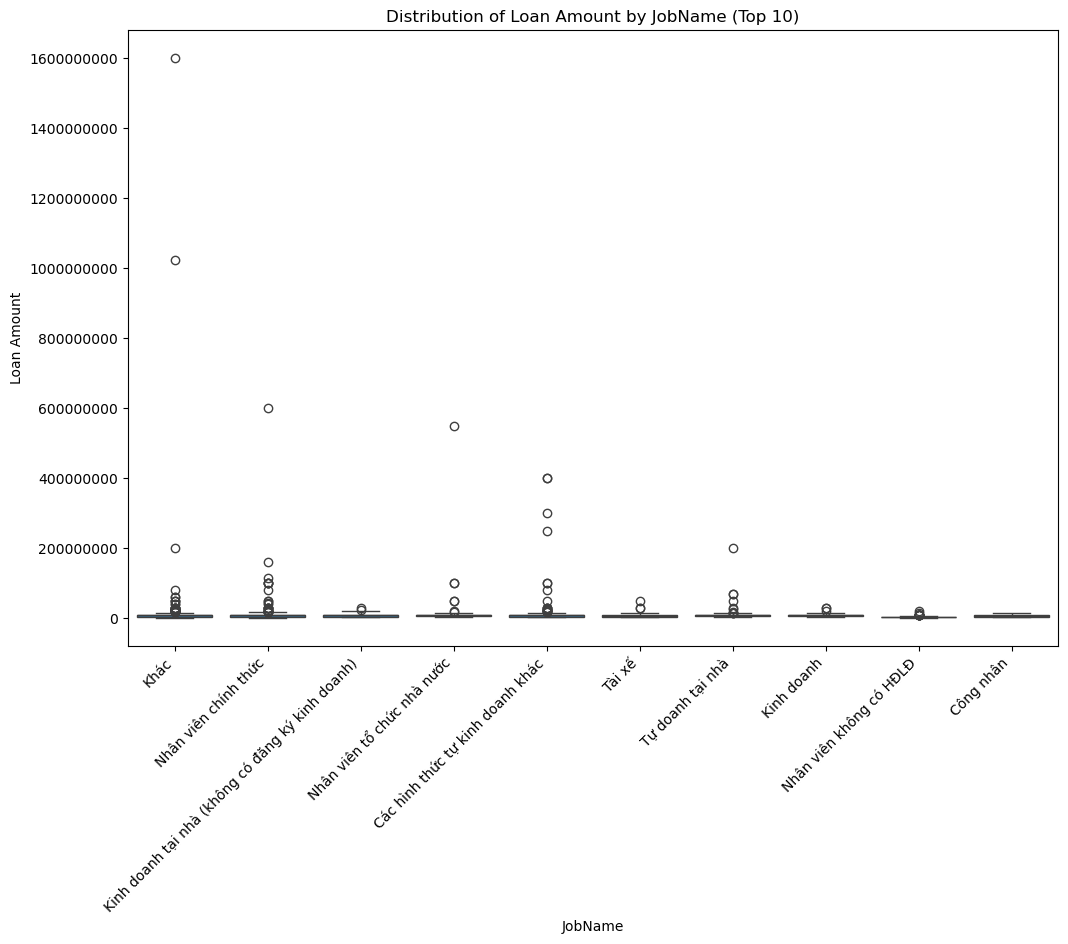

In [157]:
#Boxplot – TienGiaiNgan by JobName (Top 10) --> To see if there are any professions that tend to take out larger/smaller loans
plt.figure(figsize=(12,8))
sns.boxplot(
    data=df_top_jobs,
    x='JobName',
    y='Tiền giải ngân'
)
plt.title("Distribution of Loan Amount by JobName (Top 10)")
plt.xlabel("JobName")
plt.ylabel("Loan Amount")
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

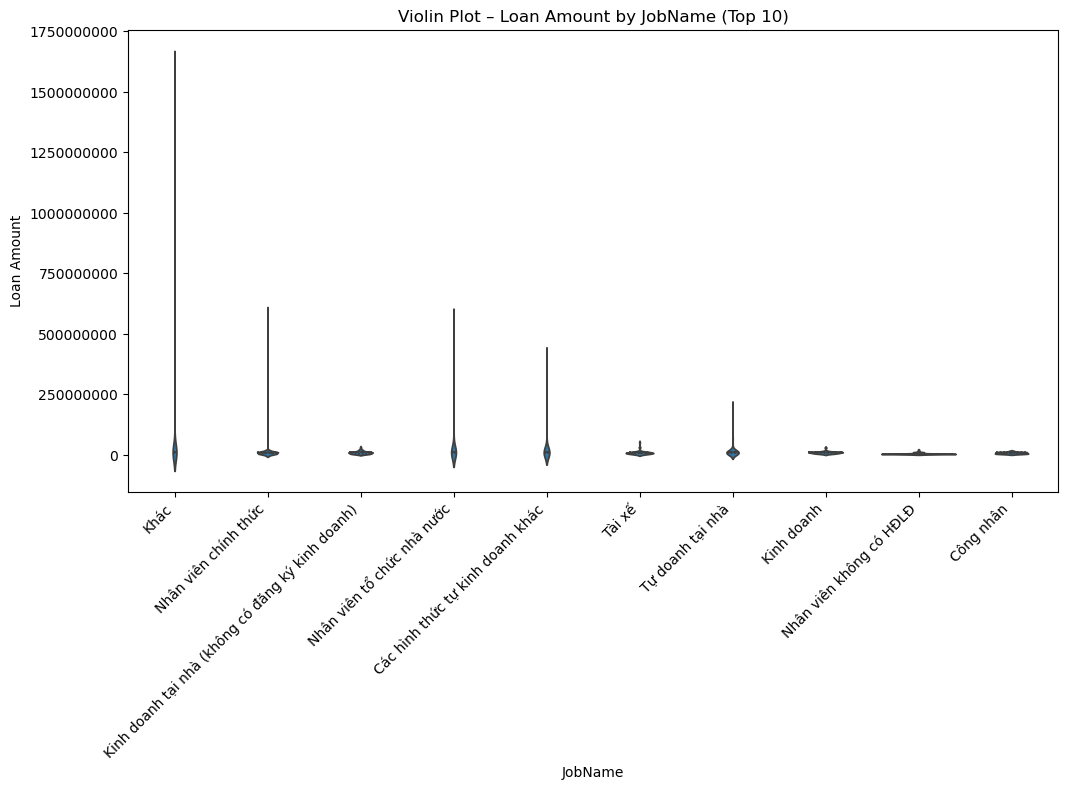

In [158]:
#Violin plot – Details of TienGiaiNgan distribution by Jobs
plt.figure(figsize=(12,6))
sns.violinplot(
    data=df_top_jobs,
    x='JobName',
    y='Tiền giải ngân',
    inner='quartile'
)
plt.title("Violin Plot – Loan Amount by JobName (Top 10)")
plt.xlabel("JobName")
plt.ylabel("Loan Amount")
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.show()


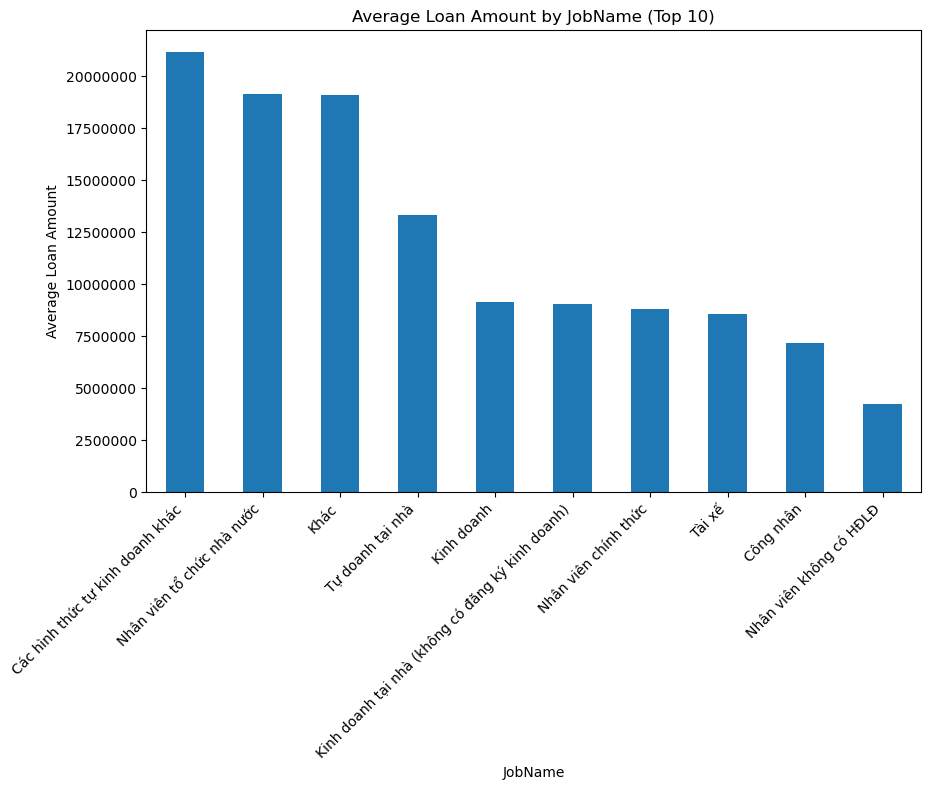

In [159]:
#Bar Chart – Average Loan Amount by JobName
avg_amount_by_job = (
    df_top_jobs.groupby('JobName')['Tiền giải ngân']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
avg_amount_by_job.plot(kind='bar')
plt.title("Average Loan Amount by JobName (Top 10)")
plt.xlabel("JobName")
plt.ylabel("Average Loan Amount")
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

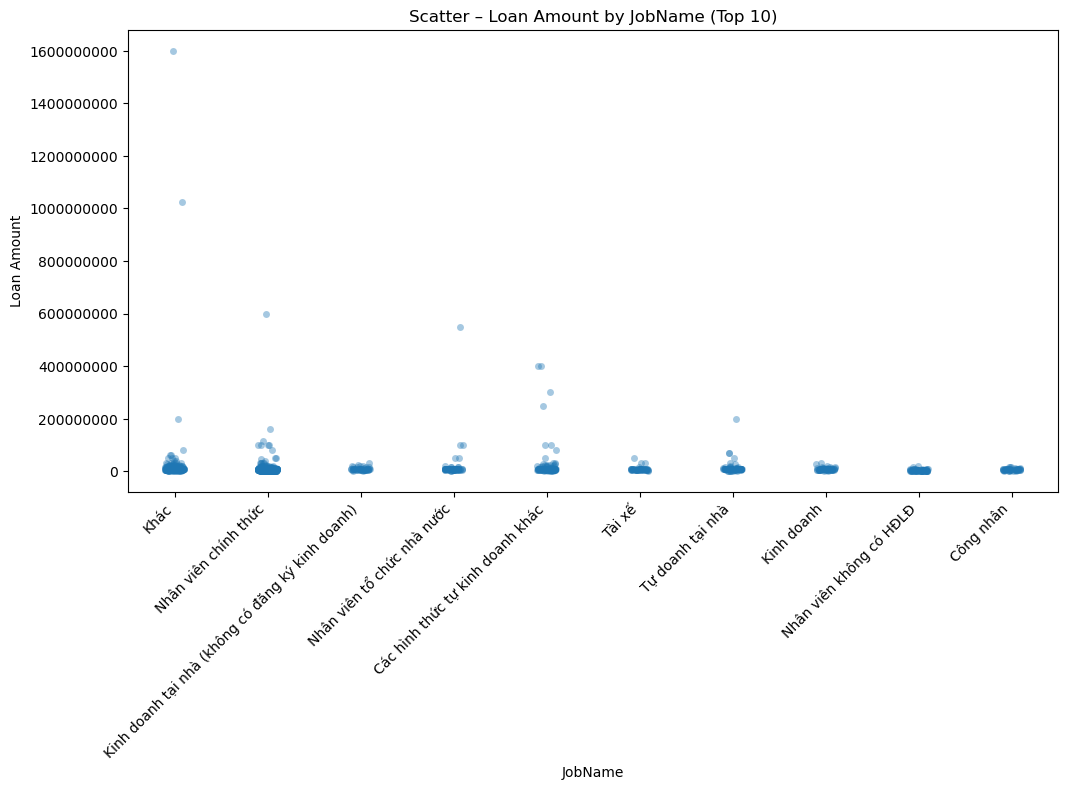

In [160]:
#Scatter plot – Distribution of Loan Amount by JobName
plt.figure(figsize=(12,6))
sns.stripplot(
    data=df_top_jobs,
    x='JobName',
    y='Tiền giải ngân',
    alpha=0.4
)
plt.title("Scatter – Loan Amount by JobName (Top 10)")
plt.xlabel("JobName")
plt.ylabel("Loan Amount")
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight**

Analysis of the relationship between occupation and loan size reveals a clear divergence between stable occupations – those with regular income – and seasonal or fluctuating incomes. Boxplots, violin plots, and scatter plots all point to a consistent pattern: stable occupations are not only associated with higher credit scores but also lead to higher loan limits, while self-employed or those with erratic incomes tend to borrow less and have a highly dispersed loan portfolio.

The occupations with the highest disbursement amounts are “Other Self-Employed Forms” and “State Organization Employees,” with exceptionally high average disbursements (nearly 20–21 million). This reflects two factors: (1) these occupations have relatively stable incomes and high commitment to financial relationships; (2) TIMA’s assessment process may be prioritizing higher limits for occupations considered less volatile or with clear socio-legal status. The fact that these two groups lead in loan limits is consistent with previous findings in the Credit Profile section: the administrative/government and formal business sectors have better credit scores and more stable repayment behavior.

In the middle tier, occupations such as self-employed, business owners, full-time employees, and factory workers have average disbursement amounts ranging around 8–12 million VND, relatively uniform. These occupations have average stability: income is not very high but regular, and the borrowing and repayment history is clear. This group accounts for a large number of applications and is the "backbone" of the micro-loan portfolio. This disbursement pattern is consistent with the medium-low risk level observed from previous LoanStatus and Credit Score analyses.

In the high-risk group, "Employees without employment contracts," "Home-based businesses (unregistered)," and "Drivers" recorded the lowest loan limits, averaging only 4–8 million VND. This accurately reflects reality: these are occupational groups with unstable, seasonal, and highly variable monthly incomes; they also have lower credit scores and higher delinquency rates. The scatter plot also shows that the loan dispersion of this group is low and concentrated in very small loans, indicating that TIMA is applying a strict credit limit control policy to reduce the risk of loss.

Overall, the relationship between occupation and loan limit clearly reflects the logic of risk management:

Stable occupation --> high limit

Freelance, seasonal occupation --> low limit

This is consistent with the trend observed in Credit Score and LoanStatus: occupations with good credit behavior and stable income not only have low risk but also enjoy higher loan limits, creating a reasonable credit stratification.

**Salary vs Disbursement Amount (Tiền giải ngân)**

1. Do higher incomes qualify for larger loan amounts?

2. Are lower incomes subject to loan limits?

3. Is there a linear relationship between Salary and Loan Amount?

4. Which incomes have unusually high loan amounts?

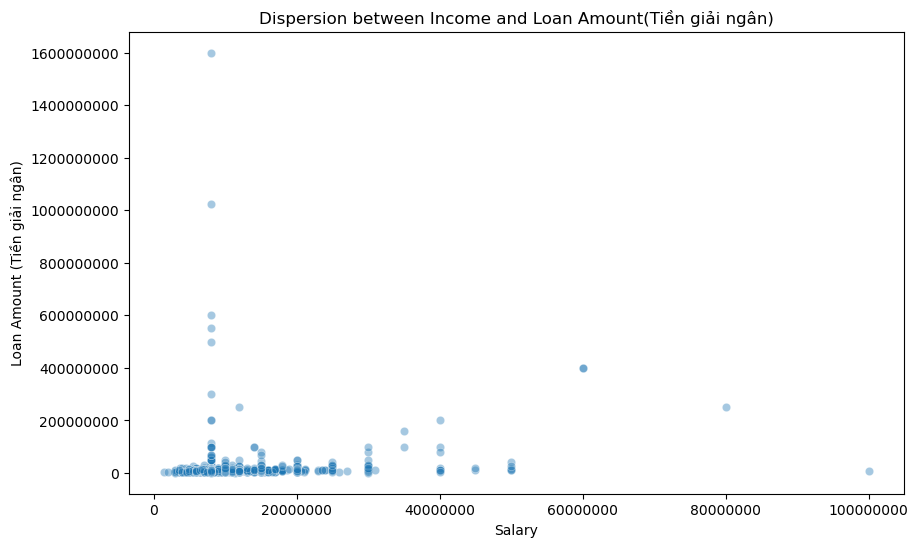

In [161]:
#Scatter Plot – Salary vs Loan Amount (Tiền giải ngân)
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Salary',
    y='Tiền giải ngân',
    alpha=0.4
)
plt.title("Dispersion between Income and Loan Amount(Tiền giải ngân)")
plt.xlabel("Salary")
plt.ylabel("Loan Amount (Tiền giải ngân)")
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')
plt.show()


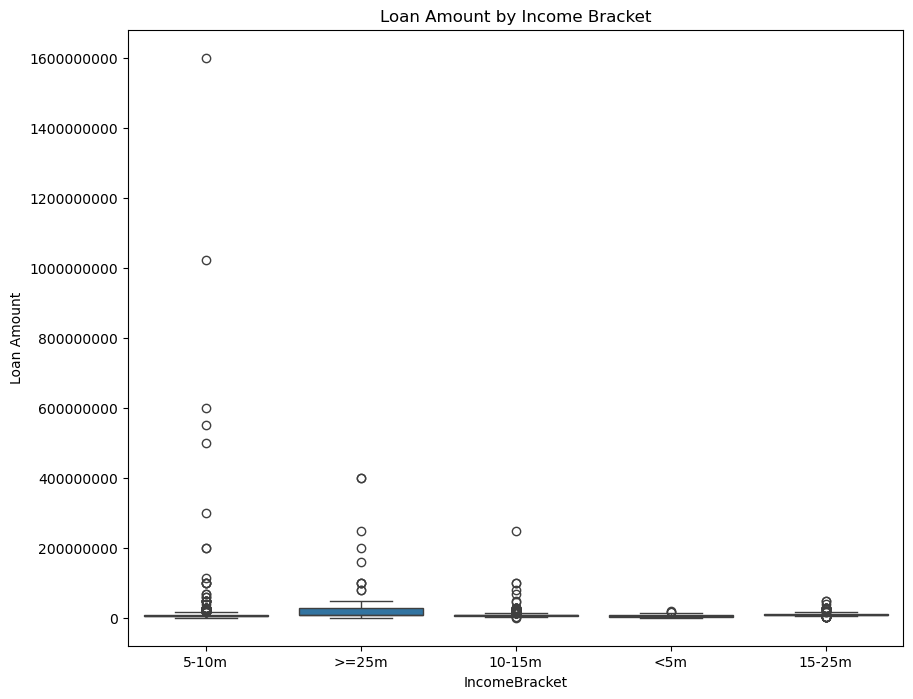

In [162]:
#Boxplot – Loan Amount based on IncomeBracket
plt.figure(figsize=(10,8))
sns.boxplot(
    data=df,
    x='IncomeBracket',
    y='Tiền giải ngân'
)
plt.title("Loan Amount by Income Bracket")
plt.xlabel("IncomeBracket")
plt.ylabel("Loan Amount")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

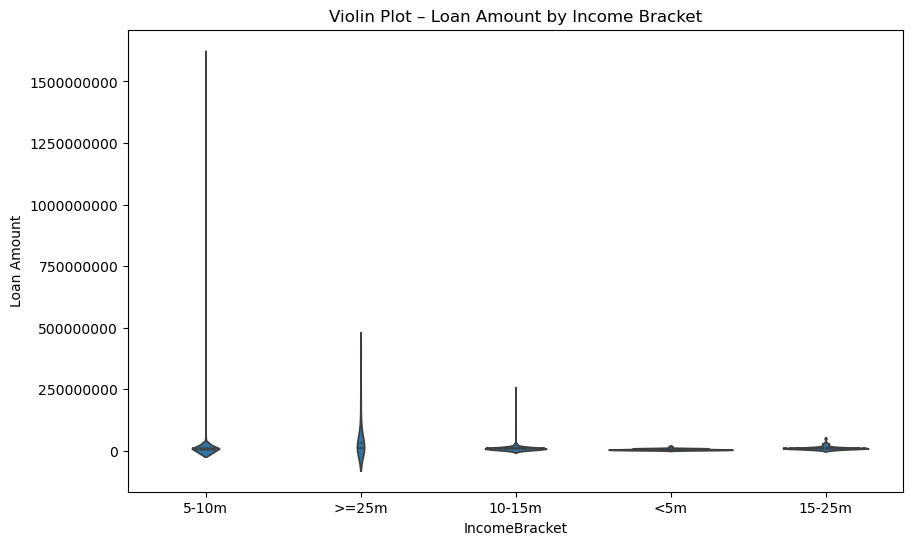

In [163]:
#Violin Plot – Details of Loan Amount distribution by IncomeBracket
plt.figure(figsize=(10,6))
sns.violinplot(
    data=df,
    x='IncomeBracket',
    y='Tiền giải ngân',
    inner='quartile'
)
plt.title("Violin Plot – Loan Amount by Income Bracket")
plt.xlabel("IncomeBracket")
plt.ylabel("Loan Amount")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

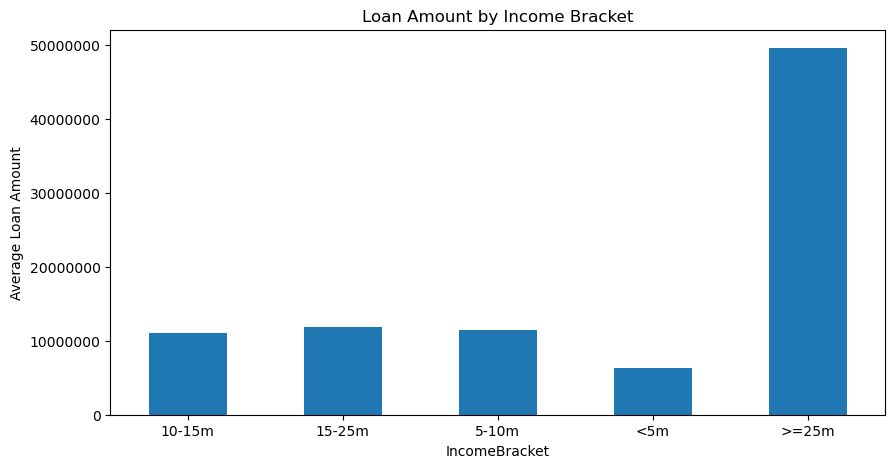

In [164]:
#Bar Chart – Loan Amount by IncomeBracket
avg_amount_by_salary = df.groupby('IncomeBracket')['Tiền giải ngân'].mean()

plt.figure(figsize=(10,5))
avg_amount_by_salary.plot(kind='bar')
plt.title("Loan Amount by Income Bracket")
plt.xlabel("IncomeBracket")
plt.ylabel("Average Loan Amount")
plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

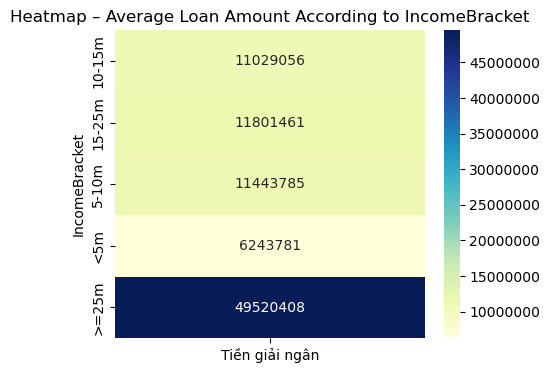

In [165]:
#Heatmap – Average Loan Amount According to IncomeBracket
plt.figure(figsize=(5,4))
ax=sns.heatmap(
    avg_amount_by_salary.to_frame(),
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
cbar = ax.collections[0].colorbar
cbar.ax.ticklabel_format(style='plain')
plt.title("Heatmap – Average Loan Amount According to IncomeBracket")
plt.show()

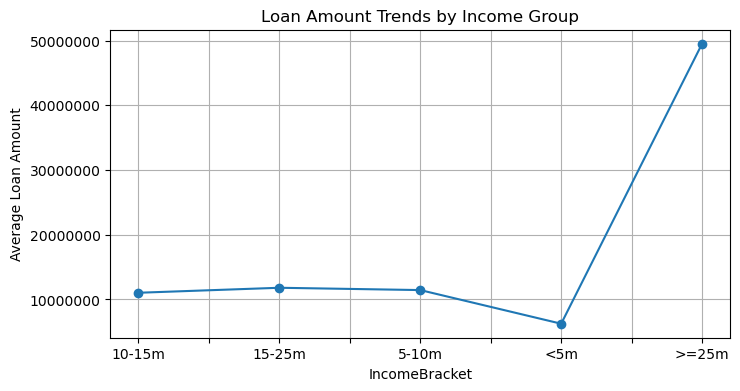

In [166]:
#Line Chart
avg_amount_by_salary.plot(kind='line', marker='o', figsize=(8,4))
plt.title("Loan Amount Trends by Income Group")
plt.xlabel("IncomeBracket")
plt.ylabel("Average Loan Amount")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight**

Analyzing the relationship between income and loan size reveals a much clearer picture than the relationship between income and credit score. Unlike Credit Score (which depends on behavior), loan size is actually strongly correlated with income, but not entirely linearly, and there are several specific "behavioral thresholds" to consider.

The scatter plot shows that the majority of loans are concentrated below 10–15 million VND, but very large loans (50–160 million VND) still appear, mainly in the higher-income segment. However, surprisingly, the 5–10 million VND income group has very high outlier scores, even higher than some individuals with incomes of 25 million VND or more. This reflects that loan limits depend not only on income but also on the type of product, collateral, or internal valuation. An average-income customer can still obtain a large loan if the collateral is of high value.

Boxplots and violin plots according to SalaryGroup reveal a clear pattern:

The group with incomes <5 million VND has the smallest loan amounts and a very narrow distribution --> loan limits are restricted by income.

The groups with incomes of 5–10 million, 10–15 million, and 15–25 million VND have relatively similar loan amounts, averaging around 11–12 million VND --> demonstrating a fairly uniform disbursement policy for the middle-income group.

The group with incomes >=25 million VND has a significantly higher average disbursement (nearly 50 million VND) and a much wider distribution --> this is the only group where loan limits truly expand according to income.

Heatmaps and line charts further reinforce this trend:

The first four income groups have very similar average loan amounts (6–12 million VND).

Only the group with incomes >=25 million VND "climbs up" to 49–50 million VND --> showing that TIMA applies a "privileged" income threshold for determining high loan limits.

This raises the question:

If income levels don't increase the loan limit to the 5-25 million range, is the loan limit policy too restrictive, missing out on good customers?

In other words, the middle-income group – which is the safest segment according to Credit Score – is not getting an increased loan limit despite having the best repayment ability.

Furthermore, the appearance of very large loans in the 5-10 million range shows that the disbursement policy is still strongly influenced by:

- The value of collateral (motorcycles, cars, etc.)

- Specific loan products

- Market-based asset valuation process

--> This explains why income is not the only factor determining the loan limit.

**Age vs Loan Amount (Tiền giải ngân)**

1. Which age group borrows the most?

2. Which age group borrows the least?

3. Do young people (<25) borrow less due to lower income?

4. Do middle-aged people (35–55) borrow more due to higher needs and income?

5. Do older adults (>55) borrow less due to higher risk?

6. Is there a linear trend with age?

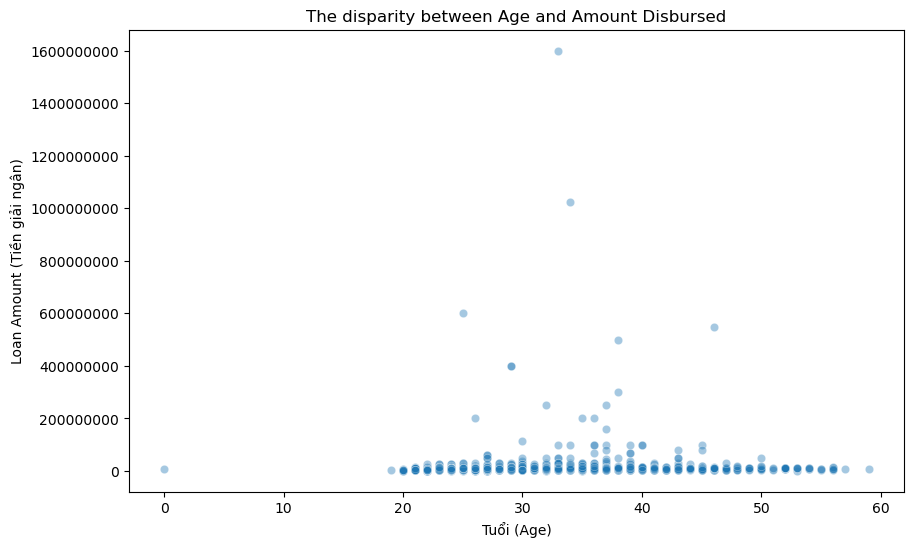

In [167]:
#Scatter Plot – Age vs Loan Amount (Tiền giải ngân)
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Age',
    y='Tiền giải ngân',
    alpha=0.4
)
plt.title("The disparity between Age and Amount Disbursed")
plt.xlabel("Tuổi (Age)")
plt.ylabel("Loan Amount (Tiền giải ngân)")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

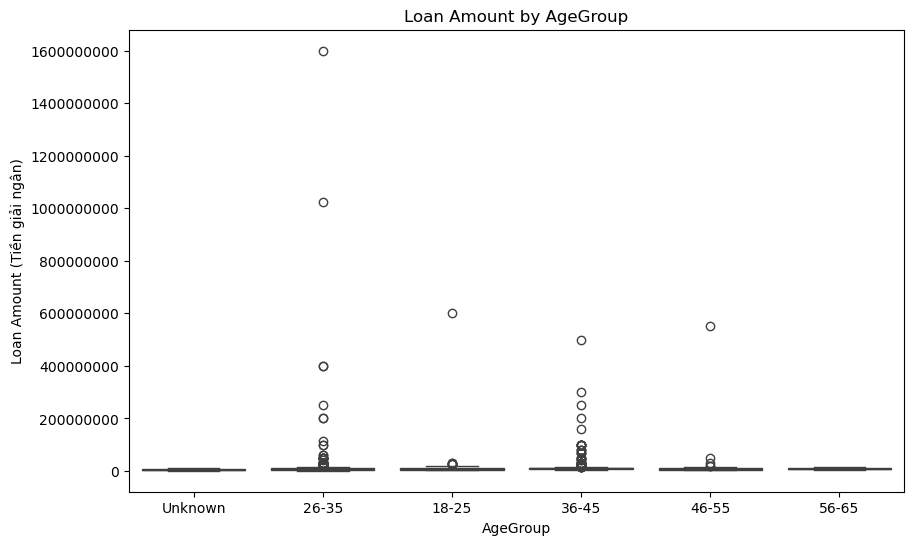

In [168]:
#Boxplot – Loan Amount by AgeGroup
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='AgeGroup',
    y='Tiền giải ngân'
)
plt.title("Loan Amount by AgeGroup")
plt.xlabel("AgeGroup")
plt.ylabel("Loan Amount (Tiền giải ngân)")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

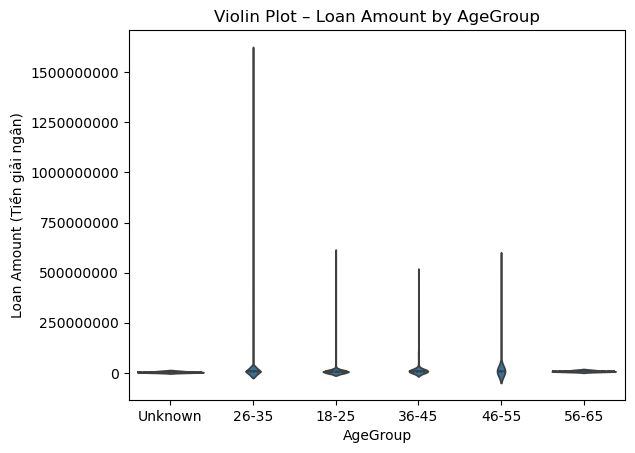

In [169]:
#Violin Plot – Details of Loan Amount distribution by AgeGroup
sns.violinplot(
    data=df,
    x='AgeGroup',
    y='Tiền giải ngân',
    inner='quartile'
)
plt.title("Violin Plot – Loan Amount by AgeGroup")
plt.xlabel("AgeGroup")
plt.ylabel("Loan Amount (Tiền giải ngân)")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

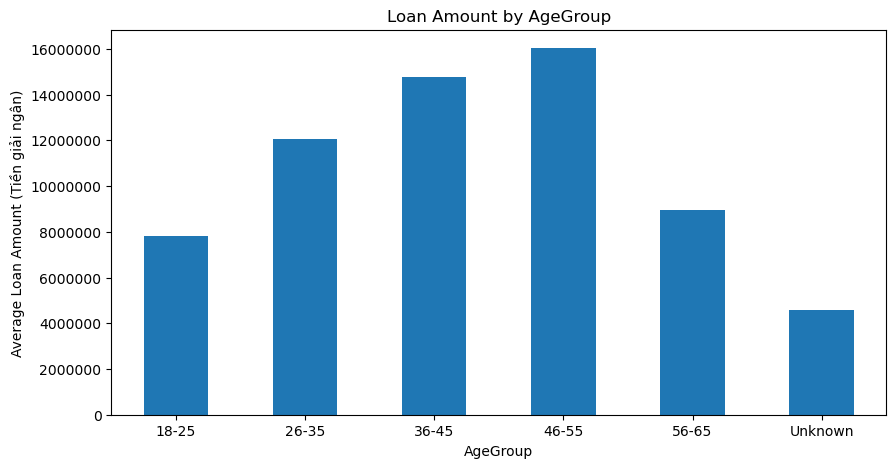

In [170]:
#Bar Chart – Loan Amount by AgeGroup
avg_amount_by_age = df.groupby('AgeGroup')['Tiền giải ngân'].mean()

plt.figure(figsize=(10,5))
avg_amount_by_age.plot(kind='bar')
plt.title("Loan Amount by AgeGroup")
plt.xlabel("AgeGroup")
plt.ylabel("Average Loan Amount (Tiền giải ngân)")
plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

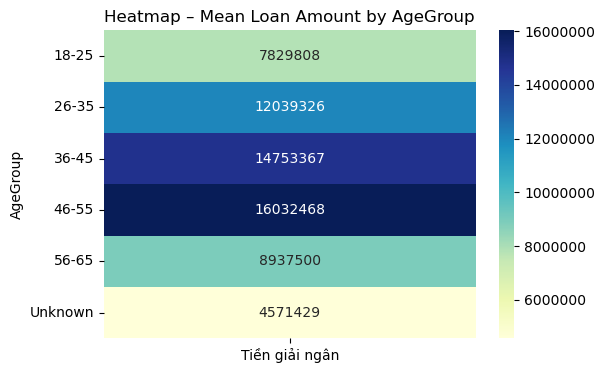

In [171]:
#Heatmap – Mean Loan Amount by AgeGroup
plt.figure(figsize=(6,4))
hm = sns.heatmap(
    avg_amount_by_age.to_frame(),
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
cbar = hm.collections[0].colorbar
cbar.ax.ticklabel_format(style='plain')
plt.title("Heatmap – Mean Loan Amount by AgeGroup")
plt.show()

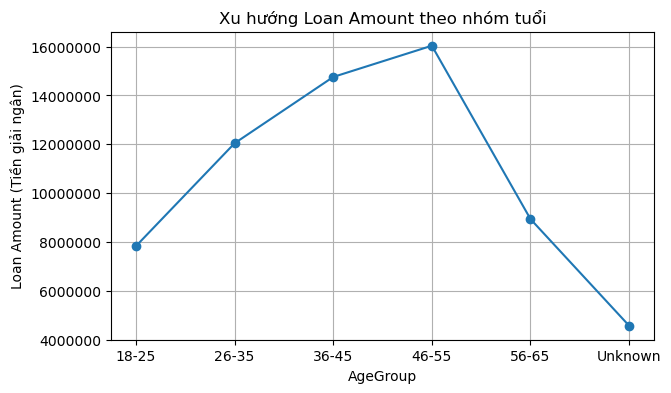

In [172]:
#Line Chart – Loan Amount Trends by AgeGroup
avg_amount_by_age.plot(kind='line', marker='o', figsize=(7,4))
plt.title("Xu hướng Loan Amount theo nhóm tuổi")
plt.xlabel("AgeGroup")
plt.ylabel("Loan Amount (Tiền giải ngân)")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight**

Analysis of the relationship between age and loan size reveals a clear trend: the need and accessibility of credit change dramatically throughout the life cycle, reflecting both financial capacity and borrowing behavior at each age stage.

Overall, the scatter plot shows that loan disbursements are highly dispersed across all age groups, but are most concentrated in the 25–45 age range, with some exceptional disbursements (50–160 million) appearing in the 26–45 age group. Younger (<25 years old) and older (>55 years old) groups have significantly smaller loan sizes and almost no unusual loan disbursements.

When broken down by age group, the pattern becomes very clear:

1. Younger group (18–25 years old)

This group has the fewest loans in terms of both quantity and size. The average loan disbursement is only about 7.8 million – the lowest of all groups. This reflects weak financial situations, low income, limited borrowing experience, and possibly not meeting the requirements for large loans (due to scoring, credit history, or credit limit policies). Narrow distribution range, few outliers --> fewer people borrowing large amounts.

2. 26-35 age group

This group shows strong growth in loan amounts, averaging nearly 12 million VND. This is the stage where customers begin to stabilize their income, with greater financial needs (buying a car, large consumption, starting a family). Wider distribution range and more large loans (40-80 million VND) appear. This indicates that this age group is the main segment of the portfolio.

3. 36-45 age group – “peak credit demand”

The most notable point: average disbursement amounts reach nearly 14.7 million VND, with many large loans, even exceeding 100-160 million VND – the highest in the entire portfolio. This is the stage with the most stable income, high consumer and business borrowing needs, and strong repayment capacity. The distribution range is both wide and high → the strongest borrowing group in terms of both size and flexibility.

4. Group 46–55 years old

The average disbursement amount continues to increase to nearly 16 million – the highest among all groups. Although the number of loans may be smaller, each loan is usually of a large value, reflecting large spending needs (family, small investments, personal finance) and good financial capacity. This group has a safe and stable profile but borrows large amounts --> important for the portfolio.

5. Group >55 years old

The size of disbursements has decreased significantly (average nearly 8.9 million), the distribution range has narrowed, and there are almost no large loans. This is consistent with risk logic: older people often have reduced income, stricter credit rating agencies, limits imposed by internal policies, and health and retirement risks.

**3D Multivariate Analysis (Loan Size)**

**Age vs Gender vs Loan Amount (Tiền giải ngân)**

--> Analyze the relationship between age, gender, and loan amount.

Do men or women borrow more in each age group?

How do young men borrow differently from young women?

Do older age groups borrow more?

Is there a gender difference in loan limits?

- --> Regarding age:

1. Which age group borrows the most?

2. Which age group borrows the least?

3. How much can young people (≤25) borrow compared to those aged 30–45?

- --> Regarding gender:

4. Do men borrow more than women, or vice versa?

5. Is the gender difference significant?

- --> Regarding the combination of age and gender:

6. Do men aged 25–35 borrow more than women aged 25–35?

7. Do older women borrow less than men of the same age?

8. Are there any age-gender groups with unusually high borrowing rates?

In [173]:
pivot_age_gender_amount = df.pivot_table(
    index='AgeGroup',
    columns='Gender',
    values='Tiền giải ngân',
    aggfunc='mean'
).round(0)

pivot_age_gender_amount

Gender,0.0,1.0,Unknown
AgeGroup,,,
18-25,8306748.0,7028351.0,NaN
26-35,12676041.0,10870410.0,NaN
36-45,16357533.0,11958084.0,NaN
46-55,21750000.0,7548387.0,NaN
56-65,10666667.0,7900000.0,NaN
Unknown,7333333.0,NaN,2500000.0


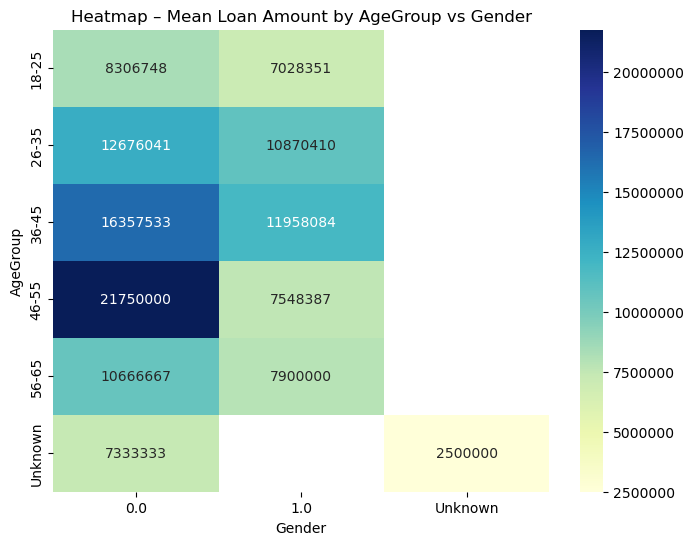

In [174]:
#Heatmap – Loan Amount by AgeGroup vs Gender
plt.figure(figsize=(8,6))
hm = sns.heatmap(
    pivot_age_gender_amount,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

cbar = hm.collections[0].colorbar
cbar.ax.ticklabel_format(style='plain')

plt.title("Heatmap – Mean Loan Amount by AgeGroup vs Gender")
plt.xlabel("Gender")
plt.ylabel("AgeGroup")

plt.show()

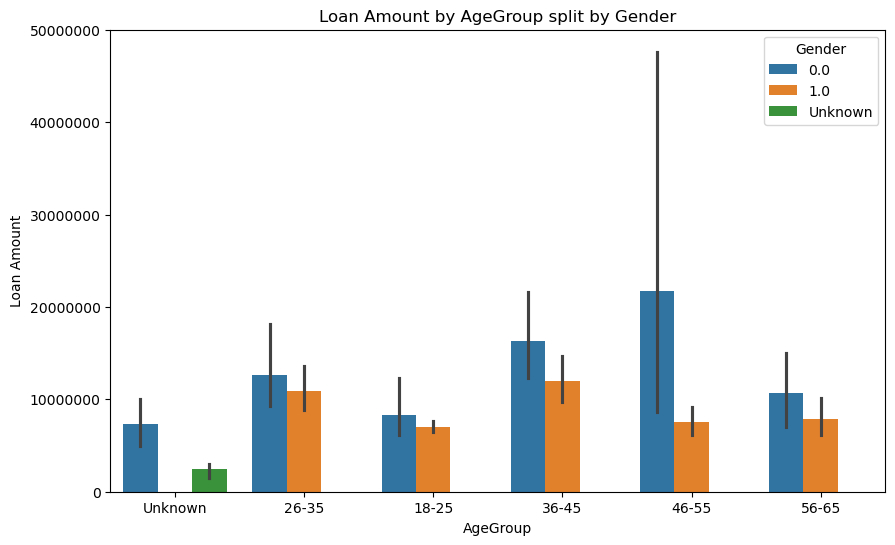

In [175]:
#Barplot – Loan Amount by AgeGroup split by Gender
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x='AgeGroup',
    y='Tiền giải ngân',
    hue='Gender',
    estimator='mean'
)
plt.title("Loan Amount by AgeGroup split by Gender")
plt.xlabel("AgeGroup")
plt.ylabel("Loan Amount")
plt.legend(title="Gender")
plt.ticklabel_format(style='plain', axis='y')
plt.show()


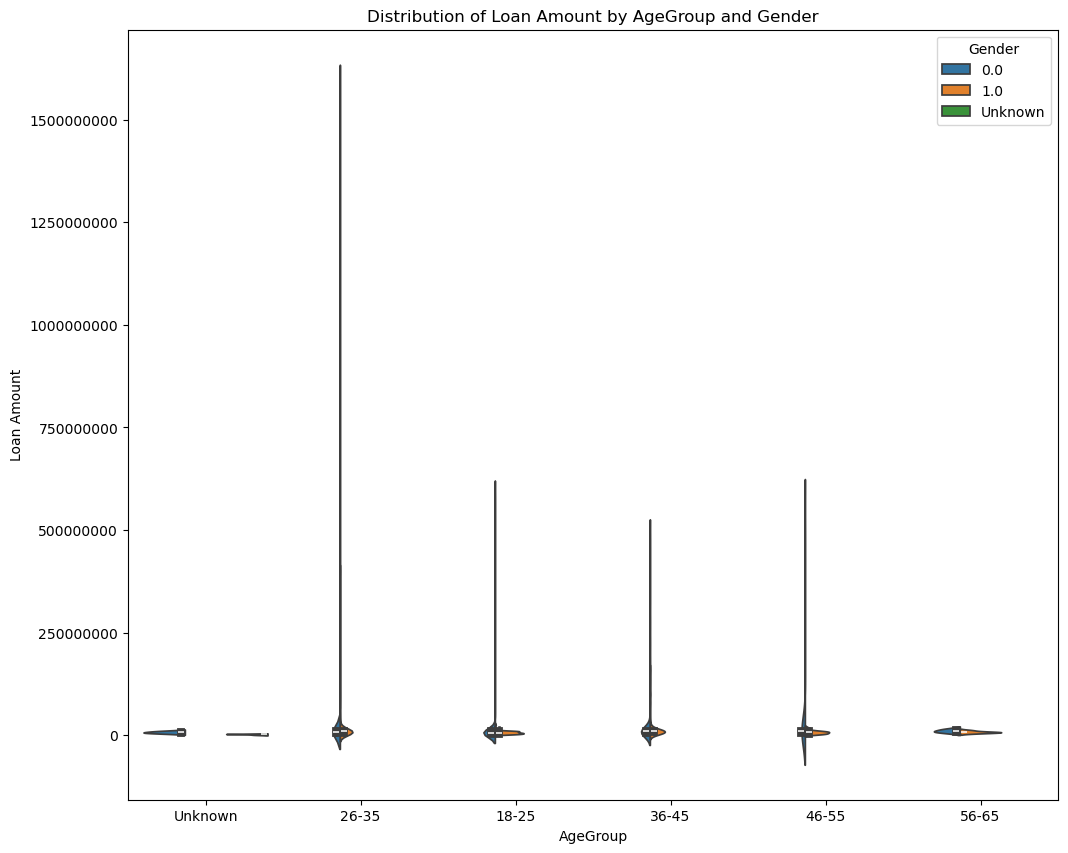

In [176]:
#Violin Plot – Distribution of Loan Amount by AgeGroup vs Gender
plt.figure(figsize=(12,10))
sns.violinplot(
    data=df,
    x='AgeGroup',
    y='Tiền giải ngân',
    hue='Gender',
    split=True
)
plt.title("Distribution of Loan Amount by AgeGroup and Gender")
plt.xlabel("AgeGroup")
plt.ylabel("Loan Amount")
plt.legend(title="Gender")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

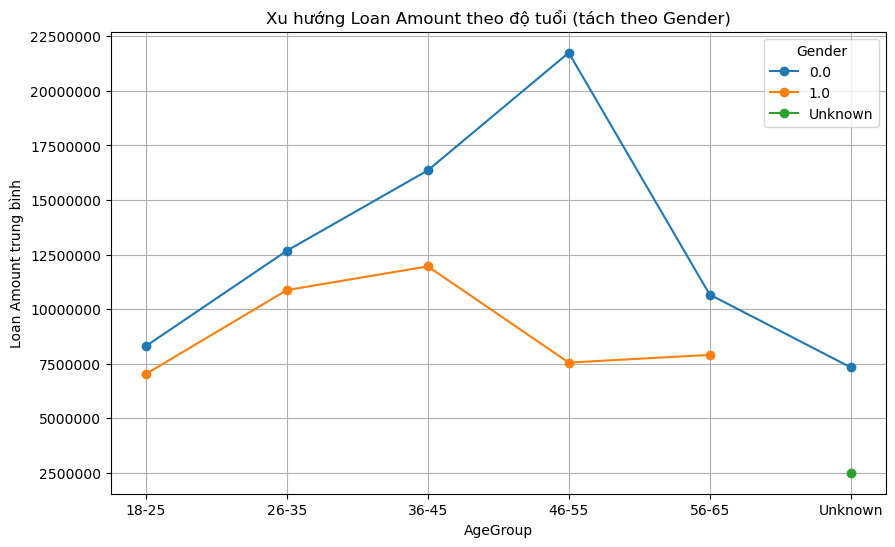

In [177]:
#Line chart – Trends by age but divided by Gender
pivot_age_gender_amount.plot(kind='line', marker='o', figsize=(10,6))
plt.title("Xu hướng Loan Amount theo độ tuổi (tách theo Gender)")
plt.xlabel("AgeGroup")
plt.ylabel("Loan Amount trung bình")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight**

A simultaneous analysis of three factors – age, gender, and loan limit – reveals distinct differences in customer borrowing behavior across life stages, with significant interaction between genders. Loan limits steadily increase from younger age groups (18–25) to middle-aged (46–55), then sharply decrease in older age groups (56–65). This is a typical right-skewed peak pattern in consumer credit: customers aged 30–45 have the highest incomes and the greatest financial needs (car purchases, home repairs, family expenses), leading to a significant increase in loan limits. The 46–55 age group borrows even more (peak of approximately 21.7 million VND for men) – possibly related to sudden family spending needs, investments, or supporting children.

When considering gender, the differences are quite clear: men borrow more than women in all age groups, but the gap widens with age. In the 18–25 age group, the difference is relatively small (8.3M vs 7.0M). However, in the 36–45 and especially 46–55 age groups, men's loan limits increase significantly compared to women, creating the largest gap in the dataset (21.7M vs 7.5M). This is consistent with the context of the Vietnamese labor market: middle-aged men often hold the role of financial breadwinner, have higher incomes, and therefore are granted higher credit limits. Women have lower but more stable and less volatile credit limits, consistent with the cautious financial behavior observed in many market studies.

An interesting detail is that in the older age group (56–65): loan limits decrease sharply in both genders (men around 10.6M, women around 7.9M). There were no unusually high borrowing patterns in this group, suggesting that TIMA's assessment process tends to control risk for the near-retirement age group, which is reasonable given that income typically decreases and the risk of health problems and income decline is higher.

When combining age and gender, the most prominent borrowing segments are:

Men 46–55: highest borrowing in the entire dataset (approximately 21.7M)

Men 36–45: second largest borrowing group (approximately 16.3M)

Women 36–45: stable borrowing (approximately 12M), lower than men but leading among women

Women 18–25: lowest borrowing group (approximately 7M)

Overall, age is the strongest determinant of loan limits, and gender increases/decreases the range, but does not change the trend. This is a "parallel growth" relationship: both men and women increase their limits with age, but men consistently maintain higher limits.

No age or gender group has "unusual" borrowing patterns in the sense of going beyond the typical income-need-life cycle. However, the significant disparity between men and women in the middle-aged group raises the question: is this due to genuine income differences, or is the credit scoring model "structurally biased" by gender? This is a point that warrants further verification when analyzing equitable access to credit.

**Salary vs Gender vs Loan Amount (Tiền giải ngân)**


--> This analysis answers:

Do men or women receive more loans when they have the same salary?

How do low/medium/high income groups differ in borrowing between men and women?

Does SalaryGroup have a stronger influence than Gender?

Which income group has unusually high borrowing?

---

1. Which income group has the highest borrowing?

2. Do low-income men (<10M) borrow less than women?

3. Do middle-income groups (10–15M) have similar borrowing rates between men and women?

4. Is it true that high-income groups (25M+) have men borrowing more than women?

5. Does gender have a stronger impact, or is income the primary factor?

In [178]:
#Pivot – Average Loan Amount by SalaryGroup × Gender
pivot_salary_gender_amount = df.pivot_table(
    index='IncomeBracket',
    columns='Gender',
    values='Tiền giải ngân',
    aggfunc='mean'
).round(0)

pivot_salary_gender_amount

Gender,0.0,1.0,Unknown
IncomeBracket,,,
10-15m,11781690.0,9372093.0,NaN
15-25m,11302289.0,12681818.0,NaN
5-10m,13288777.0,8217972.0,2500000.0
<5m,6100917.0,6413043.0,NaN
>=25m,32388889.0,70545455.0,NaN


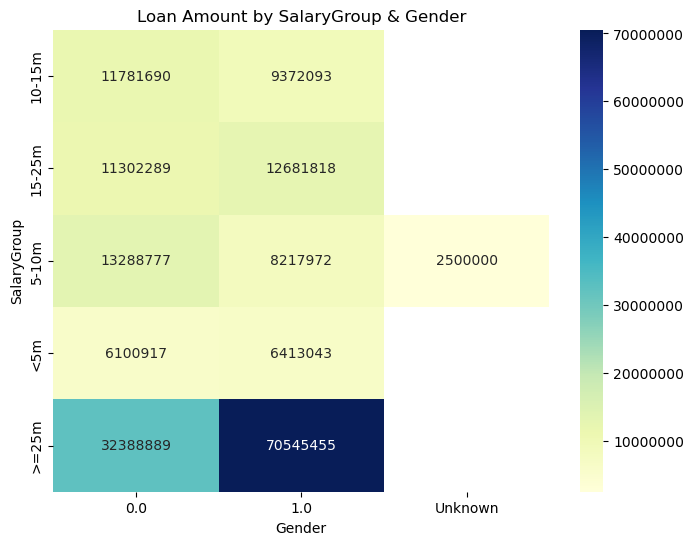

In [179]:
#Heatmap – Loan Amount by SalaryGroup vs Gender
plt.figure(figsize=(8,6))
hm=sns.heatmap(
    pivot_salary_gender_amount,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
cbar = hm.collections[0].colorbar
cbar.ax.ticklabel_format(style='plain')
plt.title("Loan Amount by SalaryGroup & Gender")
plt.xlabel("Gender")
plt.ylabel("SalaryGroup")
plt.show()

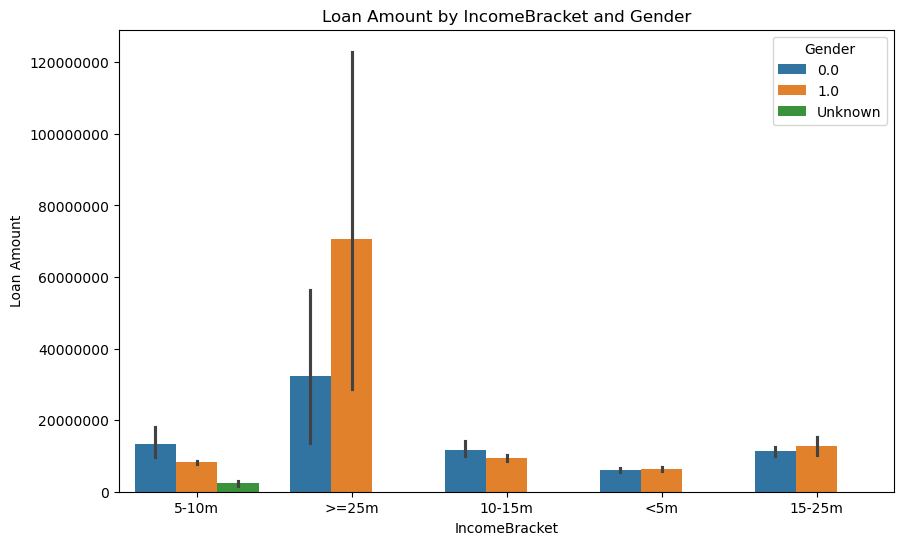

In [180]:
#Barplot– according to SalaryGroup, broken down by Gender
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x='IncomeBracket',
    y='Tiền giải ngân',
    hue='Gender',
    estimator='mean'
)
plt.title("Loan Amount by IncomeBracket and Gender")
plt.xlabel("IncomeBracket")
plt.ylabel("Loan Amount")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

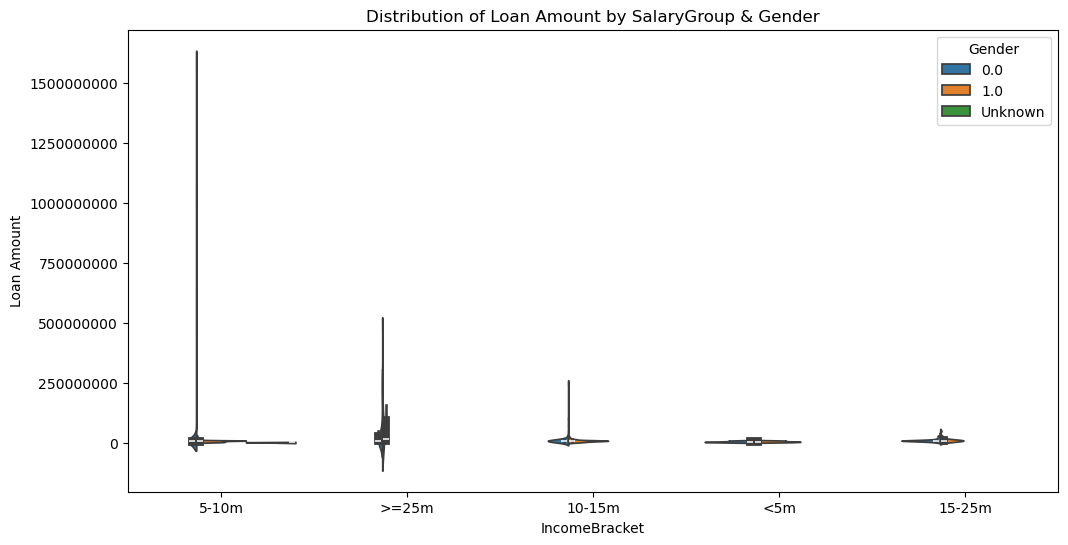

In [181]:
#Violin Plot – SalaryGroup vs Gender
plt.figure(figsize=(12,6))
sns.violinplot(
    data=df,
    x='IncomeBracket',
    y='Tiền giải ngân',
    hue='Gender',
    split=True
)
plt.title("Distribution of Loan Amount by SalaryGroup & Gender")
plt.xlabel("IncomeBracket")
plt.ylabel("Loan Amount")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

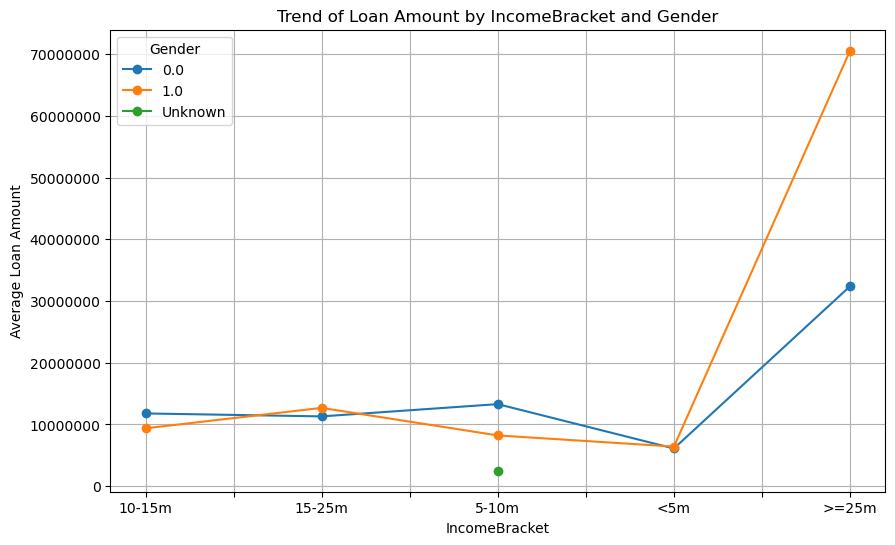

In [182]:
#Line chart – Trend of Loan Amount by IncomeBracket and Gender
pivot_salary_gender_amount.plot(kind='line', marker='o', figsize=(10,6))
plt.title("Trend of Loan Amount by IncomeBracket and Gender")
plt.xlabel("IncomeBracket")
plt.ylabel("Average Loan Amount")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight**

The relationship between income, gender, and loan size reveals an interesting picture: income remains the primary factor, but gender creates significant differences within each segment. Analysis by SalaryGroup combined with Gender shows a very clear trend: men borrow more than women across most income levels, but the difference isn't uniform across all groups—some are nearly equal, while others show significant disparities.

In the low-income group (<5M), loan amounts are the lowest as expected, and the difference between men and women is almost negligible (6.1M vs 6.4M). This reflects the fact that low-income groups typically only access small loan limits, with no significant gender differences. Both men and women in this segment exhibit relatively similar borrowing behavior, heavily reliant on financial capacity rather than demographic characteristics.

In the lower-middle income group (5–10M), men start borrowing at significantly higher rates than women (13.3M vs 8.2M). This segment shows the strongest disparity within the middle group, suggesting that men have greater borrowing needs or that the assessment model allows men to borrow at higher rates due to differing occupational characteristics/financial stability. The widening gap at lower incomes but decreasing at higher incomes is noteworthy: gender differences are not linear with salary.

In the 10–15M and 15–25M groups, borrowing rates between men and women become more similar (11.7M for men – 9.3M for women, and 11.3M for men – 12.6M for women). This is the most stable income range in the entire dataset, and also where gender influence is weakest. Notably, in the 15–25M segment, women even receive higher loan disbursements than men. This could reflect that in the group with stable income profiles, women are assessed as having better credit behavior (cleaner CIC ratio, more consistent payments), leading to potentially higher loan limits than men.

However, the polarization is strongest in the >=25M segment: women receive an average loan of over 70M, more than double that of men (around 32M). This is the biggest difference in the entire analysis and is not present in any other segment. This suggests that:

High-income women have better financial and behavioral profiles than high-income men.

Women tend to borrow larger amounts (or higher-value consumer loans).

Or the internal risk model favors higher loan limits for women in the high-income segment.

Conversely, high-income men borrow less than women in the same segment — contrary to the trend in the low and lower-middle income groups. Thus, the impact of gender shifts with income level: men dominate in borrowing at low-to-low-medium income levels, but women significantly outperform at high income levels.

=> Income remains the strongest factor determining loan limits; gender is merely a confounding factor within each segment.

**Salary vs Age vs Loan Amount (Tiền giải ngân)**


1. Which age group has the highest borrowing rates at each income level?

2. Do young people with low incomes borrow less than older people with the same income?

3. Do middle-aged individuals (36–45) borrow more than younger individuals?

5. Do those over 65 borrow less within the same SalaryGroup?

6. Are there any SalaryGroups where age doesn't make a difference?

7. Are there any anomalous segments (e.g., older people with low incomes but extremely high borrowing rates)?

In [183]:
pivot_age_salary_amount = df.pivot_table(
    index='AgeGroup',
    columns='IncomeBracket',
    values='Tiền giải ngân',
    aggfunc='mean'
).round(0)

pivot_age_salary_amount

IncomeBracket,10-15m,15-25m,5-10m,<5m,>=25m
AgeGroup,,,,,
18-25,9531915.0,11318182.0,7915816.0,5574627.0,7500000.0
26-35,9476695.0,12332000.0,11927515.0,6508547.0,63038462.0
36-45,15185841.0,11162448.0,13927638.0,7062500.0,43705882.0
46-55,9088235.0,13142857.0,19280000.0,7000000.0,8500000.0
56-65,NaN,5000000.0,9500000.0,NaN,NaN
Unknown,NaN,NaN,4500000.0,NaN,5000000.0


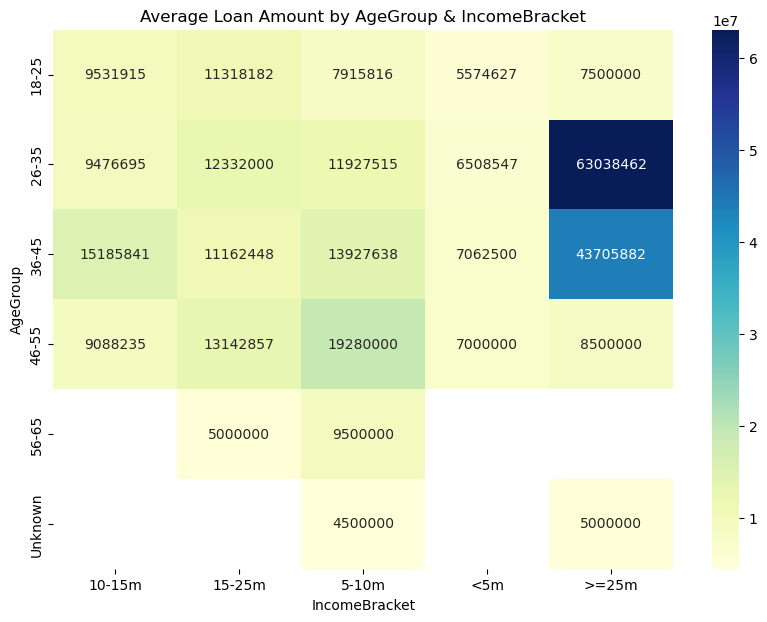

In [184]:
#Heatmap – Loan Amount (TienGiaiNgan) by AgeGroup vs IncomeBracket
plt.figure(figsize=(10,7))
sns.heatmap(
    pivot_age_salary_amount,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
plt.title("Average Loan Amount by AgeGroup & IncomeBracket")
plt.xlabel("IncomeBracket")
plt.ylabel("AgeGroup")
plt.show()

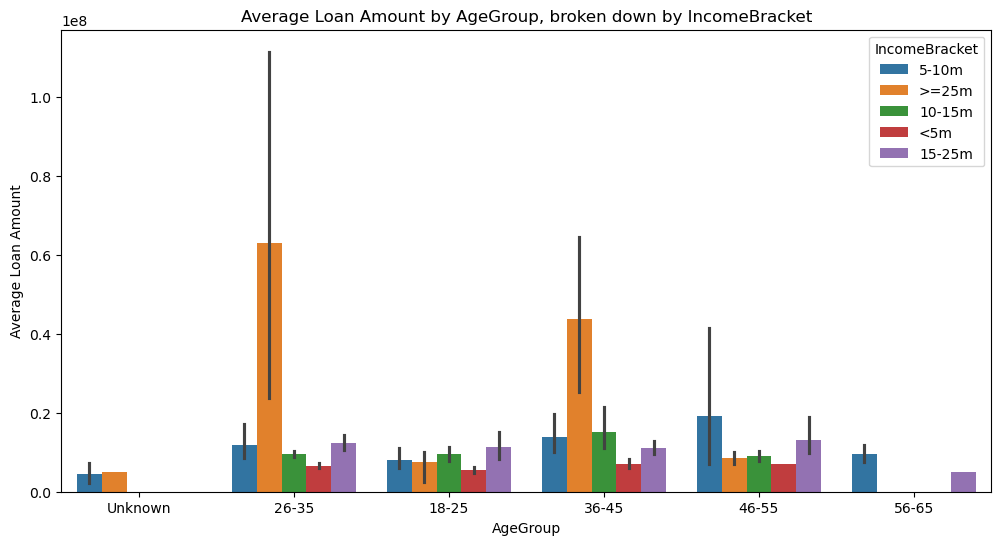

In [185]:
#Barplot – Loan Amount by AgeGroup, broken down by IncomeBracket
plt.figure(figsize=(12,6))
sns.barplot(
    data=df,
    x='AgeGroup',
    y='Tiền giải ngân',
    hue='IncomeBracket',
    estimator='mean'
)
plt.title("Average Loan Amount by AgeGroup, broken down by IncomeBracket")
plt.xlabel("AgeGroup")
plt.ylabel("Average Loan Amount")
plt.show()

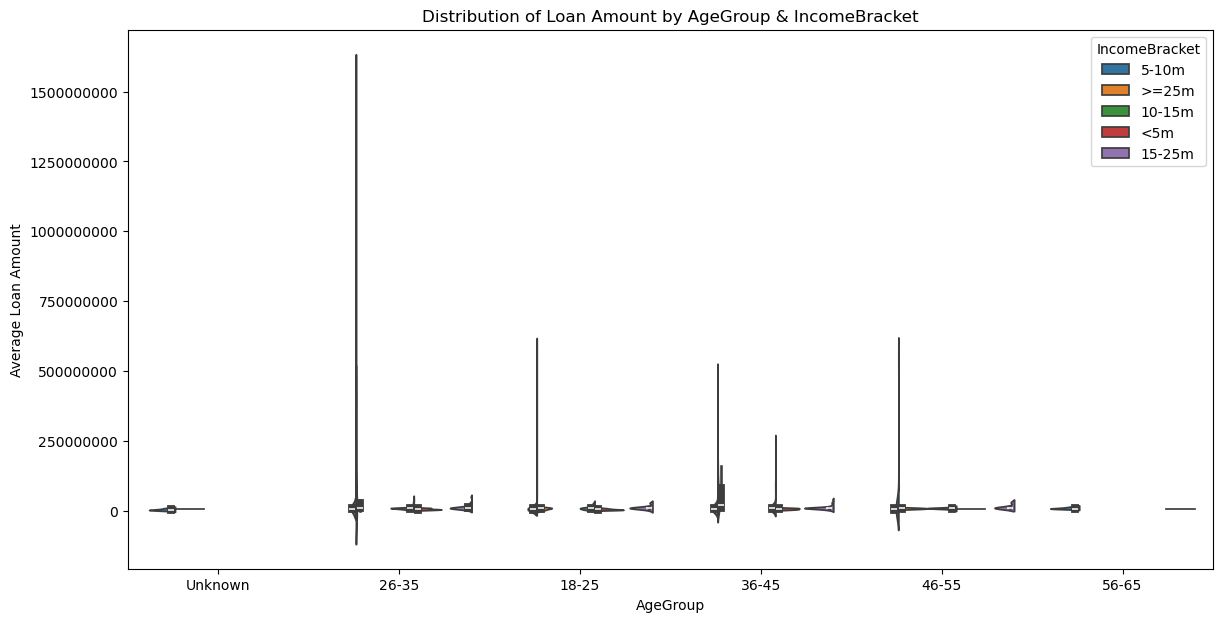

In [186]:
#Violin plot – Distribution of Loan Amount by AgeGroup × IncomeBracket
plt.figure(figsize=(14,7))
sns.violinplot(
    data=df,
    x='AgeGroup',
    y='Tiền giải ngân',
    hue='IncomeBracket',
    split=True
)
plt.title("Distribution of Loan Amount by AgeGroup & IncomeBracket")
plt.xlabel("AgeGroup")
plt.ylabel("Average Loan Amount")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

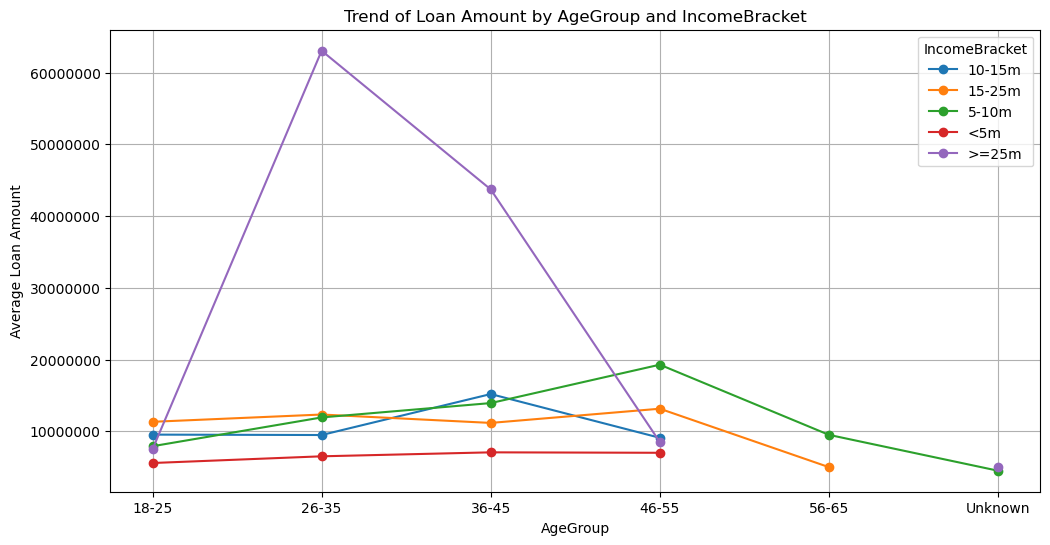

In [187]:
#Line chart – Trend of Loan Amount by AgeGroup and IncomeBracket
pivot_age_salary_amount.plot(kind='line', marker='o', figsize=(12,6))
plt.title("Trend of Loan Amount by AgeGroup and IncomeBracket")
plt.xlabel("AgeGroup")
plt.ylabel("Average Loan Amount")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight**

When analyzing income and age simultaneously, a fairly clear credit consumption pattern emerges. Across all income groups, middle-aged individuals (26–45) consistently have the largest loan amounts. This accurately reflects common financial behavior: this is the stage where consumption, investment, shopping, family building, home ownership, car ownership, and business ventures peak, and income is more stable compared to younger groups.

Meanwhile, younger individuals (18–25) tend to borrow less at the same income level. While some young people with relatively high incomes (10–15M or 15–25M) still borrow at a moderate level, they are generally constrained by two factors: (1) a thin credit history and (2) a lack of long-term income stability.

Conversely, older age groups (46–55) maintain high borrowing levels, especially in the low-to-middle income group, but begin to decline in the high-income group. This may reflect their greater caution with long-term debt or having largely met their major financial needs. By the 56–65 age group, borrowing limits have significantly decreased across most SalaryGroups, due to increased credit risk, declining financial health, and shorter income generation periods.

Most notably, the IncomeBracket variable has a stronger impact than the AgeGroup variable: regardless of age, high-income earners consistently borrow significantly more. The impact of age only creates differences within the same income level, not a complete reversal.

(1) Which age group borrows the most at each income level?

Observing the heatmap and pivot shows:

Income <5M → the 46–55 group borrows the most (around 7M).

5–10M --> The 46–55 age group has the highest borrowing (approximately 19M).

10–15M --> The 36–45 age group has the highest borrowing (approximately 15M).

15–25M --> The 36–45 and 46–55 age groups are roughly equal (approximately 13–14M).

=> 25M --> The 26–35 age group has the highest borrowing (approximately 63M).

-- Conclusion:
There is no single age group that dominates the overall picture; it depends on income level.

However, the 26–45 age group usually occupies the highest position.

(2) Do young people with low incomes borrow less than older people with the same income?

-- True.

The 18–25 age group always has the lowest borrowing in any IncomeBracket, unless the sample is very small (>=25M in the 56–65 age group).

Explanation:

Short credit history

Risk of job turnover

Lack of collateral

No major expenses (house, car, children)

(3) Do middle-aged groups (36–45) borrow more than younger groups?

- --> Very clear.

At all income levels from 10–25M and 5–10M, the 36–45 group is superior.

This is the group with high financial needs: buying a house, expanding a business, caring for family.

(4) Do groups >55 borrow less within the same SalaryGroup?

- --> Yes, except for high-income groups where data is missing.

The 56–65 age group has the lowest loan amounts in most IncomeBrackets because:

higher credit risk

shorter repayment periods

reduced credit limits due to the organization's risk policy

reduced high consumer demand

(5) Are there any SalaryGroups where age doesn't make a difference?

-- Yes: the <5M group.

At low income levels, financial constraints cause loan amounts to be quite close between age groups (5.5–7M).

=> Income plays the main limiting role, not age.

(6) Are there any unusual segments? (e.g., older age – lower salary but very high loan amounts)

Some unusual points:

The 46–55 / 5–10M group has an average loan amount of around 19M, far exceeding other groups --> possibly the home/business loan group.

The 26-35 / >=25M group has very high loan amounts (around 63M), making them extremely prominent.

The 36-45 / >=25M group has lower amounts (around 43M) --> possibly due to numerical bias or internal policies.

**Insight into Loan Size Driver Analysis:**

**INSIGHT**


Looking at the overall picture, the loan size for customers is not determined by a single factor, but rather by a combination of income, occupation, age, gender, and, to some extent, internal policies regarding loan limits.

First, occupation creates a very clear stratification. Stable occupations with clear legal status, such as "Other forms of self-employment," "State organization employees," "Permanent employees," or "Workers," receive average loan amounts of around 8-21 million VND, significantly higher than those with fluctuating incomes, such as "Employees without employment contracts," "Unregistered home-based businesses," or "Drivers," who typically borrow around 4-8 million VND. In other words, the more stable the occupation, the higher the loan limit, and this is one of the most important drivers of loan size.

Salary is a crucial factor: low-income customers (<5M) are almost always only eligible for small loans, with a narrow distribution. While incomes in the 5-25M range are increasing, average loan amounts remain relatively similar (around 11-12M), indicating a fairly flat credit limit policy for the middle-income segment. Only when moving into the high-income group (>=25M) does the loan amount "jump" to around 50M, with significant fluctuations. This suggests the organization is applying a "privileged income threshold" to expand credit limits, while the majority of middle-income customers – though secure – still borrow within a fairly similar range. Some particularly large outliers in the 5-10M group suggest that collateral or loan product type also strongly influences credit limits, not just nominal income.

Age reflects the credit demand cycle in a person's life. The 18-25 age group has the lowest borrowing amounts and few outliers, mainly due to weak income and a thin credit history. When entering the 26–35 and 36–45 age groups, loan amounts increase rapidly both in average and magnitude – this is the stage where customers build families, buy houses and cars, and expand their businesses. The 46–55 age group still has the highest average borrowing, but the number of loans may be lower; after age 55, loan limits decrease significantly due to income and health risks. When combined with gender, it can be seen that both men and women increase loan limits with age, but men tend to borrow more in the 26–55 age groups, especially men in the 46–55 age group – the highest borrowing segment. However, gender does not reverse the trend, but only "increases or decreases" the magnitude around the trend line with age.

When Gender is included with Salary, the picture becomes more detailed: in low and lower-middle income groups, men borrow more than women; but in the stable income range (10–25M), men and women are almost equal, and women in the 15–25M range even borrow slightly more. Specifically, in the very high income group (>=25M), women received an average of over 70M in loan disbursements – double that of men. This shows that gender is not the primary driver, but it influences loan limits across income segments: men dominate in the lower income segment, while women excel in the very high income segment – ​​possibly due to differences in financial profiles, loan products, or internal policies.

Finally, the Salary vs. Age analysis indicates that income remains the biggest driver, while age plays a role in "redistributing" loan limits within each income group. In any SalaryGroup, middle-aged individuals (26–45, sometimes 46–55) consistently borrow the most; younger people borrow less, and those over 55 face reduced loan limits. Some notable segments are 46–55 / 5–10M with an average loan amount of ~19M (very high relative to income) and 26–35 / >=25M with a loan amount of ~63M. These groups require further monitoring because they borrow heavily and are in an income/age range that is prone to financial shock.

In short, Loan Size is the result of a combination of financial capacity (Salary), job stability (JobName), life cycle (Age), and partly influenced by Gender, against the backdrop of internal credit limit policies and loan product characteristics.

**CONCLUSION – Factors Most Strongly Related to Loan Size**

From the overall analysis, the main Loan Size Drivers can be summarized as follows:

***Financial Capacity (Salary / IncomeBracket)***

This is the fundamental driver, determining the maximum loan amount a customer can access.

It has the strongest impact at the >=25M threshold, where the limit jumps to around 50–70M.

In the middle-income range (5–25M), the limit increases more slowly, reflecting policy limitations.

***Employment Stability (Job Name)***

Formal employment, contracts, working in the public sector, or established businesses --> allows for higher loan amounts.

Freelancers, those without employment contracts, or those working seasonally --> are limited in loan limits, borrowing smaller amounts and with narrower distribution.

This is one of the factors that best explains the difference in Loan Size between customers with similar income levels.

***Age Group***

Borrowing needs and capacity increase from 18–25 to a peak at 36–55, then decline at 56–65.

Within the same Salary Group, middle-aged individuals (26–45/55) borrow significantly more than younger and older individuals, due to both greater borrowing needs and a strong financial history.

***Gender – Adjusting Factor, Not the Determinant Factor***

Men borrow more in the low-to-lower middle income segment.

Women dominate in the very high income segment (>=25M).

Gender doesn't change the overall structure (high income – middle age – stable occupation remains the largest borrowing group), but it affects disparities within each segment.

***Product and Collateral Factors***

The emergence of very large loans in the 5-10M income group shows that Loan Size also depends on the value of collateral and the type of loan product.

**Financial Behavior**

**ProductCreditName vs Salary**

1. Which products are primarily aimed at low-income groups?

2. Which products are primarily aimed at middle-income groups (5–15M)?

3. Which products attract high-income groups (25M+)?

4. Are there any products that are popular and evenly distributed across salary groups?

In [188]:
pd.crosstab(df['ProductCreditName'], df['IncomeBracket'])

IncomeBracket,10-15m,15-25m,5-10m,<5m,>=25m
ProductCreditName,,,,,
Cầm Sim Số Đẹp,0,0,3,0,0
Cầm cố xe máy,80,39,354,20,14
Cầm cố xe máy KCC,44,16,85,13,2
Cầm cố Điện thoại,200,60,710,128,12
Cầm cố Điện thoại HK,38,24,170,11,7
Cầm ô tô,0,0,1,0,0
Unknown,0,0,0,0,1
Vay theo sim,41,9,218,29,1
Vay trực tuyến qua Sim,0,0,5,0,0


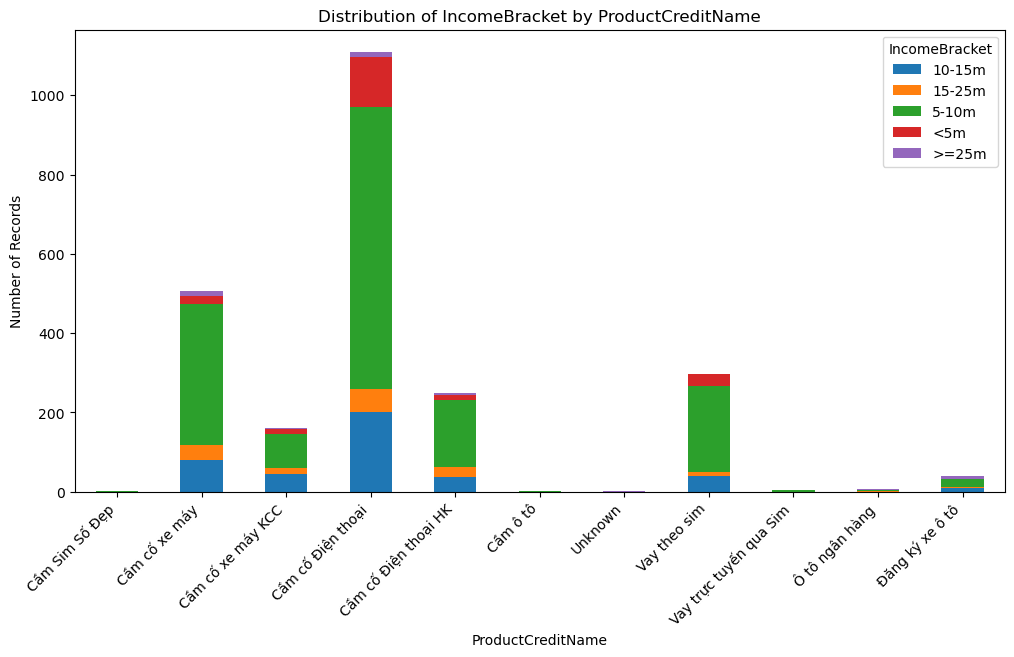

In [189]:
#Stacked Bar Chart – ProductCreditName by IncomeBracket
df_crosstab = pd.crosstab(df['ProductCreditName'], df['IncomeBracket'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Distribution of IncomeBracket by ProductCreditName")
plt.xlabel("ProductCreditName")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha='right')
plt.legend(title="IncomeBracket")
plt.show()


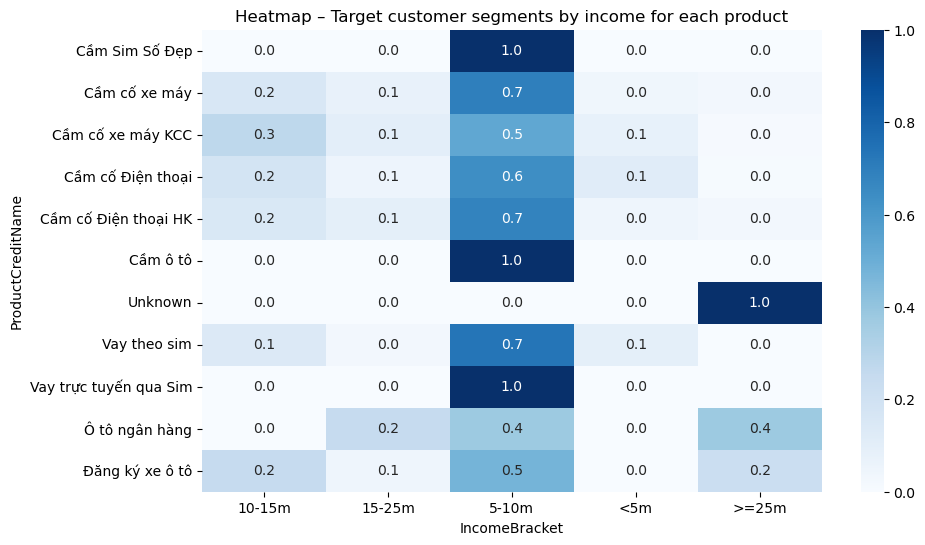

In [190]:
#Heatmap – Target customer segments by income for each product.
plt.figure(figsize=(10,6))
sns.heatmap(
    df_crosstab.apply(lambda x: x / x.sum(), axis=1),
    annot=True,
    fmt=".1f",
    cmap="Blues"
)
plt.title("Heatmap – Target customer segments by income for each product")
plt.xlabel("IncomeBracket")
plt.ylabel("ProductCreditName")
plt.show()

**Insight**

Analysis of the relationship between credit products and income groups reveals that each product in TIMA's portfolio attracts a very different income segment. This clearly reflects the product strategy and actual customer behavior: products requiring high-value assets target high- or upper-middle-income groups; while products requiring collateral with low-value assets are almost exclusively geared towards low- and lower-middle-income groups.

Overall, the stacked bar chart shows that the 5–10 million VND income segment dominates most products, from phone and motorbike collateral loans to SIM card-based loans. This indicates that the lower-middle-income group is TIMA's core customer base—large in number, with high short-term loan needs, and well-suited to micro-loan products. However, when considering the distribution by weight (heatmap by row), the picture of borrowing behavior becomes more clearly stratified.

Pawning products involving mobile phones (Pawning Mobile Phones & HK Mobile Phones) primarily attract customers with loans of 5–10 million VND (60–70%), followed by the 10–15 million VND group. This is reasonable because mobile phones have a low value, are easy to pawn, and are suitable for customers needing quick, small, short-term loans. High-income groups almost never use this type of product, reflecting the suitability between needs and the value of the collateral.

Pawning motorbikes and KCC motorbikes has a wider distribution: the 5–10 million VND group still accounts for a large proportion (50–70%), but the 10–15 million VND and 15–25 million VND groups contribute significantly more than mobile phone products. This reflects higher asset values ​​→ larger loan amounts → suitable for customers with more stable incomes. The group with incomes of 25 million VND or more accounts for only a very small proportion (approximately 1-2%), indicating that high-income customers hardly use these small-scale collateral products.

Conversely, products such as car loans, vehicle registration, or car loans attract significantly higher-income groups. The heatmap shows a dominant proportion of the 25 million VND and 15-25 million VND groups, especially in the "Vehicle Registration" product (the 25 million VND group accounts for up to 20%). This aligns with expectations: only high-income customers or those with valuable assets use car collateral services or related asset loans.

Some products exhibit specific behaviors:

Loans based on SIM cards: strongly attract the 5-10 million VND group (70%) and the <5 million VND group (~10%), indicating that this product caters to the small, quick needs of the low-income segment.

Online loans via SIM card: even more concentrated almost entirely in the 5-10 million VND group (approximately 100%) — reflecting a group of young, low-income customers with few assets and urgent borrowing needs.

Overall, the relationship between product and income clearly demonstrates financial logic: asset value --> loan size --> suitable for the corresponding income group. Low-income customers need small loans and use small assets as collateral; high-income customers need larger loans and use correspondingly high-value assets. However, is TIMA missing out on the high-income segment with its unsecured loan products, which are currently almost 100% focused on the 5-10 million VND segment? This could be an opportunity to expand products to the high-income segment with larger value unsecured loan services.

**ProductCreditName vs JobName**

1. Which occupations borrow the most from which product?

2. Do factory workers/drivers use risky products?

3. Which products are suitable for office workers (full-time employees)?

4. Are there any products that are mismatched between actual customers and target groups?

In [191]:
top_jobs = df['JobName'].value_counts().head(10).index
df_top_jobs = df[df['JobName'].isin(top_jobs)]

In [192]:
pd.crosstab(df_top_jobs['ProductCreditName'], df_top_jobs['JobName'])

JobName,Các hình thức tự kinh doanh khác,Công nhân,Khác,Kinh doanh,Kinh doanh tại nhà (không có đăng ký kinh doanh),Nhân viên chính thức,Nhân viên không có HĐLĐ,Nhân viên tổ chức nhà nước,Tài xế,Tự doanh tại nhà
ProductCreditName,,,,,,,,,,
Cầm Sim Số Đẹp,0,0,2,0,1,0,0,0,0,0
Cầm cố xe máy,30,8,135,20,11,114,11,5,12,19
Cầm cố xe máy KCC,16,0,24,7,7,55,3,1,7,15
Cầm cố Điện thoại,33,31,70,30,7,666,0,61,16,21
Cầm cố Điện thoại HK,28,0,47,11,13,90,8,2,8,14
Unknown,0,0,0,0,0,1,0,0,0,0
Vay theo sim,18,10,19,1,14,149,53,3,7,8
Vay trực tuyến qua Sim,0,0,5,0,0,0,0,0,0,0
Ô tô ngân hàng,2,0,0,0,0,5,0,0,0,0


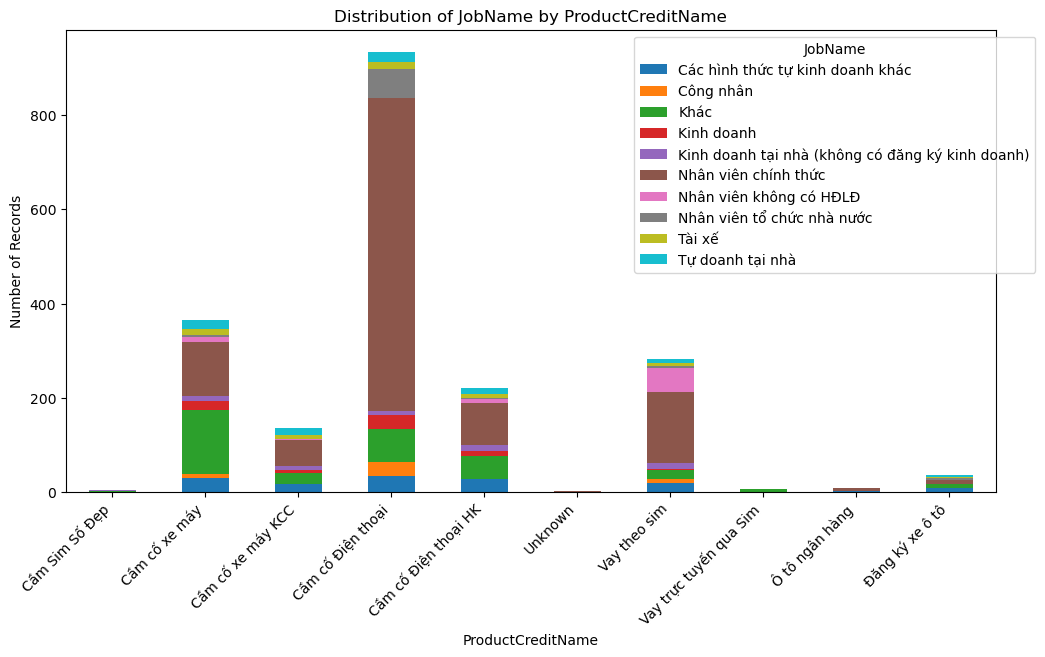

In [193]:
#Stacked Bar Chart – ProductCreditName by JobName
df_crosstab_job = pd.crosstab(df_top_jobs['ProductCreditName'], df_top_jobs['JobName'])

df_crosstab_job.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Distribution of JobName by ProductCreditName")
plt.xlabel("ProductCreditName")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha='right')
plt.legend(title="JobName", bbox_to_anchor=(1.05, 1))
plt.show()

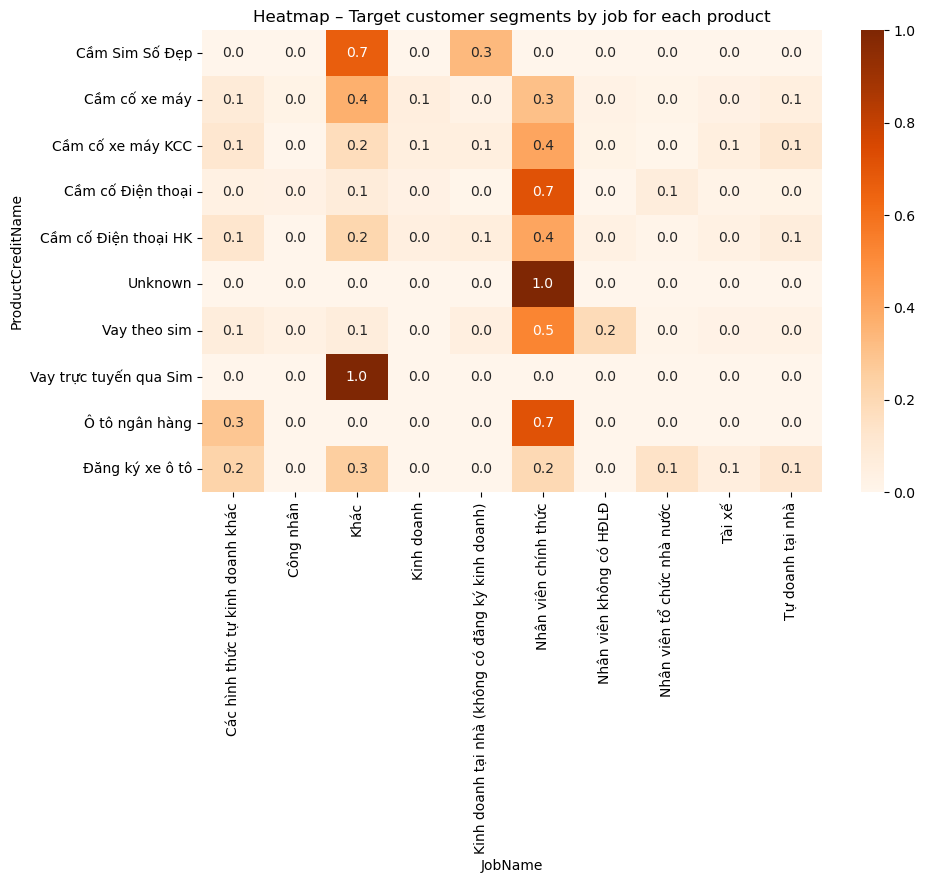

In [194]:
#Heatmap – JobName by ProductCreditName (Top 10 Jobs)
plt.figure(figsize=(10,6))
sns.heatmap(
    df_crosstab_job.apply(lambda x: x / x.sum(), axis=1),
    annot=True,
    fmt=".1f",
    cmap="Oranges"
)
plt.title("Heatmap – Target customer segments by job for each product")
plt.xlabel("JobName")
plt.ylabel("ProductCreditName")
plt.show()

**Insight**

Analysis of the relationship between occupation and credit products reveals that TIMA's product portfolio is closely tied to the specific economic and financial characteristics of each occupational group, with a very clear stratification of borrowing needs, the ability to use collateral, and product selection behavior.

Looking at the crosstab and stacked bar chart, it can be seen that phone and motorbike collateral loans are the two main products in the entire portfolio, but their distribution by occupation is very different. "Phone collateral loans" strongly attract office workers, factory workers, and employees—groups with stable but not high incomes, who often choose to collateralize easily accessible consumer assets. The proportion of "Official Employees" and "Workers" in this product is large, accurately reflecting the reality: these groups tend to borrow quickly, in small amounts, and for short-term financial purposes.

Meanwhile, "Motorcycle Pawning" is more widely distributed among Business Owners, Home-Based Businesses, and Self-Employed Individuals. These are occupational groups with seasonal income fluctuations, often requiring medium-sized loans for short-term financing. Motorcycles are common and more valuable assets than mobile phones, fitting the slightly larger borrowing needs of this group. This reinforces the previous insight: self-employed individuals use assets more flexibly and rely more on pawning than salaried employees.

A notable point is that the "Loan via SIM Card" and "Online Loan via SIM Card" products attract almost exclusively the group of employees without employment contracts, drivers, and freelancers. The heatmap shows that the percentage of customers in this occupational group in some product lines is nearly 100%. This clearly reflects the specific situation: high-risk occupations, those with unstable incomes, and lacking valuable collateral often only have access to high-risk unsecured loans or "consumer behavior loans" such as telecommunication SIM cards. This group has low credit limits and high risk—a logical conclusion consistent with previous LoanStatus and Credit Score analyses.

Conversely, premium products like "Vehicle Registration" or "Car Financing" primarily attract government employees, formal business owners, or those with more stable incomes and social status. These products are almost non-existent among self-employed individuals or high-risk groups, reflecting the very strict credit limit control policies based on collateral. Car financing is unique and requires income transparency, therefore only certain occupations can meet the requirements.

Furthermore, the "Pawning a Premium Phone Number" option appears sporadically in the "Other" group and has virtually no actual customers — possibly because it's a product that's rarely used or outdated in the product category. Similarly, the "Unknown" option appears in only a few scattered records — most likely due to data entry errors or an outdated product no longer in use.

Overall, the relationship between JobName and ProductCreditName clearly reflects actual borrowing behavior:

Stable occupations (full-time employees, factory workers) --> prefer pawning small assets (phones, motorbikes).

Freelancers – high risk --> focus on "loans secured by phone numbers".

High-income groups – clearly defined occupations --> use products related to automobiles.

Business owners --> use a wider variety of pawning products involving more valuable assets (motorcycles, phones, etc.).

This structure also perfectly matches the risk stratification approach in Credit Score and LoanStatus analysis, demonstrating that product selection is an important credit behavior indicator and can be used in risk forecasting or customer segmentation modeling.

**BUILDING A PREDICTIVE MODEL (inclined toward rule-based label learning)**

**1. The problem and the objective variable**

--> Problem: Predicting Customer Credit Risk Classification

**1.1. Problem Objective**

The chosen problem is to predict the level of credit risk classification of customers based on the following information:

- Financial profile: income, loan limit, loan-to-income ratio (LoanToIncomeRatio)

- Internal credit score (TS_CREDIT_SCORE_V2)

- Bad debt history

- Demographics: age, gender

- Occupation

- Credit products and borrowing behavior

--> Output: Predict the customer's Risk_Level according to 3 risk groups.

High: If the credit score (TS_CREDIT_SCORE_V2) is below 500 and the customer has a history of bad debt (HasBadDebt = 1).

Average: If the credit score (TS_CREDIT_SCORE_V2) is between 500 and 700 and there are no bad debts.

Low: If the credit score (TS_CREDIT_SCORE_V2) is above 700 and there are no bad debts.

Business Significance: Supports the appraisal and risk management departments in predicting the likelihood of customers becoming high-risk/prone to bad debt in order to:

- Adjust loan limits

- Adjust interest rate policies

- Automatically alert high-risk profiles

- Optimize appraisal performance

In [195]:
#Create Risk_Level
import numpy as np
import pandas as pd

def assign_risk_level(row):
    score = row["TS_CREDIT_SCORE_V2"]
    bad = row["HasBadDebt"]

    if score < 500 and bad == 1:
        return "Cao (High)"
    elif 500 <= score <= 700 and bad == 0:
        return "Trung bình (Medium)"
    elif score > 700 and bad == 0:
        return "Thấp (Low)"
    else:
        return "Cao (High)"  # The remaining group: prioritizes safety/high risk.

df["Risk_Level"] = df.apply(assign_risk_level, axis=1)

print(df[['TS_CREDIT_SCORE_V2','HasBadDebt','Risk_Level']].head(20))



    TS_CREDIT_SCORE_V2  HasBadDebt           Risk_Level
0                  403           0           Cao (High)
1                  403           0           Cao (High)
2                  531           0  Trung bình (Medium)
3                  588           0  Trung bình (Medium)
4                  675           0  Trung bình (Medium)
5                  675           0  Trung bình (Medium)
6                  582           0  Trung bình (Medium)
7                  522           0  Trung bình (Medium)
8                  483           0           Cao (High)
9                  595           1           Cao (High)
10                 595           1           Cao (High)
11                 647           0  Trung bình (Medium)
12                 670           0  Trung bình (Medium)
13                 564           0  Trung bình (Medium)
14                 472           0           Cao (High)
15                 540           0  Trung bình (Medium)
16                 540           0  Trung bình (

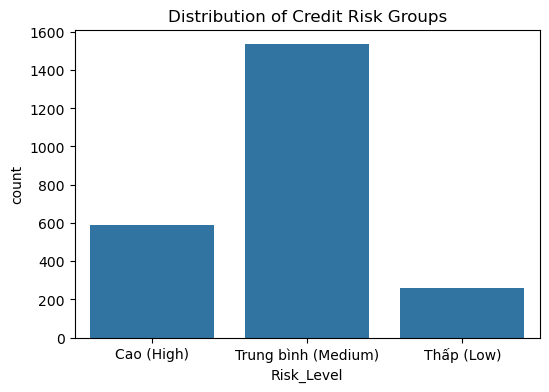

In [196]:
#Examine the distribution of risk groups
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Risk_Level', order=['Cao (High)','Trung bình (Medium)','Thấp (Low)'])
plt.title("Distribution of Credit Risk Groups")
plt.show()

**Selecting Input Variables & Preparing Data for the Model**

- Log-transform Disbursement to reduce skew

- Monetary variables like Disbursement are often skewed (severely to the right):

Log-transform to:

1. Reduce the impact of outliers

A loan of 150,000,000 no longer breaks the scale compared to a loan of 10,000,000.

2. The distribution becomes closer to normal (Gaussian)

--> good for most classification algorithms.

3. The relationship with the target variable is clearer

For example: Risk_Level usually increases with the log of the loan, not with the original value.

4. Increase model stability

Reduce model overlearning in very large loans.

In [197]:
df['Loan_log'] = np.log1p(df['Tiền giải ngân'])


In [198]:
selected_features = [
    # Numeric
    "TS_CREDIT_SCORE_V2",
    "HasBadDebt",
    "Salary",
    "LoanToIncomeRatio",
    "Loan_log",
    "HasLatePayment",
    "LoanTermMonths",
    "NumberOfLoans",

    # Categorical (will be encoded)
    'IncomeBracket', 'JobName', 'ProductCreditName', 'Hình thức cư trú', 'AgeGroup', 'CityName', 'Gender'
]

In [199]:
X_raw = df[selected_features].copy()

In [200]:
y = df['Risk_Level']

In [201]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

num_cols = ["TS_CREDIT_SCORE_V2", "HasBadDebt", "Salary", "LoanToIncomeRatio", "Loan_log", "HasLatePayment", "LoanTermMonths", "NumberOfLoans"]
cat_cols = ['IncomeBracket', 'JobName', 'ProductCreditName', 'Hình thức cư trú', 'AgeGroup', 'CityName', 'Gender']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

#One-hot encoding for categorical features
X_train = pd.get_dummies(X_train_raw, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test_raw, columns=cat_cols, drop_first=True)

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

# Scale numeric features
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [202]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

# General evaluation function for the models
def evaluate_model(name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    print(f"\n{'=' * 10} MODEL RESULT: {name} {'=' * 10}")
    
    train_acc = accuracy_score(y_train_true, y_train_pred)
    train_f1 = f1_score(y_train_true, y_train_pred, average='macro')
    print("--- TRAIN ---")
    print("Train Accuracy :", round(train_acc, 4))
    print("Train F1 macro :", round(train_f1, 4))
    
    
    test_acc = accuracy_score(y_test_true, y_test_pred)
    test_f1 = f1_score(y_test_true, y_test_pred, average='macro')
    test_f1_wght = f1_score(y_test_true, y_test_pred, average='weighted')
    print("\n--- TEST ---")
    print("Test Accuracy  :", round(test_acc, 4))
    print("Test F1 macro  :", round(test_f1, 4))
    print("Test F1 weighted:", round(test_f1_wght, 4))
    
    #Classification Report on Test set
    print("\nClassification report (Test):")
    print(classification_report(y_test_true, y_test_pred, zero_division=0))

    # 4. Confusion matrix (Test)
    cm = confusion_matrix(y_test_true, y_test_pred, labels=['Cao (High)','Trung bình (Medium)','Thấp (Low)'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Cao (High)','Trung bình (Medium)','Thấp (Low)'])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap="Blues", values_format='d', ax=ax)
    plt.title(f"Confusion Matrix (Test) – {name}")
    plt.show()

**MODELLING**

For this assignment, we selected Multinomial Logistic Regression (more than 2 labels), Random Forest, and XGBoost because they form a strong and practical progression for multiclass risk prediction on tabular data. 

Multinomial Logistic Regression is a clear baseline: it is fast, interpretable, and helps us understand how well a simple linear decision boundary performs. 

Random Forest is then used to capture non-linear patterns and feature interactions that logistic models may miss, while remaining robust and relatively stable. 

Finally, XGBoost is included as a high-performance boosting model that typically delivers the best predictive accuracy on structured datasets by learning hard cases iteratively and controlling overfitting with regularization. Using these three models together lets us compare interpretability, robustness, and peak performance, then choose the most suitable model based on both metrics and business goals.

**Logistic Regression (Multinomial)**

In [203]:
pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.



========== MODEL RESULT: Logistic Regression (Multinomial) ==========
--- TRAIN ---
Train Accuracy : 0.9722
Train F1 macro : 0.9578

--- TEST ---
Test Accuracy  : 0.9727
Test F1 macro  : 0.9569
Test F1 weighted: 0.9738

Classification report (Test):
                     precision    recall  f1-score   support

         Cao (High)       0.99      1.00      1.00       118
         Thấp (Low)       0.81      1.00      0.90        52
Trung bình (Medium)       1.00      0.96      0.98       307

           accuracy                           0.97       477
          macro avg       0.93      0.99      0.96       477
       weighted avg       0.98      0.97      0.97       477



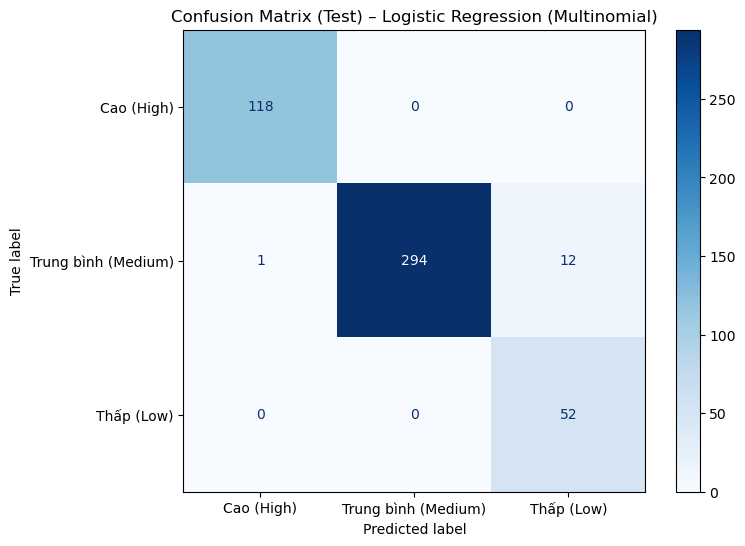

In [204]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression multinomial with class_weight='balanced' to handle class imbalance
log_reg = LogisticRegression(
    solver='lbfgs',
    max_iter=10000,
    class_weight='balanced', 
    random_state=42
)

#Train
log_reg.fit(X_train, y_train)

y_pred_train_lr = log_reg.predict(X_train)

# Predict on the test set
y_pred_lr = log_reg.predict(X_test)

# Evaluate the model
evaluate_model("Logistic Regression (Multinomial)", y_train, y_pred_train_lr, y_test, y_pred_lr)


**Random Forest Classifier**


========== MODEL RESULT: Random Forest ==========
--- TRAIN ---
Train Accuracy : 0.883
Train F1 macro : 0.8955

--- TEST ---
Test Accuracy  : 0.9287
Test F1 macro  : 0.9328
Test F1 weighted: 0.9283

Classification report (Test):
                     precision    recall  f1-score   support

         Cao (High)       0.87      0.84      0.85       118
         Thấp (Low)       1.00      1.00      1.00        52
Trung bình (Medium)       0.94      0.95      0.94       307

           accuracy                           0.93       477
          macro avg       0.94      0.93      0.93       477
       weighted avg       0.93      0.93      0.93       477



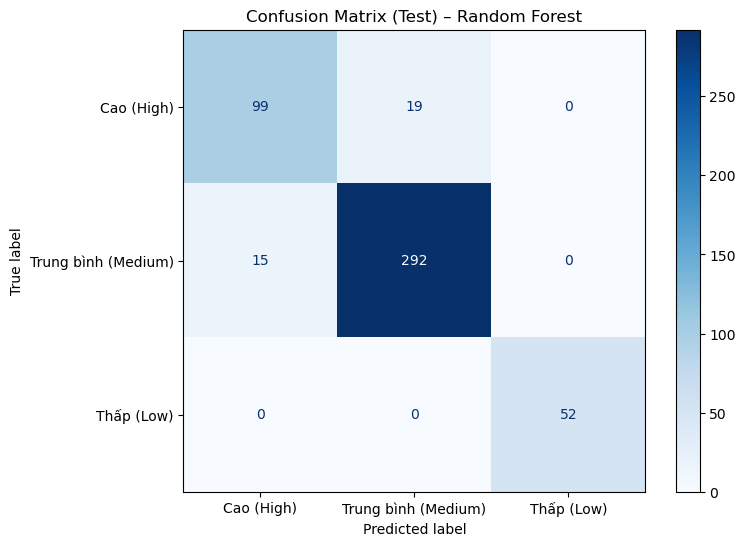


Top 15 feature importances of Random Forest:
TS_CREDIT_SCORE_V2                     0.435900
HasBadDebt                             0.174266
NumberOfLoans                          0.141485
Loan_log                               0.032123
CityName_Hồ Chí Minh                   0.026884
Gender_1.0                             0.023306
Salary                                 0.020006
LoanTermMonths                         0.018055
LoanToIncomeRatio                      0.017670
CityName_Hà Nội                        0.013761
HasLatePayment                         0.011306
ProductCreditName_Vay theo sim         0.010376
ProductCreditName_Cầm cố xe máy        0.008709
ProductCreditName_Cầm cố Điện thoại    0.006386
IncomeBracket_<5m                      0.006325
dtype: float64


In [205]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=200,          
    max_depth=5,     
    min_samples_split=40,
    min_samples_leaf=20,
    max_features='sqrt',
    class_weight='balanced_subsample',  
    random_state=42,
    n_jobs=-1              
)

# Train
rf_clf.fit(X_train, y_train)

y_pred_train_rf = rf_clf.predict(X_train)

# Predict on the test set
y_pred_rf = rf_clf.predict(X_test)

# Evaluate the model
evaluate_model("Random Forest", y_train, y_pred_train_rf, y_test, y_pred_rf)

#Top 15 important features of Random Forest
feature_importances = pd.Series(
    rf_clf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 15 feature importances of Random Forest:")
print(feature_importances.head(15))


**XGBoost**

In [206]:
# Create copies of the training and test sets for XGBoost, since XGBoost may have issues with certain characters in column names.
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()


def clean_xgb_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)            # all is string
                  .str.replace('[', '', regex=False)
                  .str.replace(']', '', regex=False)
                  .str.replace('<', 'lt_', regex=False)
                  .str.replace('>', 'gt_', regex=False)
    )
    return df


X_train_xgb = clean_xgb_columns(X_train_xgb)
X_test_xgb = clean_xgb_columns(X_test_xgb)


In [207]:
#Check if the indices of the new X_train_xgb and X_test_xgb match with the original X_train and X_test, and also with y_train and y_test.
assert X_train_xgb.index.equals(X_train.index)
assert X_test_xgb.index.equals(X_test.index)
assert y_train.index.equals(X_train.index)
assert y_test.index.equals(X_test.index)


In [208]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)


In [209]:
pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.



========== MODEL RESULT: XGBoost Baseline ==========
--- TRAIN ---
Train Accuracy : 1.0
Train F1 macro : 1.0

--- TEST ---
Test Accuracy  : 1.0
Test F1 macro  : 1.0
Test F1 weighted: 1.0

Classification report (Test):
                     precision    recall  f1-score   support

         Cao (High)       1.00      1.00      1.00       118
         Thấp (Low)       1.00      1.00      1.00        52
Trung bình (Medium)       1.00      1.00      1.00       307

           accuracy                           1.00       477
          macro avg       1.00      1.00      1.00       477
       weighted avg       1.00      1.00      1.00       477



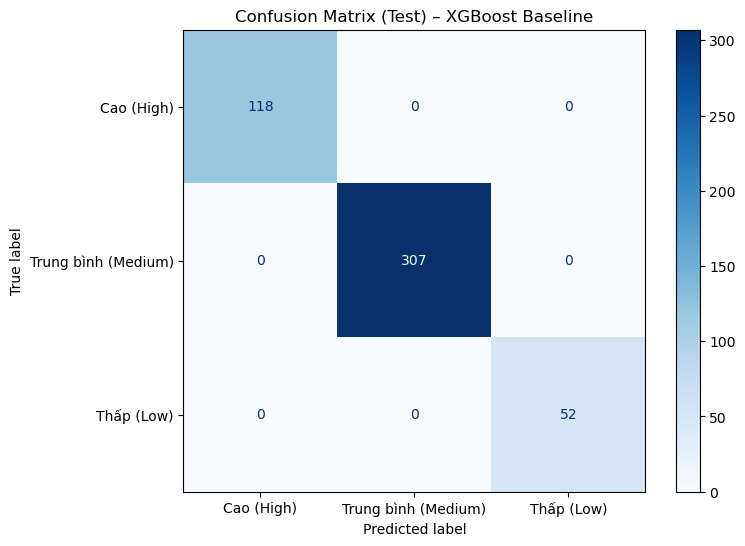

In [210]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=20,
    gamma=2, 
    objective='multi:softprob',   # softprob hoặc softmax
    eval_metric='mlogloss',
    tree_method="hist",
    random_state=42
)

# Train
xgb_clf.fit(X_train_xgb, y_train_enc)

# Predict on the training and test sets (The results are in the form of 0, 1, 2, 3)
y_pred_train_enc = xgb_clf.predict(X_train_xgb)
y_pred_test_enc = xgb_clf.predict(X_test_xgb)

# Convert the encoded predictions back to the original labels for evaluation
# Train
y_train_true_xgb = le.inverse_transform(y_train_enc)
y_train_pred_xgb = le.inverse_transform(y_pred_train_enc)

# Test
y_test_true_xgb = le.inverse_transform(y_test_enc)
y_test_pred_xgb = le.inverse_transform(y_pred_test_enc)

# Evaluate
evaluate_model("XGBoost Baseline", y_train_true_xgb, y_train_pred_xgb, y_test_true_xgb, y_test_pred_xgb)


**Fine-tunning with RamdomizedSearchCV**

In [211]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import numpy as np

**Optimizing Logistics Regression using RandomizedSearchCV**

Best Logistic params: {'penalty': 'l2', 'C': np.float64(1.0)}
Best Logistic CV f1_macro: 0.9332

========== MODEL RESULT: Logistic Regression - Tuned ==========
--- TRAIN ---
Train Accuracy : 0.9722
Train F1 macro : 0.9578

--- TEST ---
Test Accuracy  : 0.9727
Test F1 macro  : 0.9569
Test F1 weighted: 0.9738

Classification report (Test):
                     precision    recall  f1-score   support

         Cao (High)       0.99      1.00      1.00       118
         Thấp (Low)       0.81      1.00      0.90        52
Trung bình (Medium)       1.00      0.96      0.98       307

           accuracy                           0.97       477
          macro avg       0.93      0.99      0.96       477
       weighted avg       0.98      0.97      0.97       477



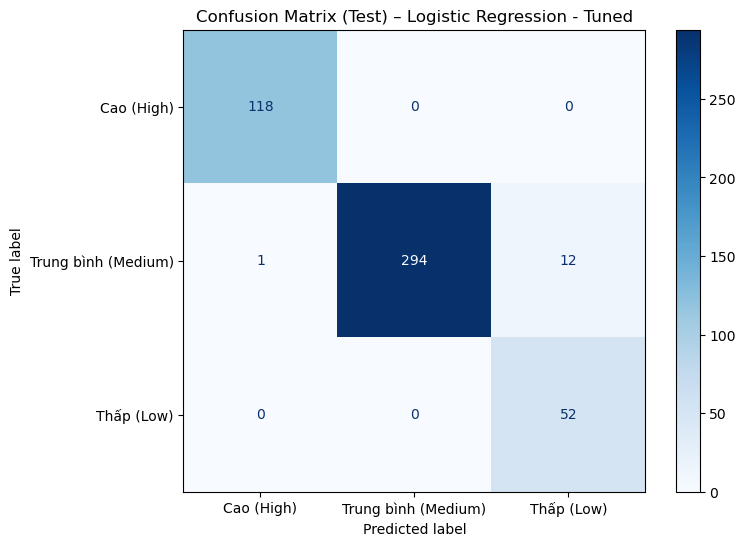

In [212]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

log_param_dist = {
    "C": np.logspace(-3, 0, 10),
    "penalty": ["l2"]
}

log_clf = LogisticRegression(
    solver="lbfgs",
    max_iter=10000,
    class_weight="balanced",
    n_jobs=-1
)

log_random_search = RandomizedSearchCV(
    estimator=log_clf,
    param_distributions=log_param_dist,
    n_iter=10,
    scoring="f1_macro",
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

log_random_search.fit(X_train, y_train)

y_pred_train_log_best = log_random_search.predict(X_train)

print("Best Logistic params:", log_random_search.best_params_)
print("Best Logistic CV f1_macro:", round(log_random_search.best_score_, 4))

best_log = log_random_search.best_estimator_

y_pred_log_best = best_log.predict(X_test)

evaluate_model("Logistic Regression - Tuned", y_train, y_pred_train_log_best, y_test, y_pred_log_best)

**Optimizing RandomizedSearchCV for Random Forest**

Best RF params: {'bootstrap': True, 'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 17, 'min_samples_split': 40, 'n_estimators': 199}
Best RF CV f1_macro: 0.9897

========== MODEL RESULT: Random Forest - Tuned ==========
--- TRAIN ---
Train Accuracy : 0.9953
Train F1 macro : 0.9897

--- TEST ---
Test Accuracy  : 0.9937
Test F1 macro  : 0.9864
Test F1 weighted: 0.9938

Classification report (Test):
                     precision    recall  f1-score   support

         Cao (High)       1.00      0.97      0.99       118
         Thấp (Low)       0.95      1.00      0.97        52
Trung bình (Medium)       1.00      1.00      1.00       307

           accuracy                           0.99       477
          macro avg       0.98      0.99      0.99       477
       weighted avg       0.99      0.99      0.99       477



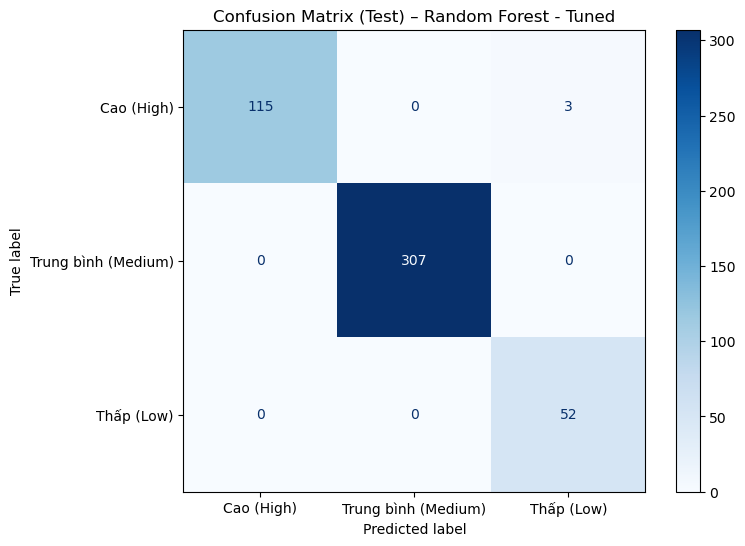

In [213]:
from scipy.stats import randint

rf_param_dist = {
    "n_estimators": randint(100, 400),
    "max_depth": randint(3, 9),
    "min_samples_split": randint(20, 50),
    "min_samples_leaf": randint(10, 25),
    "max_features": ["sqrt", "log2", 0.5],
    "bootstrap": [True]
}

rf_clf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_random_search = RandomizedSearchCV(
    estimator=rf_clf,
    param_distributions=rf_param_dist,
    n_iter=60,                  
    scoring="f1_macro",
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

y_pred_train_rf_best = rf_random_search.predict(X_train)

print("Best RF params:", rf_random_search.best_params_)
print("Best RF CV f1_macro:", round(rf_random_search.best_score_, 4))

# Best model after tuning
best_rf = rf_random_search.best_estimator_

# Predict on the test set with the best RF model
y_pred_rf_best = best_rf.predict(X_test)
evaluate_model("Random Forest - Tuned", y_train, y_pred_train_rf_best, y_test, y_pred_rf_best)


**Optimizing RandomizedSearchCV for XGBoost**

Best XGB params: {'colsample_bytree': np.float64(0.8123620356542087), 'gamma': 1, 'learning_rate': np.float64(0.021006087391969828), 'max_depth': 2, 'min_child_weight': 9, 'n_estimators': 182, 'reg_alpha': 0.1, 'reg_lambda': 20, 'subsample': np.float64(0.7299924747454009)}
Best XGB CV f1_macro: 1.0

========== MODEL RESULT: XGBoost – Tuned ==========
--- TRAIN ---
Train Accuracy : 1.0
Train F1 macro : 1.0

--- TEST ---
Test Accuracy  : 1.0
Test F1 macro  : 1.0
Test F1 weighted: 1.0

Classification report (Test):
                     precision    recall  f1-score   support

         Cao (High)       1.00      1.00      1.00       118
         Thấp (Low)       1.00      1.00      1.00        52
Trung bình (Medium)       1.00      1.00      1.00       307

           accuracy                           1.00       477
          macro avg       1.00      1.00      1.00       477
       weighted avg       1.00      1.00      1.00       477



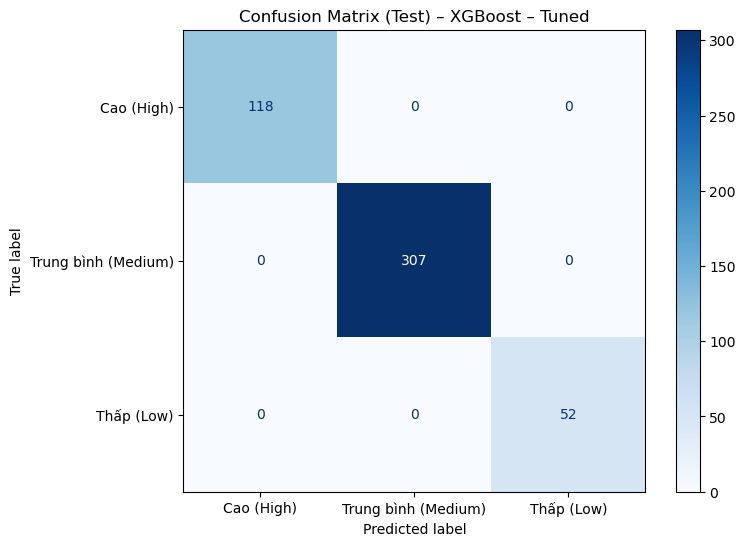

In [214]:
from scipy.stats import uniform

xgb_param_dist = {
    "n_estimators": randint(80, 200),
    "max_depth": randint(2, 5),
    "learning_rate": uniform(0.01, 0.06),
    "subsample":  uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "min_child_weight": randint(5, 20),
    "gamma": [1, 2, 5],
    "reg_lambda": [5, 10, 20],
    "reg_alpha": [0, 0.1, 0.5, 1],
}


xgb_clf = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=xgb_param_dist,
    n_iter=80,              
    scoring="f1_macro",
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

xgb_random_search.fit(X_train_xgb, y_train_enc)

y_pred_train_xgb_best = xgb_random_search.predict(X_train_xgb)

y_true_train_xgb_best = le.inverse_transform(y_train_enc)
y_pred_train_xgb_best = le.inverse_transform(y_pred_train_xgb_best)


print("Best XGB params:", xgb_random_search.best_params_)
print("Best XGB CV f1_macro:", round(xgb_random_search.best_score_, 4))

# Best XGBoost model after tuning
best_xgb = xgb_random_search.best_estimator_

# Predict on the test set with the best XGBoost model(the results are still in encoded form)
y_pred_xgb_best_enc = best_xgb.predict(X_test_xgb)

# Decode to original labels for evaluation
y_pred_xgb_best = le.inverse_transform(y_pred_xgb_best_enc)
y_test_true      = le.inverse_transform(y_test_enc)   # giống baseline

#Evaluate the tuned XGBoost model
evaluate_model("XGBoost – Tuned", y_true_train_xgb_best, y_pred_train_xgb_best, y_test_true, y_pred_xgb_best)


**Calculate AUC for Risk Level Models**

In [215]:
from sklearn.metrics import roc_auc_score


def multiclass_auc_row(name, model, X_train_eval, X_test_eval, y_train_eval, y_test_eval, labels):
    y_train_score = model.predict_proba(X_train_eval)
    y_test_score = model.predict_proba(X_test_eval)
    labels = list(labels)

    return {
        "Model": name,
        "Train AUC OvR macro": roc_auc_score(
            y_train_eval, y_train_score, labels=labels, multi_class="ovr", average="macro"
        ),
        "Test AUC OvR macro": roc_auc_score(
            y_test_eval, y_test_score, labels=labels, multi_class="ovr", average="macro"
        ),
        "Test AUC OvR weighted": roc_auc_score(
            y_test_eval, y_test_score, labels=labels, multi_class="ovr", average="weighted"
        ),
    }


auc_risk_level_results = pd.DataFrame([
    multiclass_auc_row(
        "Logistic Regression - Tuned",
        best_log,
        X_train,
        X_test,
        y_train,
        y_test,
        best_log.classes_,
    ),
    multiclass_auc_row(
        "Random Forest - Tuned",
        best_rf,
        X_train,
        X_test,
        y_train,
        y_test,
        best_rf.classes_,
    ),
    multiclass_auc_row(
        "XGBoost - Tuned",
        best_xgb,
        X_train_xgb,
        X_test_xgb,
        y_train_enc,
        y_test_enc,
        range(len(le.classes_)),
    ),
])

auc_risk_level_results.sort_values("Test AUC OvR macro", ascending=False).round(4)


,Model,Train AUC OvR macro,Test AUC OvR macro,Test AUC OvR weighted
1,Random Forest - Tuned,1.0000,1.0000,1.0000
2,XGBoost - Tuned,1.0000,1.0000,1.0000
0,Logistic Regression - Tuned,0.9998,0.9987,0.9981


**Note:** `Risk_Level` is created from `TS_CREDIT_SCORE_V2` and `HasBadDebt`, and both variables are also used as model features. Very high AUC here mainly shows that the models can reproduce the rule-based target, so interpret it differently from a true out-of-sample credit-risk prediction.

**Review and select a model: XGBoost - Tuned**

**Calculate the Importance Features of XGBoost (tuned)**

In [216]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Take importance
importances = best_xgb.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for feature importance
fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

fi_df.head(20)

,Feature,Importance
0,TS_CREDIT_SCORE_V2,0.473281
1,HasBadDebt,0.369934
7,NumberOfLoans,0.058776
86,Gender_1.0,0.014913
2,Salary,0.013813
57,ProductCreditName_Cầm cố xe máy,0.013128
79,CityName_Hồ Chí Minh,0.012768
4,Loan_log,0.009781
6,LoanTermMonths,0.009530
77,CityName_Hà Nội,0.008965


In [217]:
import pandas as pd

# Take importance + name of features
feat_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
})

# Create mapping groups based on feature name patterns
def map_group(col):
    if col.startswith("JobName_"):
        return "JobName"
    elif col.startswith("Hình thức cư trú_"):
        return "ResidenceType"
    elif col.startswith("ProductCreditName_"):
        return "ProductCreditName"
    elif col.startswith("IncomeBracket_"):
        return "IncomeBracket"
    elif col.startswith("AgeGroup_"):
        return "AgeGroup"
    elif col.startswith("CityName_"):
        return "CityName"
    elif col.startswith("Gender_"):
        return "Gender"
    else:
        return col   # numeric variables

feat_importance["Group"] = feat_importance["Feature"].apply(map_group)

# Consolidate importance by group
grouped_importance = (
    feat_importance.groupby("Group")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

grouped_importance


,Group,Importance
0,TS_CREDIT_SCORE_V2,0.473281
1,HasBadDebt,0.369934
2,NumberOfLoans,0.058776
3,CityName,0.021733
4,Gender,0.014913
5,Salary,0.013813
6,ProductCreditName,0.013128
7,Loan_log,0.009781
8,LoanTermMonths,0.009530
9,LoanToIncomeRatio,0.008292


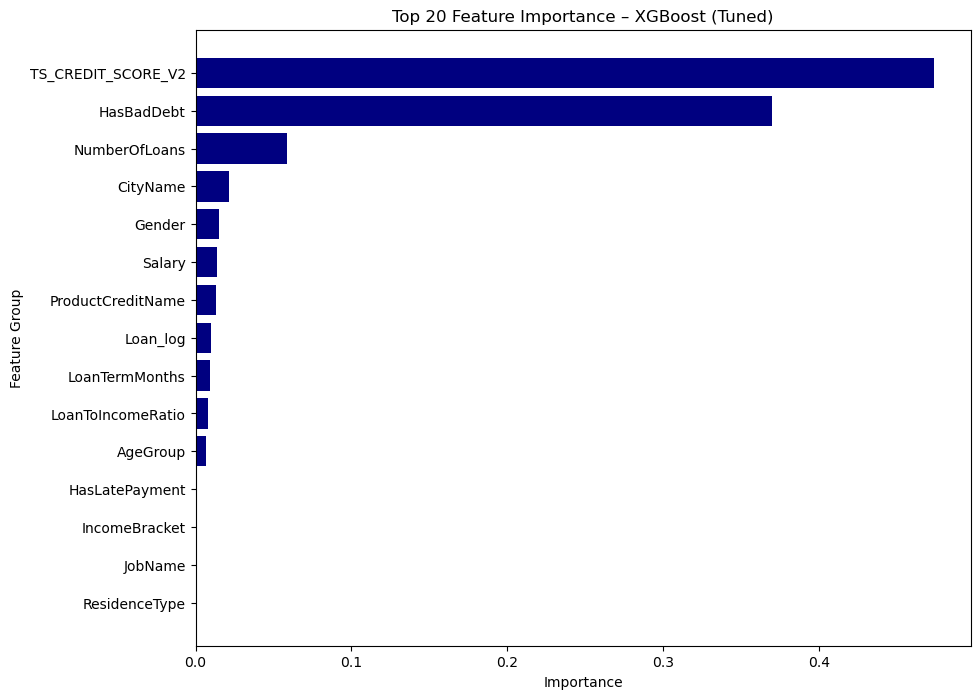

In [218]:
plt.figure(figsize=(10, 8))
plt.barh(grouped_importance["Group"], grouped_importance["Importance"], color='navy')
plt.title("Top 20 Feature Importance – XGBoost (Tuned)")
plt.xlabel("Importance")
plt.ylabel("Feature Group")
plt.gca().invert_yaxis()
plt.show()

**Another approach for prediction**

Another approach could be to use LoanStatus as the target variable to predict which customer types might lead to different LoanStatus states (Paid, On Loan, Late, Bad Debt). Grouping (Late + Bad Debt) = Risk, (Paid) = Safety. This helps the model focus on the most important goal: preventing bad debt.

In [219]:
#Group LoanStatus (Late (Muộn) + Bad Debt (Nợ xấu)) = Risk; (Paid (Hoàn thành)) = Safety

df_safe_risk = df[df["LoanStatus"] != "Đang vay"].copy()

df_safe_risk["Risk_Group"] = df_safe_risk["LoanStatus"].apply(
    lambda x: "Risk" if x in ["Muộn", "Nợ xấu"] else "Safety"
)

df_safe_risk[["LoanStatus", "Risk_Group"]]    


,LoanStatus,Risk_Group
1,Hoàn thành,Safety
2,Hoàn thành,Safety
3,Hoàn thành,Safety
4,Hoàn thành,Safety
5,Hoàn thành,Safety
...,...,...
2375,Muộn,Risk
2377,Muộn,Risk
2379,Hoàn thành,Safety
2380,Hoàn thành,Safety


In [220]:
df_safe_risk["Risk_Group"].value_counts()

Risk_Group
Safety    1586
Risk       731
Name: count, dtype: int64

In [221]:
y2 = df_safe_risk['Risk_Group']

In [222]:
df_safe_risk['Loan_log'] = np.log1p(df_safe_risk['Tiền giải ngân'])


In [223]:
selected_features2 = [
    # Numeric
    "TS_CREDIT_SCORE_V2",
    "HasBadDebt",
    "Salary",
    "LoanToIncomeRatio",
    "Loan_log",
    "HasLatePayment",
    "LoanTermMonths",
    "NumberOfLoans",

    # Categorical ( will be encoded)
    'IncomeBracket', 'JobName', 'ProductCreditName', 'Hình thức cư trú', 'AgeGroup', 'CityName', 'Gender'
]

In [224]:
X_raw2 = df_safe_risk[selected_features2].copy()

In [225]:
from sklearn.model_selection import train_test_split

num_cols2 = ["TS_CREDIT_SCORE_V2", "HasBadDebt", "Salary", "LoanToIncomeRatio", "Loan_log", "HasLatePayment", "LoanTermMonths", "NumberOfLoans"]
cat_cols2 = ['IncomeBracket', 'JobName', 'ProductCreditName', 'Hình thức cư trú', 'AgeGroup', 'CityName', 'Gender']

X_train_raw2, X_test_raw2, y_train2, y_test2 = train_test_split(
    X_raw2, y2, test_size=0.2, random_state=42, stratify=y2
)


#One-hot encoding for categorical features
X_train2 = pd.get_dummies(X_train_raw2, columns=cat_cols2, drop_first=True)
X_test2 = pd.get_dummies(X_test_raw2, columns=cat_cols2, drop_first=True)

X_train2, X_test2 = X_train2.align(
    X_test2,
    join="left",
    axis=1,
    fill_value=0
)

# Scale numeric features
scaler2 = StandardScaler()
X_train2[num_cols2] = scaler2.fit_transform(X_train2[num_cols2])
X_test2[num_cols2] = scaler2.transform(X_test2[num_cols2])

In [226]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

# General evaluation function for the models
def evaluate_model2(name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    print(f"\n{'=' * 10} MODEL RESULT: {name} {'=' * 10}")
    
    train_acc = accuracy_score(y_train_true, y_train_pred)
    train_f1 = f1_score(y_train_true, y_train_pred, average='macro')
    print("--- TRAIN ---")
    print("Train Accuracy :", round(train_acc, 4))
    print("Train F1 macro :", round(train_f1, 4))
    
    
    test_acc = accuracy_score(y_test_true, y_test_pred)
    test_f1 = f1_score(y_test_true, y_test_pred, average='macro')
    test_f1_wght = f1_score(y_test_true, y_test_pred, average='weighted')
    print("\n--- TEST ---")
    print("Test Accuracy  :", round(test_acc, 4))
    print("Test F1 macro  :", round(test_f1, 4))
    print("Test F1 weighted:", round(test_f1_wght, 4))
    
    #Classification Report on Test set
    print("\nClassification report (Test):")
    print(classification_report(y_test_true, y_test_pred, zero_division=0))

    # 4. Confusion matrix (Test)
    cm = confusion_matrix(y_test_true, y_test_pred, labels=['Risk','Safety'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Risk','Safety'])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap="Blues", values_format='d', ax=ax)
    plt.title(f"Confusion Matrix (Test) – {name}")
    plt.show()

Best Logistic params: {'penalty': 'l2', 'C': np.float64(0.01)}
Best Logistic CV f1_macro: 0.7612

========== MODEL RESULT: Logistic Regression - Tuned ==========
--- TRAIN ---
Train Accuracy : 0.789
Train F1 macro : 0.7632

--- TEST ---
Test Accuracy  : 0.7823
Test F1 macro  : 0.7609
Test F1 weighted: 0.7874

Classification report (Test):
              precision    recall  f1-score   support

        Risk       0.63      0.77      0.69       146
      Safety       0.88      0.79      0.83       318

    accuracy                           0.78       464
   macro avg       0.75      0.78      0.76       464
weighted avg       0.80      0.78      0.79       464



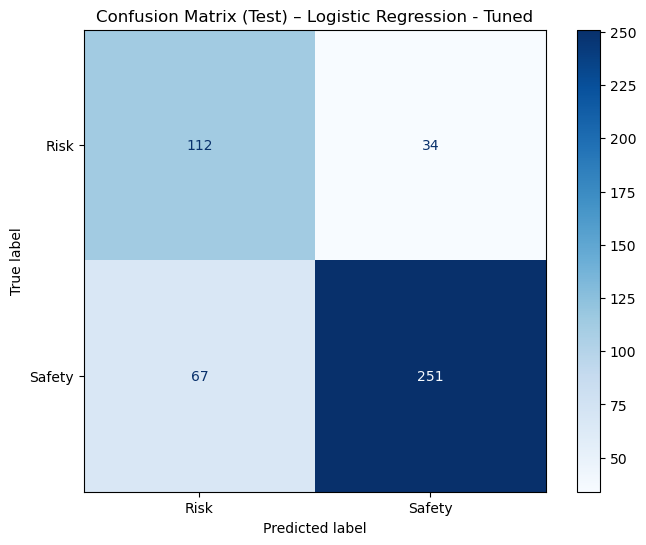

In [227]:
#Logistic Regression for Risk vs Safety

log_param_dist2 = {
    "C": np.logspace(-3, 0, 10),
    "penalty": ["l2"]
}

log_clf2 = LogisticRegression(
    solver="lbfgs",
    max_iter=10000,
    class_weight="balanced",
    n_jobs=-1
)

log_random_search2 = RandomizedSearchCV(
    estimator=log_clf2,
    param_distributions=log_param_dist2,
    n_iter=10,
    scoring="f1_macro",
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

log_random_search2.fit(X_train2, y_train2)

y_pred_train_log_best2 = log_random_search2.predict(X_train2)

print("Best Logistic params:", log_random_search2.best_params_)
print("Best Logistic CV f1_macro:", round(log_random_search2.best_score_, 4))

best_log2 = log_random_search2.best_estimator_

y_pred_log_best2 = best_log2.predict(X_test2)

evaluate_model2("Logistic Regression - Tuned", y_train2, y_pred_train_log_best2, y_test2, y_pred_log_best2)

Best RF params: {'bootstrap': True, 'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 10, 'min_samples_split': 46, 'n_estimators': 360}
Best RF CV f1_macro: 0.7811

========== MODEL RESULT: Random Forest - Tuned ==========
--- TRAIN ---
Train Accuracy : 0.8041
Train F1 macro : 0.7885

--- TEST ---
Test Accuracy  : 0.7974
Test F1 macro  : 0.7784
Test F1 weighted: 0.8025

Classification report (Test):
              precision    recall  f1-score   support

        Risk       0.64      0.80      0.71       146
      Safety       0.90      0.80      0.84       318

    accuracy                           0.80       464
   macro avg       0.77      0.80      0.78       464
weighted avg       0.82      0.80      0.80       464



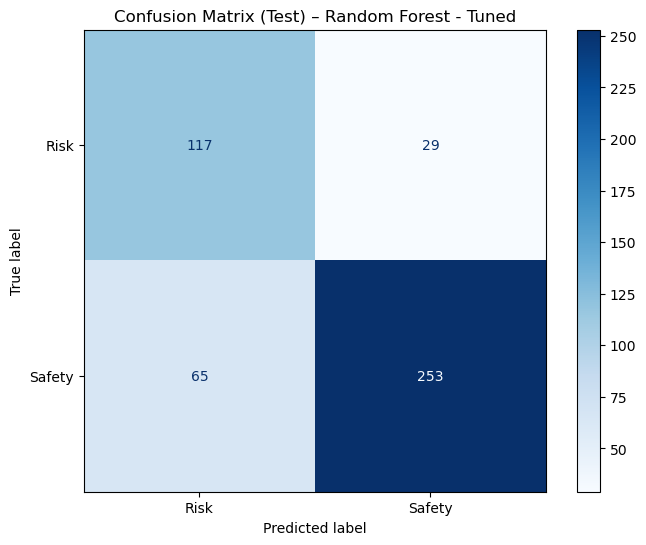

In [228]:
rf_param_dist2 = {
    "n_estimators": randint(100, 400),
    "max_depth": randint(3, 9),
    "min_samples_split": randint(20, 50),
    "min_samples_leaf": randint(10, 25),
    "max_features": ["sqrt", "log2", 0.5],
    "bootstrap": [True]
}

rf_clf2 = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_random_search2 = RandomizedSearchCV(
    estimator=rf_clf2,
    param_distributions=rf_param_dist2,
    n_iter=60,                  
    scoring="f1_macro",
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

rf_random_search2.fit(X_train2, y_train2)

y_pred_train_rf_best2 = rf_random_search2.predict(X_train2)

print("Best RF params:", rf_random_search2.best_params_)
print("Best RF CV f1_macro:", round(rf_random_search2.best_score_, 4))

# Best model after tuning
best_rf2 = rf_random_search2.best_estimator_

# Predict on the test set with the best RF model
y_pred_rf_best2 = best_rf2.predict(X_test2)
evaluate_model2("Random Forest - Tuned", y_train2, y_pred_train_rf_best2, y_test2, y_pred_rf_best2)


In [229]:
# Create copies of the training and test sets for XGBoost, since XGBoost may have issues with certain characters in column names.
X_train_xgb2 = X_train2.copy()
X_test_xgb2 = X_test2.copy()


def clean_xgb_columns2(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)            # all is string
                  .str.replace('[', '', regex=False)
                  .str.replace(']', '', regex=False)
                  .str.replace('<', 'lt_', regex=False)
                  .str.replace('>', 'gt_', regex=False)
    )
    return df


X_train_xgb2 = clean_xgb_columns2(X_train_xgb2)
X_test_xgb2 = clean_xgb_columns2(X_test_xgb2)


In [230]:
#Check if the indices of the new X_train_xgb2 and X_test_xgb2 match with the original X_train2 and X_test2, and also with y_train2 and y_test2.
assert X_train_xgb2.index.equals(X_train2.index)
assert X_test_xgb2.index.equals(X_test2.index)
assert y_train2.index.equals(X_train2.index)
assert y_test2.index.equals(X_test2.index)

y_train2_bin = (y_train2 == "Risk").astype(int)
y_test2_bin = (y_test2 == "Risk").astype(int)

scale_pos_weight2 = (y_train2_bin == 0).sum() / (y_train2_bin == 1).sum()


Best XGB params: {'colsample_bytree': np.float64(0.7340393806052343), 'gamma': 1, 'learning_rate': np.float64(0.039665218282154885), 'max_depth': 4, 'min_child_weight': 18, 'n_estimators': 174, 'reg_alpha': 0.1, 'reg_lambda': 5, 'scale_pos_weight': np.float64(1.6256410256410256), 'subsample': np.float64(0.9663112548274899)}
Best XGB CV f1_macro: 0.7864

========== MODEL RESULT: XGBoost – Tuned ==========
--- TRAIN ---
Train Accuracy : 0.8322
Train F1 macro : 0.8148

--- TEST ---
Test Accuracy  : 0.7845
Test F1 macro  : 0.7622
Test F1 weighted: 0.7892

Classification report (Test):
              precision    recall  f1-score   support

        Risk       0.63      0.76      0.69       146
      Safety       0.88      0.80      0.83       318

    accuracy                           0.78       464
   macro avg       0.75      0.78      0.76       464
weighted avg       0.80      0.78      0.79       464



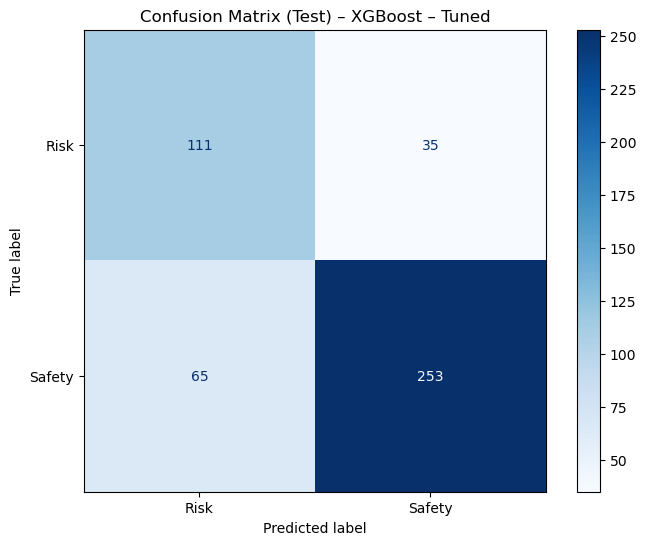

In [231]:


xgb_param_dist2 = {
    "n_estimators": randint(80, 200),
    "max_depth": randint(2, 5),
    "learning_rate": uniform(0.01, 0.06),
    "subsample":  uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "min_child_weight": randint(5, 20),
    "gamma": [1, 2, 5],
    "reg_lambda": [5, 10, 20],
    "reg_alpha": [0, 0.1, 0.5, 1],
    "scale_pos_weight": [1, scale_pos_weight2, scale_pos_weight2 * 0.75]
}


xgb_clf2 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    tree_method="hist",
    n_jobs=-1,
)

xgb_random_search2 = RandomizedSearchCV(
    estimator=xgb_clf2,
    param_distributions=xgb_param_dist2,
    n_iter=80,              
    scoring="f1_macro",
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

xgb_random_search2.fit(X_train_xgb2, y_train2_bin)

# Predict on train set
y_pred_train_xgb_best2_bin = xgb_random_search2.predict(X_train_xgb2)

# Convert 0/1 back to Risk/Safety
y_pred_train_xgb_best2 = np.where(y_pred_train_xgb_best2_bin == 1, "Risk", "Safety")

# True train labels keep original string labels
y_true_train_xgb_best2 = y_train2

print("Best XGB params:", xgb_random_search2.best_params_)
print("Best XGB CV f1_macro:", round(xgb_random_search2.best_score_, 4))

# Best XGBoost model after tuning
best_xgb2 = xgb_random_search2.best_estimator_

# Predict on test set
y_pred_xgb_best2_bin = best_xgb2.predict(X_test_xgb2)

# Convert 0/1 back to Risk/Safety
y_pred_xgb_best2 = np.where(y_pred_xgb_best2_bin == 1, "Risk", "Safety")

# True test labels keep original string labels
y_test_true2 = y_test2

# Evaluate
evaluate_model2("XGBoost – Tuned", y_true_train_xgb_best2, y_pred_train_xgb_best2, y_test_true2, y_pred_xgb_best2)


**Calculate AUC for Risk vs Safety Models**

In [232]:
from sklearn.metrics import roc_auc_score


def positive_class_proba(model, X_eval, positive_label="Risk"):
    positive_idx = list(model.classes_).index(positive_label)
    return model.predict_proba(X_eval)[:, positive_idx]


def binary_auc_row(name, y_train_binary, y_test_binary, train_score, test_score):
    return {
        "Model": name,
        "Train AUC": roc_auc_score(y_train_binary, train_score),
        "Test AUC": roc_auc_score(y_test_binary, test_score),
    }


y_train2_auc = (y_train2 == "Risk").astype(int)
y_test2_auc = (y_test2 == "Risk").astype(int)

auc_risk_safety_results = pd.DataFrame([
    binary_auc_row(
        "Logistic Regression - Tuned",
        y_train2_auc,
        y_test2_auc,
        positive_class_proba(best_log2, X_train2),
        positive_class_proba(best_log2, X_test2),
    ),
    binary_auc_row(
        "Random Forest - Tuned",
        y_train2_auc,
        y_test2_auc,
        positive_class_proba(best_rf2, X_train2),
        positive_class_proba(best_rf2, X_test2),
    ),
    binary_auc_row(
        "XGBoost - Tuned",
        y_train2_bin,
        y_test2_bin,
        best_xgb2.predict_proba(X_train_xgb2)[:, 1],
        best_xgb2.predict_proba(X_test_xgb2)[:, 1],
    ),
])

auc_risk_safety_results.sort_values("Test AUC", ascending=False).round(4)


,Model,Train AUC,Test AUC
1,Random Forest - Tuned,0.8878,0.8366
2,XGBoost - Tuned,0.9009,0.8345
0,Logistic Regression - Tuned,0.8548,0.8245


In [233]:
# Take importance
importances = best_rf2.feature_importances_
feature_names2 = X_train2.columns

# Create a DataFrame for feature importance
fi_df2 = pd.DataFrame({
    "Feature": feature_names2,
    "Importance": importances
}).sort_values("Importance", ascending=False)

fi_df2.head(20)

,Feature,Importance
6,LoanTermMonths,0.654761
63,ProductCreditName_Vay theo sim,0.071071
70,Hình thức cư trú_Thuê,0.054153
4,Loan_log,0.035158
3,LoanToIncomeRatio,0.030675
0,TS_CREDIT_SCORE_V2,0.028896
7,NumberOfLoans,0.025244
81,CityName_Hồ Chí Minh,0.020118
2,Salary,0.016895
78,CityName_Hà Nội,0.008291


In [234]:
import pandas as pd

# Take importance + name of features
feat_importance2 = pd.DataFrame({
    'Feature': X_train2.columns,
    'Importance': best_rf2.feature_importances_
})

# Create mapping groups based on feature name patterns
def map_group2(col):
    if col.startswith("JobName_"):
        return "JobName"
    elif col.startswith("Hình thức cư trú_"):
        return "ResidenceType"
    elif col.startswith("ProductCreditName_"):
        return "ProductCreditName"
    elif col.startswith("IncomeBracket_"):
        return "IncomeBracket"
    elif col.startswith("AgeGroup_"):
        return "AgeGroup"
    elif col.startswith("CityName_"):
        return "CityName"
    elif col.startswith("Gender_"):
        return "Gender"
    else:
        return col   # numeric variables

feat_importance2["Group"] = feat_importance2["Feature"].apply(map_group2)

# Consolidate importance by group
grouped_importance2 = (
    feat_importance2.groupby("Group")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

grouped_importance2


,Group,Importance
0,LoanTermMonths,0.654761
1,ProductCreditName,0.087437
2,ResidenceType,0.063702
3,Loan_log,0.035158
4,LoanToIncomeRatio,0.030675
5,TS_CREDIT_SCORE_V2,0.028896
6,CityName,0.028409
7,NumberOfLoans,0.025244
8,Salary,0.016895
9,JobName,0.016078


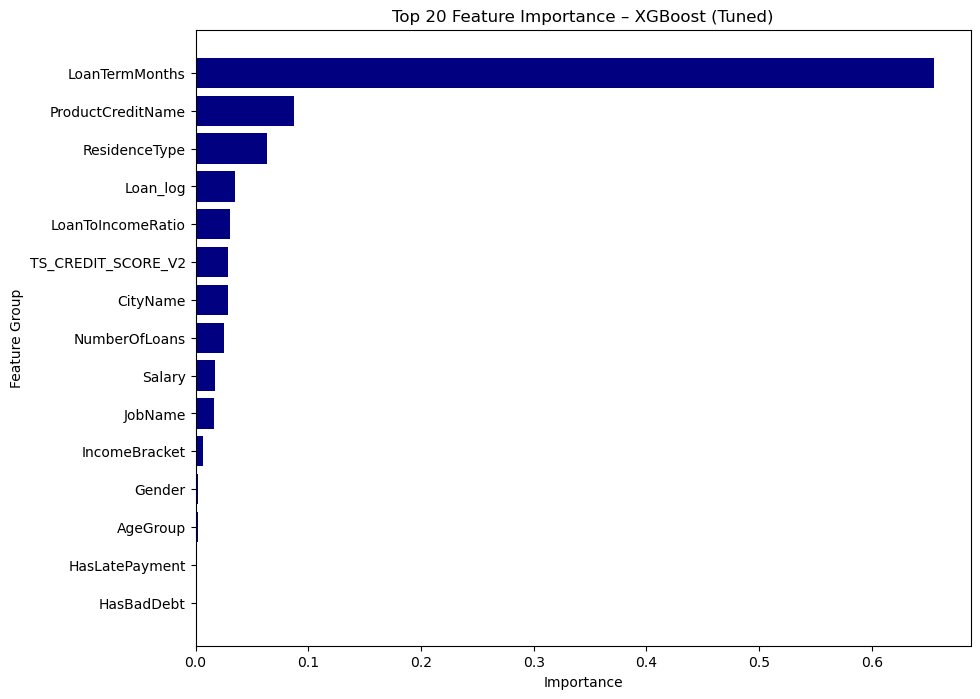

In [235]:
plt.figure(figsize=(10, 8))
plt.barh(grouped_importance2["Group"], grouped_importance2["Importance"], color='navy')
plt.title("Top 20 Feature Importance – XGBoost (Tuned)")
plt.xlabel("Importance")
plt.ylabel("Feature Group")
plt.gca().invert_yaxis()
plt.show()